# V0 spatial-residual DNN v10: cut07 + smooth sample pruning

This version keeps the full-vector magnetic-field response and detector-space map from v9, but changes the data selection and training control:

- **No new exporter is required.** It uses the existing linked candidate/cluster CSVs.
- The notebook applies the measured best **cut07** directly from candidate columns: daughter $p_T>0.2$ GeV/$c$, $L_{proj}>2$ cm, Sailors cut, $|z_{vtx}|<10$ cm, $|\Delta PCA_z|<0.2$ cm, pair DCA $<0.5$ cm, DIRA $>0.95$.
- PID is recalculated in Python with the ALEPH $dE/dx$ parameterization and the 3$\sigma$ target + 1$\sigma$ competing-species veto.
- Low-pT candidates are **stochastically pruned with a smooth keep probability**. High-pT candidates are kept, and there is no inverse-pT reweighting afterward.
- `training_profile='short'` is intended for a quick order-one-hour test; `training_profile='long'` is intended for the full several-hour / roughly ten-hour class run. Actual runtime still depends on the retained sample and machine.
- K0S mass and charge balance use the **same frozen baseline-mass core**. The charge loss cannot recruit sideband candidates, and validation rejects any meaningful K0S peak broadening.


In [ ]:
# ============================================================
# Imports and configuration
# ============================================================

from pathlib import Path
from array import array
import copy, gc, json, math, os, random, time, traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from scipy.optimize import minimize

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False
    print('WARNING: joblib unavailable; residual pretraining will run sequentially.')

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_float32_matmul_precision('high')

# Existing exporter output. No tight-exporter rerun is needed for v10.
csv_dir = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs')
csv_prefix = 'v0_spatial_training'
candidate_csv = csv_dir / f'{csv_prefix}_candidates.csv'
cluster_csv = csv_dir / f'{csv_prefix}_clusters.csv'

training_profile = 'short'  # 'short' or 'long'
geometry_profile_name = 'wide'

# Beam position used by the V0 reconstruction/exporter.
beam_x_cm, beam_y_cm, beam_z_cm = 0.158, 0.285, 0.0

# Best topology from the QA scan: cut07_pairDCA_5mm.
cut07_daughter_pt_min_gev = 0.20
cut07_lproj_min_cm = 2.0
cut07_abs_zvtx_max_cm = 10.0
cut07_abs_delta_pca_z_max_cm = 0.20
cut07_pair_dca_max_cm = 0.50
cut07_dira_min = 0.95
maximum_absolute_daughter_eta = 1.0

# Recompute PID from the stored dE/dx rather than using the old dE/dx<400 flag.
dedx_scale = 0.015
pid_target_nsigma = 3.0
pid_other_veto_nsigma = 1.0
apply_pid_selection = False

# Broad windows still keep sidebands for a frozen signal/background model.
k0s_cluster_mass_min, k0s_cluster_mass_max = 0.44, 0.56
lambda_cluster_mass_min, lambda_cluster_mass_max = 1.095, 1.140
k0s_cluster_pair_pt_min, k0s_cluster_pair_pt_max = None, 3.0
lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max = None, None
load_lambda_validation_clusters = True

# Smooth stochastic pruning: p_keep rises smoothly from low_keep_fraction to 1.
# There is no 1/p_keep compensation in the loss; the retained sample itself is the training distribution.
training_profiles = {
    'short': {
        'description': 'quick ~1 h class test',
        'k0s_low_pt_keep_fraction': 0.30,
        'lambda_low_pt_keep_fraction': 0.40,
        'prune_transition_start_pt_gev': 0.40,
        'prune_full_keep_pt_gev': 2.00,
        'maximum_k0s_candidates': 70_000,
        'maximum_lambda_candidates_per_channel': 4_000,
        'maximum_validation_candidates': 8_000,
        'residual_pretraining_epochs': 3,
        'hybrid_training_epochs': 70,
        'validation_interval': 5,
        'patience': 20,
    },
    'long': {
        'description': 'full several-hour / ~10 h class run',
        'k0s_low_pt_keep_fraction': 0.35,
        'lambda_low_pt_keep_fraction': 0.55,
        'prune_transition_start_pt_gev': 0.40,
        'prune_full_keep_pt_gev': 1.60,
        'maximum_k0s_candidates': 180_000,
        'maximum_lambda_candidates_per_channel': 15_000,
        'maximum_validation_candidates': 30_000,
        'residual_pretraining_epochs': 12,
        'hybrid_training_epochs': 100,
        'validation_interval': 10,
        'patience': 30,
    },
}
if training_profile not in training_profiles:
    raise KeyError(f'Unknown training_profile={training_profile!r}; choose {list(training_profiles)}')
profile = training_profiles[training_profile]


Welcome to JupyROOT 6.30/06


/home/yoren/.local/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
profile = training_profiles[training_profile]

description = profile['description']
k0s_low_pt_keep_fraction = profile['k0s_low_pt_keep_fraction']
lambda_low_pt_keep_fraction = profile['lambda_low_pt_keep_fraction']
prune_transition_start_pt_gev = profile['prune_transition_start_pt_gev']
prune_full_keep_pt_gev = profile['prune_full_keep_pt_gev']
maximum_k0s_candidates = profile['maximum_k0s_candidates']
maximum_lambda_candidates_per_channel = profile['maximum_lambda_candidates_per_channel']
maximum_validation_candidates = profile['maximum_validation_candidates']
residual_pretraining_epochs = profile['residual_pretraining_epochs']
hybrid_training_epochs = profile['hybrid_training_epochs']
validation_interval = profile['validation_interval']
patience = profile['patience']

cluster_csv_chunksize = 250_000
cluster_progress_print_every_n_chunks = 10
candidate_subsample_seed = seed + 101

geometry_profiles = {
    'conservative': {
        'maximum_side_offset_cm': 0.30,
        'maximum_side_tilt_displacement_cm': 0.30,
        'maximum_module_offset_cm': 0.015,
        'initial_delta_r_cm': {0: 0.030, 1: 0.030},
        'initial_rdelta_phi_cm': {0: 0.030, 1: 0.030},
        'initial_tilt_coefficients': {0: [0.0] * 4, 1: [0.0] * 4},
    },
    'wide': {
        'maximum_side_offset_cm': 2.0,
        'maximum_side_tilt_displacement_cm': 2.0,
        'maximum_module_offset_cm': 0.10,
        'initial_delta_r_cm': {0: 0.10, 1: 0.10},
        'initial_rdelta_phi_cm': {0: 0.10, 1: 0.10},
        'initial_tilt_coefficients': {0: [0.0] * 4, 1: [0.0] * 4},
    },
}
if geometry_profile_name not in geometry_profiles:
    raise KeyError(f'Unknown geometry_profile_name={geometry_profile_name!r}; choose {list(geometry_profiles)}')
geometry_profile = geometry_profiles[geometry_profile_name]
maximum_side_offset_cm = float(geometry_profile['maximum_side_offset_cm'])
maximum_side_tilt_displacement_cm = float(geometry_profile['maximum_side_tilt_displacement_cm'])
maximum_module_offset_cm = float(geometry_profile['maximum_module_offset_cm'])
initial_side_delta_r_cm = geometry_profile['initial_delta_r_cm']
initial_side_rdelta_phi_cm = geometry_profile['initial_rdelta_phi_cm']
initial_side_tilt_coefficients = geometry_profile['initial_tilt_coefficients']

work_dir = Path(f'output/v0_spatial_residual_dnn_v10_cut07_{training_profile}_{geometry_profile_name}')
checkpoint_dir = work_dir / 'checkpoints'
cache_dir = work_dir / 'tensor_cache'
checkpoint_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

include_z_correction = True
training_parity = 0
validation_parity = 1 - training_parity
pdg_kshort_mass = 0.497611
pion_mass = 0.13957039
kaon_mass = 0.493677
deuteron_mass = 1.87561294257
proton_mass = 0.9382720813
min_k0s_mass, max_k0s_mass = k0s_cluster_mass_min, k0s_cluster_mass_max

z_pad_cm = 102.325
central_membrane_tolerance_cm = 0.50
pad_plane_tolerance_cm = 0.75
maximum_clusters = 48
minimum_clusters_per_track = 30
minimum_tpc_modules_per_track = 3
minimum_track_radial_span_cm = 15.0
excluded_layers = {7, 21, 22, 23, 24, 37, 38, 39, 40, 54}
tpc_module_layer_ranges = ((7, 22), (23, 38), (39, 54))
use_recommended_clusters_only = True
use_kalman_used_clusters_only = False
maximum_abs_residual_normal_cm = 2.0
maximum_abs_residual_z_cm = 3.0
fallback_sigma_r_cm = 0.20
fallback_sigma_rphi_cm = 0.05
fallback_sigma_z_cm = 0.20
minimum_sigma_normal_cm = 0.05

maximum_delta_r_cm = 3.00
maximum_r_delta_phi_cm = 0.50
maximum_delta_z_cm = 2.0
number_of_radial_basis_functions = 16
radial_basis_minimum_cm = 31.0
radial_basis_maximum_cm = 76.0
radial_basis_width_scale = 1.10
number_of_phi_harmonics = 3
hidden_width = 128
hidden_layers = 3
dropout_probability = 0.03

learning_rate = 8.0e-4
weight_decay = 1.0e-3
residual_batch_size = 32768
candidate_batch_size = 8192
validation_batch_size = 4096
loss_scale_calibration_batches = 8

field_evaluation_mode = 'linearized'
field_gradient_step_cm = 1.0
lorentz_curvature_constant = 0.00299792458
minimum_refit_scale, maximum_refit_scale = 0.80, 1.20
momentum_scale_response_strength = 1.0
direction_correction_strength = 1.0

# Physics-loss hierarchy. Mass preservation is at least as important as charge balance.
charge_balance_loss_weight = 1.00
pt_mass_scale_loss_weight = 1.00
inclusive_mass_loss_weight = 2.00
residual_loss_weight = 0.3
charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev = 0.20, 3.0
charge_balance_number_of_bins = 14
charge_balance_kernel_width_bins = 1.0
charge_balance_systematic_floor_fraction = 0.05
charge_balance_pt_priority_power = 1.0
charge_balance_pt_priority_reference_gev = 1.0
charge_balance_maximum_priority = 4.0
charge_balance_minimum_bin_effective_entries = 100.0

pt_mass_scale_bin_edges = np.array([0.5, 0.8, 1.1, 1.4, 1.8, 2.2, 3.0], dtype=np.float32)
pt_mass_scale_minimum_effective_entries = 20.0
pt_mass_priority_power = 0.75
pt_mass_priority_reference_gev = 1.0
pt_mass_maximum_priority = 3.0
pt_mass_mean_systematic_floor_gev = 0.0005
pt_mass_width_guard_weight = 20.0
inclusive_mass_width_guard_weight = 30.0

# Frozen K0S model: narrow signal only. Charge balance is restricted to this baseline-mass core.
minimum_signal_probability_for_physics = 0.0
k0s_mass_fit_signal_fraction_min = 0.02
k0s_mass_fit_signal_fraction_max = 0.75
k0s_mass_fit_mean_min, k0s_mass_fit_mean_max = 0.486, 0.506
k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev = 0.003, 0.010
k0s_mass_core_nsigma = 2.0
k0s_mass_model_minimum_candidates_per_pt_bin = 300
maximum_allowed_sideband_signal_probability = 0.20
minimum_peak_minus_sideband_probability = 0.25
maximum_validation_width_ratio = 1.2
validation_width_rejection_penalty = 300.0
enforce_mass_width_validation = True

# No inverse-pT / density reweighting after pruning.
use_smooth_track_pt_reweighting = False
track_pt_weight_power = 0.0
minimum_pair_weight = 1.0
maximum_pair_weight = 1.0

mean_field_loss_weight = 0.002
alignment_prior_weight = 0.02
module_zero_mean_weight = 0.02
module_rms_weight = 0.02
delta_r_amplitude_loss_weight = 0.0005
rdelta_phi_amplitude_loss_weight = 0.010
delta_z_amplitude_loss_weight = 0.005
delta_r_smoothness_loss_weight = 0.010
rdelta_phi_smoothness_loss_weight = 0.050
delta_z_smoothness_loss_weight = 0.030
number_of_ensemble_models = 1

requested_total_cpu_threads = 12
available_cpu_threads = int(os.environ.get('SLURM_CPUS_PER_TASK', os.cpu_count() or requested_total_cpu_threads))
total_cpu_threads = max(2, min(requested_total_cpu_threads, available_cpu_threads))
parallel_side_jobs = 6
threads_per_side = max(1, total_cpu_threads // parallel_side_jobs)
kshort_pt_bin_edges = pt_mass_scale_bin_edges.astype(np.float64)

print('Training profile:', training_profile, '-', description)
print('Geometry profile:', geometry_profile_name)
print('CSV prefix:', csv_prefix)
print('Work directory:', work_dir)
print('Epochs: residual', residual_pretraining_epochs, '| hybrid', hybrid_training_epochs, '| patience', patience)
print('Smooth keep: low-pT K0S', k0s_low_pt_keep_fraction, '| full keep above', prune_full_keep_pt_gev, 'GeV/c')
print('PyTorch:', torch.__version__, '| CPU threads:', total_cpu_threads)


Training profile: short - quick ~1 h class test
Geometry profile: wide
CSV prefix: v0_spatial_training
Work directory: output/v0_spatial_residual_dnn_v10_cut07_short_wide
Epochs: residual 3 | hybrid 70 | patience 20
Smooth keep: low-pT K0S 0.3 | full keep above 2.0 GeV/c
PyTorch: 2.9.0+cu128 | CPU threads: 12


## Load the linked tables and construct the transverse normal residual

The cluster CSV already contains measured positions, fitted positions, and fitted local momenta. No new exporter columns are required.

For each cluster, define the fitted transverse tangent and one normal direction:

\[
\hat t_T = \frac{(p_x^{\rm fit},p_y^{\rm fit})}{p_T^{\rm fit}},
\qquad
\hat n_T=(-t_y,t_x).
\]

The measured-minus-fit displacement is

\[
\mathbf d_T=(x_{\rm cluster}-x_{\rm fit},y_{\rm cluster}-y_{\rm fit}).
\]

The usable transverse observation is

\[
d_n=\mathbf d_T\cdot\hat n_T.
\]

The sign choice of \(\hat n_T\) is irrelevant because the target and the field-projection coefficients change sign together.


In [3]:
# ============================================================
# Candidate selection, smooth pruning, and memory-safe cluster loading
# ============================================================


def candidate_key(candidate_id, channel):
    return np.asarray(candidate_id, dtype=np.int64) * 4 + np.asarray(channel, dtype=np.int64)


def radial_module_from_layer(layer):
    layer = np.asarray(layer)
    out = np.full(layer.shape, -1, dtype=np.int8)
    for module_index, (first_layer, last_layer) in enumerate(tpc_module_layer_ranges):
        out[(layer >= first_layer) & (layer <= last_layer)] = module_index
    return out


def sector_from_phi(phi):
    wrapped = np.mod(np.asarray(phi, dtype=np.float32) + np.float32(math.pi), np.float32(2.0 * math.pi))
    return np.clip(np.floor(wrapped / np.float32(2.0 * math.pi / 12.0)).astype(np.int8), 0, 11)


def smoothstep01(x):
    x = np.clip(np.asarray(x, dtype=np.float64), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


def smooth_keep_probability(pair_pt, low_fraction, gamma=1.0):
    pt = np.asarray(pair_pt, dtype=np.float64)
    x = (pt - prune_transition_start_pt_gev) / max(prune_full_keep_pt_gev - prune_transition_start_pt_gev, 1.0e-6)
    shape = smoothstep01(x) ** gamma
    return low_fraction + (1.0 - low_fraction) * shape


def adaptive_keep_probability(pair_pt, target_candidates, low_fraction):
    pt = np.asarray(pair_pt, dtype=np.float64)

    if target_candidates is None or target_candidates >= len(pt):
        return np.ones(len(pt), dtype=np.float64), 1.0

    target_candidates = float(target_candidates)
    high_count = np.count_nonzero(pt >= prune_full_keep_pt_gev)

    if target_candidates <= high_count:
        raise RuntimeError(
            f'Target {target_candidates:.0f} is smaller than the {high_count} candidates '
            f'already above {prune_full_keep_pt_gev:.2f} GeV/c.'
        )

    minimum_expected = high_count + low_fraction * (len(pt) - high_count)

    if target_candidates < minimum_expected:
        allowed_floor = (target_candidates - high_count) / max(len(pt) - high_count, 1)
        low_fraction = max(0.0, 0.8 * allowed_floor)
        print(f'Adjusted low-pT keep floor to {low_fraction:.4f} to reach target.')

    gamma_low = 0.05
    gamma_high = 100.0

    for _ in range(60):
        gamma = 0.5 * (gamma_low + gamma_high)
        probability = smooth_keep_probability(pt, low_fraction, gamma)
        expected = probability.sum()

        if expected > target_candidates:
            gamma_low = gamma
        else:
            gamma_high = gamma

    gamma = gamma_high
    probability = smooth_keep_probability(pt, low_fraction, gamma)

    return probability, gamma


def smooth_prune(frame, low_fraction, maximum, seed_value, label):
    if frame.empty:
        return frame

    before_pt = frame['pair_pt'].to_numpy(np.float64)
    probability, gamma = adaptive_keep_probability(before_pt, maximum, low_fraction)

    rng = np.random.default_rng(seed_value)
    keep = rng.random(len(frame)) < probability
    retained = frame.loc[keep].copy()
    after_pt = retained['pair_pt'].to_numpy(np.float64)

    print(
        f'{label}: {len(before_pt):,} -> {len(retained):,}; '
        f'target={maximum:,}; expected={probability.sum():,.0f}; gamma={gamma:.3f}'
    )

    bins = np.linspace(0.0, 3.0, 61)
    before_counts, _ = np.histogram(before_pt, bins=bins)
    after_counts, _ = np.histogram(after_pt, bins=bins)
    centers = 0.5 * (bins[:-1] + bins[1:])

    observed_keep = np.divide(
        after_counts,
        before_counts,
        out=np.full(len(after_counts), np.nan, dtype=float),
        where=before_counts > 0,
    )

    normalization = max(before_counts.max(), 1)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.step(centers, before_counts / normalization, where='mid', label=f'{label}: before')
    ax.step(centers, after_counts / normalization, where='mid', label=f'{label}: retained')

    ax2 = ax.twinx()
    grid = np.linspace(0.0, 3.0, 400)
    grid_probability = smooth_keep_probability(grid, low_fraction, gamma)
    ax2.plot(grid, grid_probability, linestyle='--', label='target keep probability')
    ax2.scatter(centers, observed_keep, s=12, alpha=0.5, label='observed retained fraction')

    ax.set_xlabel(r'candidate $p_T$ [GeV/$c$]')
    ax.set_ylabel('candidates / maximum original bin')
    ax2.set_ylabel('retained fraction')
    ax2.set_ylim(0.0, 1.05)

    ax.legend(loc='upper right')
    ax2.legend(loc='center right')
    ax.set_title(f'{label}: smooth stochastic pruning ({len(before_pt):,} → {len(retained):,})')

    plt.show()

    return retained


# ------------------------- ALEPH dE/dx PID -------------------------

def aleph_expected_dedx(momentum, mass):
    p = np.maximum(np.asarray(momentum, dtype=np.float64), 1.0e-6)
    bg = p / mass
    beta = bg / np.sqrt(1.0 + bg * bg)
    p1, p2, p3, p4, p5 = 0.1819, 10.8175, 1.1674e-5, 3.0199, 5.0
    return p1 / np.maximum(beta, 1.0e-8) ** p4 * (p2 - beta ** p4 - np.log(p3 + bg ** (-p5)))


def universal_log_dedx_sigma(expected):
    expected = np.maximum(np.asarray(expected, dtype=np.float64), 1.0e-8)
    return np.sqrt(0.07690 ** 2 + 0.16914 ** 2 / expected ** 0.40000)


def species_width_ratio(momentum, species):
    p = np.asarray(momentum, dtype=np.float64)
    if species == 'pi':
        return np.ones_like(p)
    if species == 'k':
        pc = np.clip(p, 0.23, 0.53)
        return 0.910 + 0.628 * (np.log(pc) - np.log(0.23))
    if species == 'p':
        pc = np.clip(p, 0.20, 0.93)
        return 1.077 - 0.037 * (np.log(pc) - np.log(0.20))
    if species == 'd':
        pc = np.clip(p, 0.29, 1.73)
        return 0.834 + 0.164 * (np.log(pc) - np.log(0.29))
    raise KeyError(species)


species_masses = {'pi': pion_mass, 'k': kaon_mass, 'p': proton_mass, 'd': deuteron_mass}


def dedx_nsigma(measured_dedx, momentum, species):
    measured = np.asarray(measured_dedx, dtype=np.float64) * dedx_scale
    expected = aleph_expected_dedx(momentum, species_masses[species])
    sigma = universal_log_dedx_sigma(expected) * species_width_ratio(momentum, species)
    valid = np.isfinite(measured) & (measured > 0) & np.isfinite(expected) & (expected > 0) & np.isfinite(sigma) & (sigma > 0)
    out = np.full(measured.shape, np.nan, dtype=np.float32)
    out[valid] = ((np.log(measured[valid]) - np.log(expected[valid])) / sigma[valid]).astype(np.float32)
    return out


def pid_accept(nsigma, target):
    if not apply_pid_selection:
        return np.ones_like(nsigma[target], dtype=np.bool_)
    target_ok = np.abs(nsigma[target]) < pid_target_nsigma
    competitors = [species for species in ['pi', 'k', 'p', 'd'] if species != target]
    other_distance = np.minimum.reduce([np.abs(nsigma[species]) for species in competitors])
    return target_ok & np.isfinite(other_distance) & (other_distance > pid_other_veto_nsigma)



Raw candidates: 823,490
After cut07: 134,652
After cut07 + PID: 134,652
K0S before smooth pruning: 119,112
K0S: 119,112 -> 70,020; target=70,000; expected=70,000; gamma=1.650


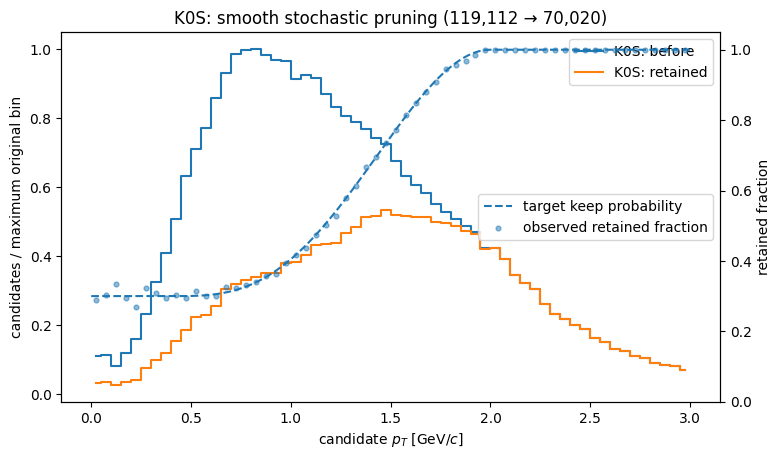

K0S retained for cluster loading: 70,020
Lambda before smooth pruning: 4,230
Lambda: 4,230 -> 3,984; target=4,000; expected=4,000; gamma=0.711


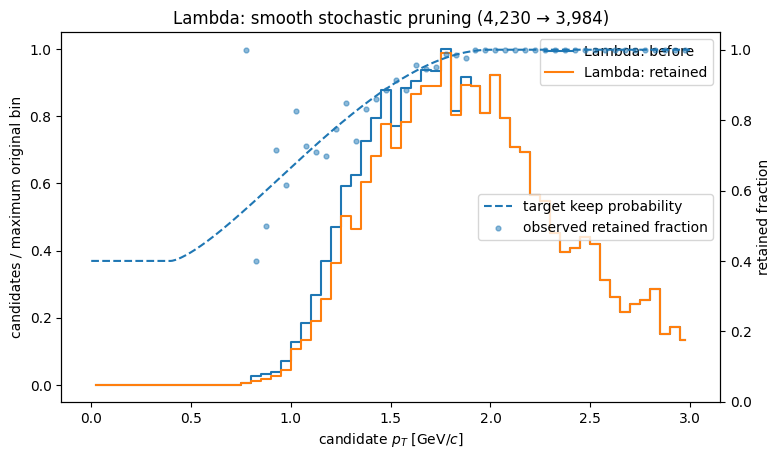

Lambda retained for cluster loading: 3,984
AntiLambda before smooth pruning: 4,154
AntiLambda: 4,154 -> 4,014; target=4,000; expected=4,000; gamma=0.544


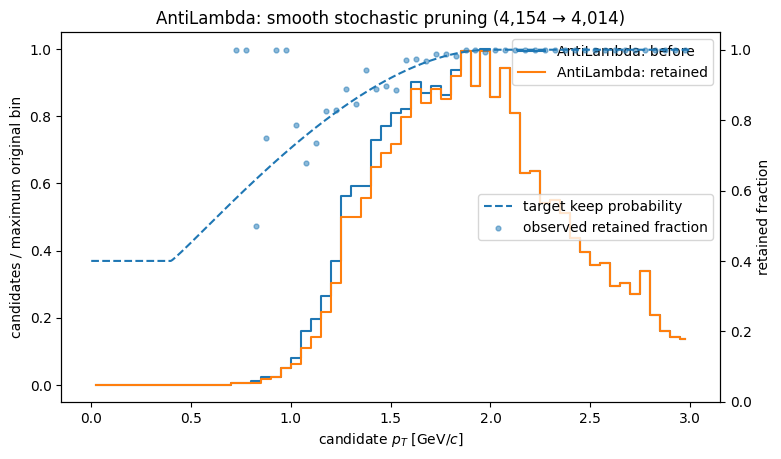

AntiLambda retained for cluster loading: 4,014
Total retained candidates: 78,018
channel  side1  event_parity
0        0      0               19195
                1               19570
         1      0               15530
                1               15725
1        0      0                1053
                1                1042
         1      0                 929
                1                 960
2        0      0                1094
                1                1125
         1      0                 914
                1                 881
dtype: int64
chunk 1: read=250,000, candidate matched=25,881, retained=20,819
chunk 10: read=2,500,000, candidate matched=242,214, retained=195,076
chunk 20: read=5,000,000, candidate matched=484,150, retained=389,596
chunk 30: read=7,500,000, candidate matched=717,040, retained=576,847
chunk 40: read=10,000,000, candidate matched=964,107, retained=775,558
chunk 50: read=12,500,000, candidate matched=1,208,633, retained=972,153
ch

In [4]:

# ------------------------- candidate table -------------------------

candidate_columns = [
    'candidate_id', 'event_parity', 'channel', 'same_side', 'side1', 'side2', 'charge1', 'charge2',
    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1', 'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'pca1_z', 'pca2_z', 'pair_dca', 'dira', 'dedx1', 'dedx2',
    'selected_mass', 'pair_pt', 'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',
]
float32_columns = [
    'charge1', 'charge2', 'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1', 'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'pca1_z', 'pca2_z', 'pair_dca', 'dira', 'dedx1', 'dedx2', 'selected_mass', 'pair_pt',
]
candidate_dtype = {name: np.float32 for name in float32_columns}
candidate_dtype.update({'candidate_id': np.int64, 'event_parity': np.int8, 'channel': np.int8, 'same_side': np.int8, 'side1': np.int8, 'side2': np.int8, 'pass_cut03': np.int8, 'pass_pion_pid': np.int8, 'pass_signed_delta_phi': np.int8})

candidate_header = pd.read_csv(candidate_csv, nrows=0).columns
missing = sorted(set(candidate_columns) - set(candidate_header))
if missing:
    raise KeyError(f'Missing candidate columns required by v10: {missing}')
candidates = pd.read_csv(candidate_csv, usecols=candidate_columns, dtype=candidate_dtype)
print('Raw candidates:', f'{len(candidates):,}')

# Geometry and cut07 quantities.
pair_px = candidates['px1'].to_numpy() + candidates['px2'].to_numpy()
pair_py = candidates['py1'].to_numpy() + candidates['py2'].to_numpy()
pair_pz = candidates['pz1'].to_numpy() + candidates['pz2'].to_numpy()
pair_p = np.sqrt(pair_px ** 2 + pair_py ** 2 + pair_pz ** 2)
flight_x = candidates['pca_x'].to_numpy() - beam_x_cm
flight_y = candidates['pca_y'].to_numpy() - beam_y_cm
flight_z = candidates['pca_z'].to_numpy() - beam_z_cm
candidates['lproj'] = ((pair_px * flight_x + pair_py * flight_y + pair_pz * flight_z) / np.maximum(pair_p, 1.0e-8)).astype(np.float32)
candidates['abs_delta_pca_z'] = np.abs(candidates['pca1_z'].to_numpy() - candidates['pca2_z'].to_numpy()).astype(np.float32)

eta_ok = np.isfinite(candidates['eta1']) & np.isfinite(candidates['eta2']) & (np.abs(candidates['eta1']) < maximum_absolute_daughter_eta) & (np.abs(candidates['eta2']) < maximum_absolute_daughter_eta)
cut07 = eta_ok & (candidates['pt1'] > cut07_daughter_pt_min_gev) & (candidates['pt2'] > cut07_daughter_pt_min_gev)
cut07 &= candidates['lproj'] > cut07_lproj_min_cm
cut07 &= np.abs(candidates['pca_z']) < cut07_abs_zvtx_max_cm
cut07 &= candidates['abs_delta_pca_z'] < cut07_abs_delta_pca_z_max_cm
cut07 &= np.abs(candidates['pair_dca']) < cut07_pair_dca_max_cm
cut07 &= candidates['dira'] > cut07_dira_min
cut07 &= candidates['pass_signed_delta_phi'].astype(bool)
candidates['pass_cut07'] = cut07.astype(np.int8)

# Recompute normal PID for all candidates from dE/dx.
for daughter in [1, 2]:
    p = np.sqrt(candidates[f'px{daughter}'] ** 2 + candidates[f'py{daughter}'] ** 2 + candidates[f'pz{daughter}'] ** 2).to_numpy(np.float64)
    nsigma = {species: dedx_nsigma(candidates[f'dedx{daughter}'].to_numpy(), p, species) for species in ['pi', 'k', 'p', 'd']}
    for species in ['pi', 'k', 'p', 'd']:
        candidates[f'nsigma_{species}{daughter}'] = nsigma[species]
    candidates[f'pid_pi{daughter}'] = pid_accept(nsigma, 'pi').astype(np.int8)
    candidates[f'pid_p{daughter}'] = pid_accept(nsigma, 'p').astype(np.int8)

channel = candidates['channel'].to_numpy()
charge1 = candidates['charge1'].to_numpy()
charge2 = candidates['charge2'].to_numpy()
pid_pi1 = candidates['pid_pi1'].astype(bool).to_numpy()
pid_pi2 = candidates['pid_pi2'].astype(bool).to_numpy()
pid_p1 = candidates['pid_p1'].astype(bool).to_numpy()
pid_p2 = candidates['pid_p2'].astype(bool).to_numpy()
pid_mask = np.zeros(len(candidates), dtype=bool)
pid_mask[channel == 0] = (pid_pi1 & pid_pi2)[channel == 0]
lam = channel == 1
pid_mask[lam] = (np.where(charge1 > 0, pid_p1, pid_pi1) & np.where(charge2 > 0, pid_p2, pid_pi2))[lam]
anti = channel == 2
pid_mask[anti] = (np.where(charge1 < 0, pid_p1, pid_pi1) & np.where(charge2 < 0, pid_p2, pid_pi2))[anti]
candidates['pass_pid'] = pid_mask.astype(np.int8)

print('After cut07:', f'{candidates["pass_cut07"].sum():,}')
print('After cut07 + PID:', f'{np.count_nonzero(candidates["pass_cut07"].astype(bool) & candidates["pass_pid"].astype(bool)):,}')

# Channel selections and smooth pT pruning happen BEFORE cluster loading.
selected_frames = []
for channel_value, label, mass_min, mass_max, pt_min, pt_max, low_fraction, maximum in [
    (0, 'K0S', k0s_cluster_mass_min, k0s_cluster_mass_max, k0s_cluster_pair_pt_min, k0s_cluster_pair_pt_max, k0s_low_pt_keep_fraction, maximum_k0s_candidates),
    (1, 'Lambda', lambda_cluster_mass_min, lambda_cluster_mass_max, lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max, lambda_low_pt_keep_fraction, maximum_lambda_candidates_per_channel),
    (2, 'AntiLambda', lambda_cluster_mass_min, lambda_cluster_mass_max, lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max, lambda_low_pt_keep_fraction, maximum_lambda_candidates_per_channel),
]:
    if channel_value in [1, 2] and not load_lambda_validation_clusters:
        continue
    frame = candidates.loc[(candidates['channel'] == channel_value) & candidates['pass_cut07'].astype(bool) & candidates['pass_pid'].astype(bool)].copy()
    frame = frame.loc[(frame['selected_mass'] >= mass_min) & (frame['selected_mass'] <= mass_max)]
    if pt_min is not None:
        frame = frame.loc[frame['pair_pt'] >= pt_min]
    if pt_max is not None:
        frame = frame.loc[frame['pair_pt'] <= pt_max]
    print(f'{label} before smooth pruning: {len(frame):,}')
    frame = smooth_prune(frame, low_fraction, maximum, candidate_subsample_seed + channel_value * 100, label)
    print(f'{label} retained for cluster loading: {len(frame):,}')
    selected_frames.append(frame)

candidates = pd.concat(selected_frames, ignore_index=True, copy=False)
candidates.drop_duplicates(['candidate_id', 'channel'], inplace=True)
candidates.reset_index(drop=True, inplace=True)
accepted_candidate_keys = np.unique(candidate_key(candidates['candidate_id'].to_numpy(), candidates['channel'].to_numpy()))
print('Total retained candidates:', f'{len(candidates):,}')
print(candidates.groupby(['channel', 'side1', 'event_parity'], observed=True).size())

# ------------------------- cluster table -------------------------

required_cluster_columns = [
    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side', 'layer',
    'cluster_x', 'cluster_y', 'cluster_z', 'cluster_r', 'cluster_phi',
    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',
    'residual_r', 'residual_rphi', 'residual_z',
    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_sigma_z',
    'recommended_for_reference_fit', 'kalman_measurement_used',
]
cluster_header = pd.read_csv(cluster_csv, nrows=0).columns
missing = sorted(set(required_cluster_columns) - set(cluster_header))
if missing:
    raise KeyError(f'Missing cluster columns: {missing}')
cluster_columns = list(required_cluster_columns)
for optional in ['event_parity', 'kalman_measurement_chi2']:
    if optional in cluster_header:
        cluster_columns.append(optional)

cluster_dtype = {
    'candidate_id': np.int64, 'channel': np.int8, 'daughter': np.int8, 'track_id': np.int64, 'charge': np.float32, 'side': np.int8, 'layer': np.int16,
    'cluster_x': np.float32, 'cluster_y': np.float32, 'cluster_z': np.float32, 'cluster_r': np.float32, 'cluster_phi': np.float32,
    'fit_x': np.float32, 'fit_y': np.float32, 'fit_z': np.float32, 'fit_px': np.float32, 'fit_py': np.float32, 'fit_pz': np.float32,
    'residual_r': np.float32, 'residual_rphi': np.float32, 'residual_z': np.float32,
    'assigned_sigma_r': np.float32, 'assigned_sigma_rphi': np.float32, 'assigned_sigma_z': np.float32,
    'recommended_for_reference_fit': np.int8, 'kalman_measurement_used': np.int8,
}
if 'event_parity' in cluster_columns:
    cluster_dtype['event_parity'] = np.int8
if 'kalman_measurement_chi2' in cluster_columns:
    cluster_dtype['kalman_measurement_chi2'] = np.float32


def process_cluster_chunk(chunk):
    keys = candidate_key(chunk['candidate_id'].to_numpy(), chunk['channel'].to_numpy())
    candidate_keep = np.isin(keys, accepted_candidate_keys, assume_unique=False)
    matched_count = int(candidate_keep.sum())
    if matched_count == 0:
        return None, 0
    chunk = chunk.loc[candidate_keep].copy()

    side = chunk['side'].to_numpy()
    z = chunk['cluster_z'].to_numpy()
    layer = chunk['layer'].to_numpy()
    physical_side_z_valid = ((side == 0) & (z <= central_membrane_tolerance_cm) & (z >= -z_pad_cm - pad_plane_tolerance_cm)) | ((side == 1) & (z >= -central_membrane_tolerance_cm) & (z <= z_pad_cm + pad_plane_tolerance_cm))
    basic_keep = physical_side_z_valid & (layer >= 7) & (layer <= 54) & ~np.isin(layer, list(excluded_layers))
    if use_recommended_clusters_only:
        basic_keep &= chunk['recommended_for_reference_fit'].to_numpy().astype(bool)
    if use_kalman_used_clusters_only:
        basic_keep &= chunk['kalman_measurement_used'].to_numpy().astype(bool)
    if not np.any(basic_keep):
        return None, matched_count
    chunk = chunk.loc[basic_keep].copy()

    sigma_r = chunk['assigned_sigma_r'].to_numpy(copy=True)
    sigma_rphi = chunk['assigned_sigma_rphi'].to_numpy(copy=True)
    sigma_z = chunk['assigned_sigma_z'].to_numpy(copy=True)
    sigma_r[~np.isfinite(sigma_r) | (sigma_r <= 0)] = fallback_sigma_r_cm
    sigma_rphi[~np.isfinite(sigma_rphi) | (sigma_rphi <= 0)] = fallback_sigma_rphi_cm
    sigma_z[~np.isfinite(sigma_z) | (sigma_z <= 0)] = fallback_sigma_z_cm

    fit_px = chunk['fit_px'].to_numpy()
    fit_py = chunk['fit_py'].to_numpy()
    fit_pt = np.hypot(fit_px, fit_py).astype(np.float32)
    valid_tangent = np.isfinite(fit_pt) & (fit_pt > 1.0e-8)
    tangent_x = np.full(len(chunk), np.nan, dtype=np.float32)
    tangent_y = np.full(len(chunk), np.nan, dtype=np.float32)
    tangent_x[valid_tangent] = fit_px[valid_tangent] / fit_pt[valid_tangent]
    tangent_y[valid_tangent] = fit_py[valid_tangent] / fit_pt[valid_tangent]
    normal_x, normal_y = -tangent_y, tangent_x

    phi = chunk['cluster_phi'].to_numpy()
    radial_x, radial_y = np.cos(phi), np.sin(phi)
    normal_projection_r = (normal_x * radial_x + normal_y * radial_y).astype(np.float32)
    normal_projection_rphi = (normal_x * (-radial_y) + normal_y * radial_x).astype(np.float32)
    dx = chunk['cluster_x'].to_numpy() - chunk['fit_x'].to_numpy()
    dy = chunk['cluster_y'].to_numpy() - chunk['fit_y'].to_numpy()
    residual_normal_xy = (dx * normal_x + dy * normal_y).astype(np.float32)
    residual_r_orthogonal = (residual_normal_xy * normal_projection_r).astype(np.float32)
    residual_rphi_orthogonal = (residual_normal_xy * normal_projection_rphi).astype(np.float32)
    sigma_normal = np.sqrt((normal_projection_r * sigma_r) ** 2 + (normal_projection_rphi * sigma_rphi) ** 2).astype(np.float32)
    sigma_normal = np.maximum(sigma_normal, minimum_sigma_normal_cm)

    residual_z = chunk['residual_z'].to_numpy()
    keep = np.isfinite(residual_normal_xy) & np.isfinite(residual_z) & (np.abs(residual_normal_xy) < maximum_abs_residual_normal_cm) & (np.abs(residual_z) < maximum_abs_residual_z_cm)
    if not np.any(keep):
        return None, matched_count
    chunk = chunk.loc[keep].copy()
    sigma_r, sigma_rphi, sigma_z = sigma_r[keep], sigma_rphi[keep], sigma_z[keep]
    normal_projection_r, normal_projection_rphi = normal_projection_r[keep], normal_projection_rphi[keep]
    residual_normal_xy = residual_normal_xy[keep]
    residual_r_orthogonal, residual_rphi_orthogonal = residual_r_orthogonal[keep], residual_rphi_orthogonal[keep]
    sigma_normal, valid_tangent = sigma_normal[keep], valid_tangent[keep]

    chunk['sigma_r_filled'] = sigma_r.astype(np.float32)
    chunk['sigma_rphi_filled'] = sigma_rphi.astype(np.float32)
    chunk['sigma_z_filled'] = sigma_z.astype(np.float32)
    chunk['normal_projection_r'] = normal_projection_r
    chunk['normal_projection_rphi'] = normal_projection_rphi
    chunk['residual_normal_xy'] = residual_normal_xy
    chunk['residual_r_orthogonal'] = residual_r_orthogonal
    chunk['residual_rphi_orthogonal'] = residual_rphi_orthogonal
    chunk['sigma_normal'] = sigma_normal
    chunk['valid_fit_tangent'] = valid_tangent.astype(np.uint8)

    z = chunk['cluster_z'].to_numpy()
    chunk['drift_fraction'] = np.clip(1.0 - np.abs(z) / z_pad_cm, 0.0, 1.0).astype(np.float32)
    chunk['distance_from_pad_plane_cm'] = np.maximum(0.0, z_pad_cm - np.abs(z)).astype(np.float32)
    radial_module = radial_module_from_layer(chunk['layer'].to_numpy())
    sector = sector_from_phi(chunk['cluster_phi'].to_numpy())
    local_module = (12 * radial_module.astype(np.int16) + sector.astype(np.int16)).astype(np.int16)
    chunk['radial_module'] = radial_module
    chunk['sector'] = sector
    chunk['local_module'] = local_module
    chunk['global_module'] = (36 * chunk['side'].to_numpy(np.int16) + local_module).astype(np.int16)
    chunk['physical_side_z_valid'] = np.ones(len(chunk), dtype=np.uint8)
    return chunk, matched_count


processed_chunks = []
n_read = n_matched = n_retained = 0
for chunk_number, raw_chunk in enumerate(pd.read_csv(cluster_csv, usecols=cluster_columns, dtype=cluster_dtype, chunksize=cluster_csv_chunksize)):
    n_read += len(raw_chunk)
    processed, matched = process_cluster_chunk(raw_chunk)
    n_matched += matched
    if processed is not None:
        processed_chunks.append(processed)
        n_retained += len(processed)
    if chunk_number == 0 or (chunk_number + 1) % cluster_progress_print_every_n_chunks == 0:
        print(f'chunk {chunk_number + 1}: read={n_read:,}, candidate matched={n_matched:,}, retained={n_retained:,}')
    del raw_chunk, processed
    gc.collect()

if not processed_chunks:
    raise RuntimeError('No cluster rows survived the configured selection.')
clusters = pd.concat(processed_chunks, ignore_index=True, copy=False)
del processed_chunks, accepted_candidate_keys
gc.collect()

print('Final candidates:', f'{len(candidates):,}', '| clusters:', f'{len(clusters):,}')
print('Candidate memory:', f'{candidates.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB')
print('Cluster memory:', f'{clusters.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB')


## Full-vector magnetic field used throughout physics fine-tuning

The input V0 momentum is already the reconstruction baseline, so this notebook no longer applies an average-\(B_z\) rescaling.

Instead it estimates the **relative change in \(q/p\)** produced when the DNN moves the clusters. Both the raw and corrected trajectories are evaluated with the same \((B_x,B_y,B_z)\) map. Therefore the zero-correction model returns exactly the original momentum and mass.

The default fast mode precomputes the field and its local \(3\times3\) spatial gradient at every original cluster and uses

\[
\vec B(\vec x+\delta\vec x)
\simeq
\vec B(\vec x)
+
\nabla\vec B\,\delta\vec x.
\]

For a slower cross-check, `field_evaluation_mode='torch_trilinear'` performs differentiable trilinear interpolation on the full regular field grid at every corrected cluster.


In [5]:
# ============================================================
# Full 3-D magnetic-field map + differentiable training lookup
# ============================================================

from scipy.interpolate import RegularGridInterpolator

field_map_root_file = Path(
    "input/8e4d6c3b1660540a658da3a275af2bde_sphenix3dtrackingmapxyz.root"
)
field_map_tree_name = "fieldmap"

field_position_to_cm = 1.0
field_value_to_tesla = 1.0
field_interpolation_chunk_size = 500_000

if root is None:
    raise RuntimeError("ROOT is required to read the magnetic-field map.")

if not field_map_root_file.exists():
    raise FileNotFoundError(field_map_root_file)

field_file = root.TFile.Open(str(field_map_root_file), "READ")
if not field_file or field_file.IsZombie():
    raise OSError(f"Could not open {field_map_root_file}")

field_tree = field_file.Get(field_map_tree_name)
if field_tree is None:
    raise KeyError(f"Tree {field_map_tree_name!r} was not found.")

required_field_branches = {"x", "y", "z", "bx", "by", "bz"}
available_field_branches = {
    branch.GetName()
    for branch in field_tree.GetListOfBranches()
}
missing_field_branches = required_field_branches - available_field_branches
if missing_field_branches:
    raise KeyError(
        "Missing field-map branches: "
        f"{sorted(missing_field_branches)}"
    )

field_frame = root.RDataFrame(
    field_map_tree_name,
    str(field_map_root_file),
)
field_numpy = field_frame.AsNumpy([
    "x", "y", "z", "bx", "by", "bz"
])

field_x = np.asarray(field_numpy["x"], dtype=np.float64) * field_position_to_cm
field_y = np.asarray(field_numpy["y"], dtype=np.float64) * field_position_to_cm
field_z = np.asarray(field_numpy["z"], dtype=np.float64) * field_position_to_cm
field_bx = np.asarray(field_numpy["bx"], dtype=np.float64) * field_value_to_tesla
field_by = np.asarray(field_numpy["by"], dtype=np.float64) * field_value_to_tesla
field_bz = np.asarray(field_numpy["bz"], dtype=np.float64) * field_value_to_tesla

print("Field-map entries:", len(field_x))
print("x range [cm]:", float(np.min(field_x)), float(np.max(field_x)))
print("y range [cm]:", float(np.min(field_y)), float(np.max(field_y)))
print("z range [cm]:", float(np.min(field_z)), float(np.max(field_z)))
print("Bx range [T]:", float(np.min(field_bx)), float(np.max(field_bx)))
print("By range [T]:", float(np.min(field_by)), float(np.max(field_by)))
print("Bz range [T]:", float(np.min(field_bz)), float(np.max(field_bz)))

field_x_axis = np.unique(field_x)
field_y_axis = np.unique(field_y)
field_z_axis = np.unique(field_z)

expected_grid_size = (
    len(field_x_axis) * len(field_y_axis) * len(field_z_axis)
)
if expected_grid_size != len(field_x):
    raise RuntimeError(
        "The field map is not a complete regular Cartesian grid. "
        f"Expected {expected_grid_size} points but found {len(field_x)}."
    )

# Shape [nx,ny,nz] with z fastest inside each x,y block.
field_order = np.lexsort((field_z, field_y, field_x))

field_bx_grid = field_bx[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_by_grid = field_by[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_bz_grid = field_bz[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)

field_grids = [field_bx_grid, field_by_grid, field_bz_grid]

field_interpolators = [
    RegularGridInterpolator(
        (field_x_axis, field_y_axis, field_z_axis),
        grid,
        bounds_error=False,
        fill_value=np.nan,
    )
    for grid in field_grids
]

# Precompute dB_i/dx_j on the regular grid once.  This is substantially faster
# than six extra finite-difference field-map evaluations for every TPC cluster.
field_gradient_grids = np.empty(
    (
        3, 3,
        len(field_x_axis),
        len(field_y_axis),
        len(field_z_axis),
    ),
    dtype=np.float32,
)

for field_component, grid in enumerate(field_grids):
    derivatives = np.gradient(
        grid,
        field_x_axis,
        field_y_axis,
        field_z_axis,
        edge_order=1,
    )

    for coordinate_component, derivative in enumerate(derivatives):
        field_gradient_grids[
            field_component,
            coordinate_component,
        ] = derivative.astype(np.float32)

field_gradient_interpolators = [
    [
        RegularGridInterpolator(
            (field_x_axis, field_y_axis, field_z_axis),
            field_gradient_grids[field_component, coordinate_component],
            bounds_error=False,
            fill_value=np.nan,
        )
        for coordinate_component in range(3)
    ]
    for field_component in range(3)
]


def evaluate_field_map(x, y, z):
    points = np.column_stack([
        np.asarray(x, dtype=np.float64),
        np.asarray(y, dtype=np.float64),
        np.asarray(z, dtype=np.float64),
    ])

    return tuple(
        interpolator(points)
        for interpolator in field_interpolators
    )


def evaluate_field_and_gradient_chunked(xyz, chunk_size=field_interpolation_chunk_size):
    """
    Evaluate B and dB_i/dx_j at original cluster positions.

    Returns:
      field    [N,3]     Tesla
      gradient [N,3,3]  Tesla/cm
    """
    xyz = np.asarray(xyz, dtype=np.float64)
    number = len(xyz)

    field = np.full((number, 3), np.nan, dtype=np.float32)
    gradient = np.full((number, 3, 3), np.nan, dtype=np.float32)

    for start in range(0, number, chunk_size):
        stop = min(start + chunk_size, number)
        points = xyz[start:stop]

        for field_component, interpolator in enumerate(field_interpolators):
            field[start:stop, field_component] = (
                interpolator(points).astype(np.float32)
            )

        for field_component in range(3):
            for coordinate_component in range(3):
                gradient[
                    start:stop,
                    field_component,
                    coordinate_component,
                ] = (
                    field_gradient_interpolators[
                        field_component
                    ][coordinate_component](points)
                    .astype(np.float32)
                )

        if start == 0 or stop == number or (start // chunk_size) % 10 == 0:
            print(
                f'field interpolation: {stop:,}/{number:,} clusters'
            )

    return field, gradient


cluster_xyz = (
    clusters[['cluster_x', 'cluster_y', 'cluster_z']]
    .to_numpy(dtype=np.float64)
)

cluster_field, cluster_field_gradient = evaluate_field_and_gradient_chunked(
    cluster_xyz
)

for component, name in enumerate(['bx', 'by', 'bz']):
    clusters[f'field_{name}_tesla'] = cluster_field[:, component]

for field_component, field_name in enumerate(['bx', 'by', 'bz']):
    for coordinate_component, coordinate_name in enumerate(['x', 'y', 'z']):
        clusters[
            f'd{field_name}_d{coordinate_name}_tesla_per_cm'
        ] = cluster_field_gradient[
            :, field_component, coordinate_component
        ]

valid_field = np.all(np.isfinite(cluster_field), axis=1)
print("Clusters inside field map:", int(np.sum(valid_field)), "/", len(clusters))
print("Mean field [T]:", np.nanmean(cluster_field, axis=0))
print("RMS field variation [T]:", np.nanstd(cluster_field, axis=0))

# Exact differentiable trilinear lookup for cross-checks / optional training.
# ROOT grid is [x,y,z]; grid_sample volume is [N,C,D(z),H(y),W(x)].
field_volume_numpy = np.stack(
    [field_bx_grid, field_by_grid, field_bz_grid],
    axis=0,
).transpose(0, 3, 2, 1).astype(np.float32)

torch_field_volume = torch.from_numpy(field_volume_numpy)[None, ...]

field_bounds = {
    'xmin': float(field_x_axis[0]),
    'xmax': float(field_x_axis[-1]),
    'ymin': float(field_y_axis[0]),
    'ymax': float(field_y_axis[-1]),
    'zmin': float(field_z_axis[0]),
    'zmax': float(field_z_axis[-1]),
}


def torch_trilinear_field(position):
    """Differentiable field lookup; position (...,3) in cm, output (...,3) T."""
    original_shape = position.shape[:-1]
    flat = position.reshape(-1, 3)

    x = 2.0 * (
        (flat[:, 0] - field_bounds['xmin'])
        / (field_bounds['xmax'] - field_bounds['xmin'])
    ) - 1.0
    y = 2.0 * (
        (flat[:, 1] - field_bounds['ymin'])
        / (field_bounds['ymax'] - field_bounds['ymin'])
    ) - 1.0
    z = 2.0 * (
        (flat[:, 2] - field_bounds['zmin'])
        / (field_bounds['zmax'] - field_bounds['zmin'])
    ) - 1.0

    grid = torch.stack([x, y, z], dim=1).reshape(1, -1, 1, 1, 3)
    volume = torch_field_volume.to(
        device=position.device,
        dtype=position.dtype,
    )

    sampled = F.grid_sample(
        volume,
        grid,
        mode='bilinear',
        padding_mode='border',
        align_corners=True,
    )

    return (
        sampled[0, :, :, 0, 0]
        .transpose(0, 1)
        .reshape(*original_shape, 3)
    )


Field-map entries: 1367631
x range [cm]: -110.0 110.0
y range [cm]: -110.0 110.0
z range [cm]: -110.0 110.0
Bx range [T]: -0.30821865797042847 0.3081870377063751
By range [T]: -0.3082265257835388 0.30790916085243225
Bz range [T]: -0.2761337161064148 1.7967547178268433
field interpolation: 500,000/5,077,383 clusters
field interpolation: 5,077,383/5,077,383 clusters
Clusters inside field map: 5077383 / 5077383
Mean field [T]: [-5.3645211e-04 -2.8114914e-04  1.4633484e+00]
RMS field variation [T]: [0.00793178 0.00794386 0.07431431]


Field linearization QA rows: 100000
Field linearization mean error [mT] Bx,By,Bz: [-4.62821156e-06  4.13569900e-06  3.95836216e-07]
Field linearization RMS error [mT] Bx,By,Bz: [0.00121737 0.00122052 0.001838  ]


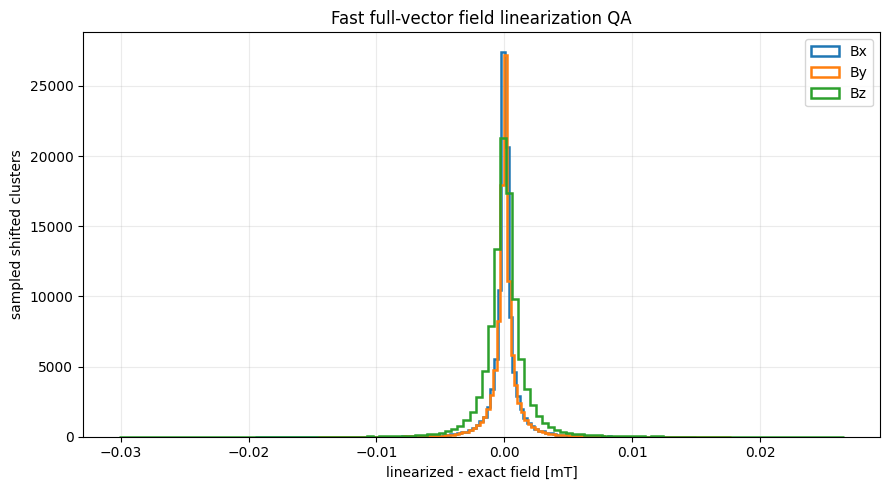

In [6]:
# ============================================================
# Fast-field approximation QA
# ============================================================

rng = np.random.default_rng(seed)
qa_count = min(100000, len(clusters))
qa_indices = rng.choice(len(clusters), size=qa_count, replace=False)

qa_xyz = cluster_xyz[qa_indices]
qa_b0 = cluster_field[qa_indices]
qa_gradient = cluster_field_gradient[qa_indices]

# Typical test shifts of order 2 mm, clipped at 5 mm.
qa_shift = np.clip(
    rng.normal(0.0, 0.20, size=(qa_count, 3)),
    -0.50,
    0.50,
)
qa_xyz_shifted = qa_xyz + qa_shift

qa_exact = np.column_stack(
    evaluate_field_map(
        qa_xyz_shifted[:, 0],
        qa_xyz_shifted[:, 1],
        qa_xyz_shifted[:, 2],
    )
)
qa_linearized = qa_b0 + np.einsum(
    'nij,nj->ni',
    qa_gradient,
    qa_shift,
)

qa_valid = (
    np.all(np.isfinite(qa_exact), axis=1)
    & np.all(np.isfinite(qa_linearized), axis=1)
)
qa_difference_millitesla = 1000.0 * (
    qa_linearized[qa_valid] - qa_exact[qa_valid]
)

print('Field linearization QA rows:', int(np.count_nonzero(qa_valid)))
print(
    'Field linearization mean error [mT] Bx,By,Bz:',
    np.mean(qa_difference_millitesla, axis=0),
)
print(
    'Field linearization RMS error [mT] Bx,By,Bz:',
    np.std(qa_difference_millitesla, axis=0),
)

plt.figure(figsize=(9, 5))
for component, label in enumerate(['Bx', 'By', 'Bz']):
    plt.hist(
        qa_difference_millitesla[:, component],
        bins=120,
        histtype='step',
        linewidth=1.8,
        label=label,
    )
plt.xlabel('linearized - exact field [mT]')
plt.ylabel('sampled shifted clusters')
plt.title('Fast full-vector field linearization QA')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# Full-field baseline convention
# ============================================================
#
# The current V0 reconstruction already supplies the baseline daughter momenta
# and candidate mass. Do NOT apply the old |<Bz>|/1.4 rescaling.
#
# The differentiable response is constructed so that zero DNN correction gives
# momentum_scale=1 and mass_after=selected_mass.

candidates['baseline_mass'] = candidates['selected_mass'].astype(np.float32)

print(
    'Baseline K0S mean mass:',
    float(
        candidates.loc[
            candidates['channel'] == 0,
            'baseline_mass',
        ].mean()
    ),
)


Baseline K0S mean mass: 0.4952790141105652


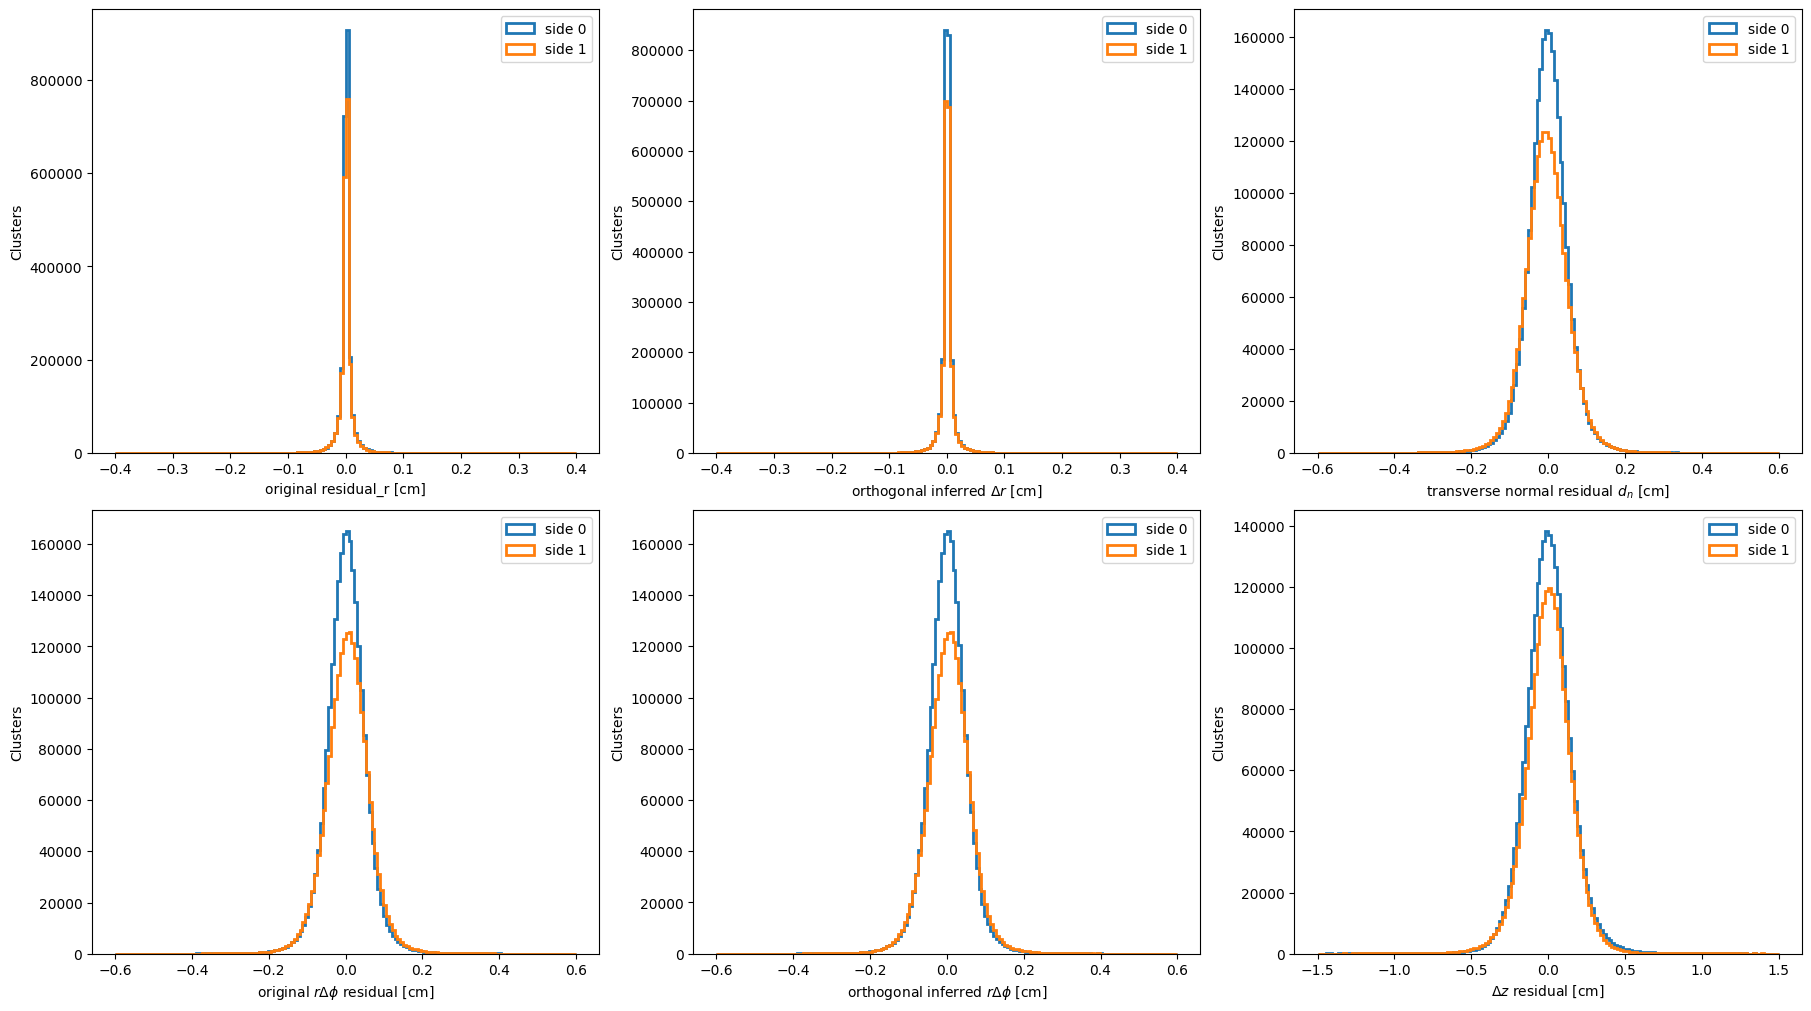

      residual_r  residual_r_orthogonal  residual_rphi  \
side                                                     
0       0.016257               0.014615       0.066938   
1       0.016179               0.014903       0.069657   

      residual_rphi_orthogonal  residual_normal_xy  residual_z  
side                                                            
0                     0.067068            0.068642    0.181524  
1                     0.069741            0.071311    0.181150  


In [8]:
# ============================================================
# Residual QA before training
# ============================================================

kshort_cluster_qa = clusters.loc[
    (clusters['channel'] == 0)
    & clusters['physical_side_z_valid'].astype(bool)
].copy()

figure, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

qa_definitions = [
    ('residual_r', r'original residual_r [cm]', (-0.40, 0.40)),
    ('residual_r_orthogonal', r'orthogonal inferred $\Delta r$ [cm]', (-0.40, 0.40)),
    ('residual_normal_xy', r'transverse normal residual $d_n$ [cm]', (-0.60, 0.60)),
    ('residual_rphi', r'original $r\Delta\phi$ residual [cm]', (-0.60, 0.60)),
    ('residual_rphi_orthogonal', r'orthogonal inferred $r\Delta\phi$ [cm]', (-0.60, 0.60)),
    ('residual_z', r'$\Delta z$ residual [cm]', (-1.50, 1.50)),
]

for axis, (column, label, value_range) in zip(axes.flat, qa_definitions):
    for side in [0, 1]:
        values = kshort_cluster_qa.loc[
            kshort_cluster_qa['side'] == side,
            column,
        ].to_numpy(float)
        values = values[np.isfinite(values)]
        axis.hist(
            values,
            bins=160,
            range=value_range,
            histtype='step',
            linewidth=2,
            label=f'side {side}',
        )
    axis.set_xlabel(label)
    axis.set_ylabel('Clusters')
    axis.legend()

plt.show()

# Directly demonstrate why the original residual_r is not used.
print(
    kshort_cluster_qa.groupby('side')[[
        'residual_r',
        'residual_r_orthogonal',
        'residual_rphi',
        'residual_rphi_orthogonal',
        'residual_normal_xy',
        'residual_z',
    ]].std()
)


## Build one joint K0S candidate sample

Residual pretraining remains side-specific, but the physics stage now uses **all accepted K0S candidates together**, including cross-side candidates when they exist.

Each daughter keeps its own side label. During the differentiable refit, the daughter is passed through the corresponding South/North spatial model. This makes the \(\pi^+/\pi^-\) spectrum constraint truly global instead of imposing it independently on the two detector halves.


In [9]:
# ============================================================
# Joint candidate-to-cluster tensor construction
# ============================================================

FIELD_COMPONENT_COLUMNS = [
    'field_bx_tesla',
    'field_by_tesla',
    'field_bz_tesla',
]

FIELD_GRADIENT_COLUMNS = [
    f'd{field_name}_d{coordinate_name}_tesla_per_cm'
    for field_name in ['bx', 'by', 'bz']
    for coordinate_name in ['x', 'y', 'z']
]


def clean_track_clusters(frame):
    frame = frame.copy()

    finite_columns = [
        'cluster_r', 'cluster_phi', 'cluster_z',
        'residual_normal_xy',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'residual_z', 'sigma_z_filled',
        *FIELD_COMPONENT_COLUMNS,
        *FIELD_GRADIENT_COLUMNS,
    ]

    finite = np.ones(len(frame), dtype=bool)
    for column in finite_columns:
        finite &= np.isfinite(frame[column].to_numpy(float))

    frame = frame.loc[finite]
    frame = frame.loc[frame['physical_side_z_valid'].astype(bool)]
    frame = frame.loc[(frame['layer'] >= 7) & (frame['layer'] <= 54)]
    frame = frame.loc[~frame['layer'].isin(excluded_layers)]

    frame = frame.loc[
        (np.abs(frame['residual_normal_xy']) < maximum_abs_residual_normal_cm)
        & (np.abs(frame['residual_z']) < maximum_abs_residual_z_cm)
    ]

    if use_recommended_clusters_only:
        frame = frame.loc[
            frame['recommended_for_reference_fit'].astype(bool)
        ]

    if use_kalman_used_clusters_only:
        frame = frame.loc[
            frame['kalman_measurement_used'].astype(bool)
        ]

    sort_columns = ['layer']
    if 'kalman_measurement_chi2' in frame.columns:
        sort_columns.append('kalman_measurement_chi2')

    frame = frame.sort_values(sort_columns)
    frame = frame.drop_duplicates('layer', keep='first')

    radial_modules = set(
        frame.loc[
            frame['radial_module'] >= 0,
            'radial_module',
        ].astype(int)
    )
    if len(radial_modules) < minimum_tpc_modules_per_track:
        return frame.iloc[0:0]

    radial_span_cm = (
        float(frame['cluster_r'].max())
        - float(frame['cluster_r'].min())
        if len(frame)
        else 0.0
    )
    if radial_span_cm < minimum_track_radial_span_cm:
        return frame.iloc[0:0]

    return frame.sort_values('layer').head(maximum_clusters)


def build_joint_channel_arrays(channel):
    candidate_frame = candidates.loc[candidates['channel'] == channel].copy()

    candidate_frame = candidate_frame.loc[candidate_frame['pass_cut07'].astype(bool) & candidate_frame['pass_pid'].astype(bool)]

    channel_clusters = clusters.loc[
        clusters['channel'] == channel
    ]

    grouped = {
        key: value
        for key, value in channel_clusters.groupby(
            ['candidate_id', 'daughter'],
            sort=False,
        )
    }

    records = []
    for row in candidate_frame.itertuples(index=False):
        key1 = (row.candidate_id, 1)
        key2 = (row.candidate_id, 2)

        if key1 not in grouped or key2 not in grouped:
            continue

        first = clean_track_clusters(grouped[key1])
        second = clean_track_clusters(grouped[key2])

        if (
            len(first) < minimum_clusters_per_track
            or len(second) < minimum_clusters_per_track
        ):
            continue

        first_side = int(round(float(row.side1)))
        second_side = int(round(float(row.side2)))

        if not np.all(first['side'].to_numpy(int) == first_side):
            continue
        if not np.all(second['side'].to_numpy(int) == second_side):
            continue

        records.append((row, first, second))

    if not records:
        raise RuntimeError(f'No usable candidates for channel={channel}')

    number = len(records)
    shape = (number, maximum_clusters)

    float_track_fields = [
        'r', 'phi_cluster', 'z_cluster',
        'res_normal',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'res_z', 'sigma_z', 'mask',
        'field_bx', 'field_by', 'field_bz',
        'dbx_dx', 'dbx_dy', 'dbx_dz',
        'dby_dx', 'dby_dy', 'dby_dz',
        'dbz_dx', 'dbz_dy', 'dbz_dz',
    ]

    output = {}
    for suffix in ['1', '2']:
        for field in float_track_fields:
            output[f'{field}{suffix}'] = np.zeros(
                shape,
                dtype=np.float32,
            )

    scalar_float_names = [
        'selected_mass', 'baseline_mass', 'pair_pt',
        'pca_x', 'pca_y', 'pca_z',
        'charge1', 'charge2',
        'pt1', 'pt2', 'phi1', 'phi2', 'eta1', 'eta2',
        'px1', 'py1', 'pz1', 'px2', 'py2', 'pz2',
    ]

    for name in scalar_float_names:
        output[name] = np.zeros(number, dtype=np.float32)

    output['candidate_id'] = np.zeros(number, dtype=np.int64)
    output['event_parity'] = np.zeros(number, dtype=np.int64)
    output['side1'] = np.zeros(number, dtype=np.int64)
    output['side2'] = np.zeros(number, dtype=np.int64)
    output['same_side'] = np.zeros(number, dtype=np.int64)
    output['channel'] = np.full(number, channel, dtype=np.int64)

    def fill_track(index, frame, suffix):
        count = len(frame)

        mappings = {
            f'r{suffix}': 'cluster_r',
            f'phi_cluster{suffix}': 'cluster_phi',
            f'z_cluster{suffix}': 'cluster_z',
            f'res_normal{suffix}': 'residual_normal_xy',
            f'normal_projection_r{suffix}': 'normal_projection_r',
            f'normal_projection_rphi{suffix}': 'normal_projection_rphi',
            f'sigma_normal{suffix}': 'sigma_normal',
            f'res_z{suffix}': 'residual_z',
            f'sigma_z{suffix}': 'sigma_z_filled',
            f'field_bx{suffix}': 'field_bx_tesla',
            f'field_by{suffix}': 'field_by_tesla',
            f'field_bz{suffix}': 'field_bz_tesla',
            f'dbx_dx{suffix}': 'dbx_dx_tesla_per_cm',
            f'dbx_dy{suffix}': 'dbx_dy_tesla_per_cm',
            f'dbx_dz{suffix}': 'dbx_dz_tesla_per_cm',
            f'dby_dx{suffix}': 'dby_dx_tesla_per_cm',
            f'dby_dy{suffix}': 'dby_dy_tesla_per_cm',
            f'dby_dz{suffix}': 'dby_dz_tesla_per_cm',
            f'dbz_dx{suffix}': 'dbz_dx_tesla_per_cm',
            f'dbz_dy{suffix}': 'dbz_dy_tesla_per_cm',
            f'dbz_dz{suffix}': 'dbz_dz_tesla_per_cm',
        }

        for output_name, column in mappings.items():
            output[output_name][index, :count] = (
                frame[column].to_numpy(np.float32)
            )

        output[f'mask{suffix}'][index, :count] = 1.0

    for index, (row, first, second) in enumerate(records):
        for name in scalar_float_names:
            output[name][index] = getattr(row, name)

        output['candidate_id'][index] = int(row.candidate_id)
        output['event_parity'][index] = int(row.event_parity)
        output['side1'][index] = int(row.side1)
        output['side2'][index] = int(row.side2)
        output['same_side'][index] = int(bool(row.same_side))

        fill_track(index, first, '1')
        fill_track(index, second, '2')

    output['pair_weight'] = np.ones(number, dtype=np.float32)

    # Filled after the fixed pre-training K0S mass model is fitted.
    output['signal_probability'] = np.ones(number, dtype=np.float32)

    print(
        f'channel={channel}: {number} usable candidates; '
        f'same-side fraction={np.mean(output["same_side"]):.4f}'
    )

    for side in [0, 1]:
        daughter_count = (
            np.count_nonzero(output['side1'] == side)
            + np.count_nonzero(output['side2'] == side)
        )
        print(f'  daughter tracks on side {side}: {daughter_count}')

    return output


kshort_arrays = build_joint_channel_arrays(0)

validation_arrays = {}
for channel in [1, 2]:
    try:
        validation_arrays[channel] = build_joint_channel_arrays(channel)
    except RuntimeError as error:
        print(error)


channel=0: 41643 usable candidates; same-side fraction=0.9740
  daughter tracks on side 0: 42074
  daughter tracks on side 1: 41212
channel=1: 2499 usable candidates; same-side fraction=0.9844
  daughter tracks on side 0: 2489
  daughter tracks on side 1: 2509
channel=2: 2457 usable candidates; same-side fraction=0.9837
  daughter tracks on side 0: 2552
  daughter tracks on side 1: 2362


In [10]:
# ============================================================
# Cache joint arrays
# ============================================================

kshort_npz_file = cache_dir / 'kshort_joint.npz'
np.savez_compressed(kshort_npz_file, **kshort_arrays)
print('Wrote:', kshort_npz_file)

validation_npz_files = {}
for channel, arrays in validation_arrays.items():
    output_file = cache_dir / f'channel{channel}_joint.npz'
    np.savez_compressed(output_file, **arrays)
    validation_npz_files[channel] = output_file
    print('Wrote:', output_file)


def load_npz_dictionary(path):
    with np.load(path, allow_pickle=False) as input_file:
        return {
            key: input_file[key]
            for key in input_file.files
        }


Wrote: output/v0_spatial_residual_dnn_v10_cut07_short_wide/tensor_cache/kshort_joint.npz
Wrote: output/v0_spatial_residual_dnn_v10_cut07_short_wide/tensor_cache/channel1_joint.npz
Wrote: output/v0_spatial_residual_dnn_v10_cut07_short_wide/tensor_cache/channel2_joint.npz


In [11]:
# ============================================================
# PyTorch datasets
# ============================================================

class CandidateDataset(Dataset):
    def __init__(self, arrays, indices):
        self.data = {}
        number_of_candidates = len(arrays['candidate_id'])

        for key, values in arrays.items():
            if (
                isinstance(values, np.ndarray)
                and len(values) == number_of_candidates
            ):
                self.data[key] = torch.from_numpy(values[indices])

    def __len__(self):
        return len(self.data['candidate_id'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


class ResidualDataset(Dataset):
    def __init__(self, arrays):
        self.data = {
            key: torch.from_numpy(value)
            for key, value in arrays.items()
        }

    def __len__(self):
        return len(self.data['r'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


def flatten_training_clusters_for_side(arrays, candidate_indices, side):
    output_lists = {
        key: []
        for key in [
            'r', 'phi', 'z',
            'res_normal',
            'normal_projection_r', 'normal_projection_rphi',
            'sigma_normal',
            'res_z', 'sigma_z',
        ]
    }

    for suffix in ['1', '2']:
        daughter_on_side = (
            arrays[f'side{suffix}'][candidate_indices] == side
        )
        selected_candidate_indices = candidate_indices[daughter_on_side]

        if len(selected_candidate_indices) == 0:
            continue

        mask = (
            arrays[f'mask{suffix}'][selected_candidate_indices] > 0.5
        )

        source_names = {
            'r': f'r{suffix}',
            'phi': f'phi_cluster{suffix}',
            'z': f'z_cluster{suffix}',
            'res_normal': f'res_normal{suffix}',
            'normal_projection_r': f'normal_projection_r{suffix}',
            'normal_projection_rphi': f'normal_projection_rphi{suffix}',
            'sigma_normal': f'sigma_normal{suffix}',
            'res_z': f'res_z{suffix}',
            'sigma_z': f'sigma_z{suffix}',
        }

        for output_name, source_name in source_names.items():
            output_lists[output_name].append(
                arrays[source_name][selected_candidate_indices][mask]
                .astype(np.float32)
            )

    output = {}
    for key, pieces in output_lists.items():
        if not pieces:
            raise RuntimeError(f'No residual clusters for side {side}')
        output[key] = np.concatenate(pieces).astype(np.float32)

    return output


## Smooth drift field + fast full-field response

The spatial network itself is unchanged. The differentiable track response is new:

1. build raw and DNN-corrected 3-D cluster coordinates;
2. evaluate the full magnetic-field vector at both trajectories;
3. estimate \(q/p\) from the vector Lorentz-bending equation over adjacent track segments;
4. update the existing full-field momentum magnitude with the **raw/corrected \(q/p\) ratio**;
5. apply the small raw-to-corrected inner-track tangent change to the input momentum direction.

Because the response is relative, zero correction exactly reproduces the input V0 momentum.


In [12]:
# ============================================================
# Spatial network and differentiable refit helpers
# ============================================================

class SpatialResidualNetwork(nn.Module):
    number_of_sectors = 12
    number_of_radial_modules = 3
    number_of_local_modules = (
        number_of_sectors * number_of_radial_modules
    )

    def __init__(self, side):
        super().__init__()

        if side not in (0, 1):
            raise ValueError('side must be 0 or 1')

        self.side = int(side)

        radial_centers = torch.linspace(
            radial_basis_minimum_cm,
            radial_basis_maximum_cm,
            number_of_radial_basis_functions,
        )

        radial_spacing = (
            radial_basis_maximum_cm
            - radial_basis_minimum_cm
        ) / max(number_of_radial_basis_functions - 1, 1)

        self.register_buffer('radial_centers', radial_centers)
        self.radial_width = radial_basis_width_scale * radial_spacing

        input_width = (
            number_of_radial_basis_functions
            + 2 * number_of_phi_harmonics
            + 2
        )

        layers = []
        width = input_width

        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(width, hidden_width),
                nn.SiLU(),
                nn.Dropout(dropout_probability),
            ])
            width = hidden_width

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(
            width,
            3 if include_z_correction else 2,
        )

        # The smooth drift-dependent DNN starts from zero.
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

        # ----------------------------------------------------
        # Side-level pad-plane alignment
        # ----------------------------------------------------
        #
        # The first two parameters represent constant Delta r
        # and rDeltaPhi offsets at the pad plane.
        #
        # The four tilt parameters describe linear variation in
        # the normalized transverse coordinates:
        #
        # Delta r tilt       = a_x * x_norm + a_y * y_norm
        # rDeltaPhi tilt     = b_x * x_norm + b_y * y_norm
        #
        # tanh keeps every contribution inside its configured
        # physical bound.

        initial_delta_r = float(initial_side_delta_r_cm[self.side])
        initial_rdelta_phi = float(
            initial_side_rdelta_phi_cm[self.side]
        )

        self.side_offset_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                initial_delta_r,
                maximum_side_offset_cm,
            ),
            self.inverse_bounded_tanh(
                initial_rdelta_phi,
                maximum_side_offset_cm,
            ),
        ], dtype=torch.float32))

        initial_tilt = initial_side_tilt_coefficients[self.side]
        if len(initial_tilt) != 4:
            raise ValueError(
                'Each side requires four initial tilt coefficients'
            )

        self.side_tilt_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                float(value),
                maximum_side_tilt_displacement_cm,
            )
            for value in initial_tilt
        ], dtype=torch.float32))

        # One Delta r and one rDeltaPhi displacement for each
        # of the 36 modules on this side. They begin at zero.
        self.module_offset_raw = nn.Parameter(torch.zeros(
            self.number_of_local_modules,
            2,
            dtype=torch.float32,
        ))

    @staticmethod
    def inverse_bounded_tanh(value, maximum):
        if maximum <= 0:
            return 0.0

        ratio = max(
            min(float(value) / float(maximum), 0.999999),
            -0.999999,
        )

        return math.atanh(ratio)

    def physical_domain_and_drift_fraction(self, z):
        if self.side == 0:
            physical = (
                (z <= central_membrane_tolerance_cm)
                & (z >= -z_pad_cm - pad_plane_tolerance_cm)
            )
        else:
            physical = (
                (z >= -central_membrane_tolerance_cm)
                & (z <= z_pad_cm + pad_plane_tolerance_cm)
            )

        drift_fraction = torch.clamp(
            1.0 - torch.abs(z) / z_pad_cm,
            min=0.0,
            max=1.0,
        )

        pad_plane_fraction = 1.0 - drift_fraction

        return (
            physical.to(z.dtype),
            drift_fraction,
            pad_plane_fraction,
        )

    def features(self, r, phi, z):
        radial = torch.exp(
            -0.5
            * (
                (
                    r[..., None]
                    - self.radial_centers
                )
                / self.radial_width
            ) ** 2
        )

        phi_features = []

        for harmonic in range(1, number_of_phi_harmonics + 1):
            phi_features.extend([
                torch.sin(harmonic * phi)[..., None],
                torch.cos(harmonic * phi)[..., None],
            ])

        _, drift_fraction, _ = (
            self.physical_domain_and_drift_fraction(z)
        )

        return torch.cat([
            radial,
            *phi_features,
            drift_fraction[..., None],
            (drift_fraction ** 2)[..., None],
        ], dim=-1)

    def local_module_index(self, r, phi):
        # Radial module from the known TPC boundaries.
        radial_module = torch.zeros_like(r, dtype=torch.long)
        radial_module = torch.where(
            r >= 41.153,
            torch.ones_like(radial_module),
            radial_module,
        )
        radial_module = torch.where(
            r >= 58.367,
            torch.full_like(radial_module, 2),
            radial_module,
        )
        radial_module = torch.clamp(radial_module, 0, 2)

        wrapped_phi = torch.remainder(
            phi + math.pi,
            2.0 * math.pi,
        )

        sector = torch.floor(
            wrapped_phi / (2.0 * math.pi / 12.0)
        ).to(torch.long)
        sector = torch.clamp(sector, 0, 11)

        return 12 * radial_module + sector

    def side_alignment_field(self, r, phi):
        side_offset = (
            maximum_side_offset_cm
            * torch.tanh(self.side_offset_raw)
        )

        tilt = (
            maximum_side_tilt_displacement_cm
            * torch.tanh(self.side_tilt_raw)
        )

        # Normalize x and y by the outer TPC radius. This makes
        # each tilt coefficient approximately the displacement
        # scale reached near the outer edge.
        x_normalized = (
            r * torch.cos(phi)
            / radial_basis_maximum_cm
        )
        y_normalized = (
            r * torch.sin(phi)
            / radial_basis_maximum_cm
        )

        delta_r = (
            side_offset[0]
            + tilt[0] * x_normalized
            + tilt[1] * y_normalized
        )

        r_delta_phi = (
            side_offset[1]
            + tilt[2] * x_normalized
            + tilt[3] * y_normalized
        )

        return delta_r, r_delta_phi

    def module_alignment_field(self, r, phi):
        module_index = self.local_module_index(r, phi)

        bounded_module_offsets = (
            maximum_module_offset_cm
            * torch.tanh(self.module_offset_raw)
        )

        selected = bounded_module_offsets[module_index]

        return selected[..., 0], selected[..., 1]

    def alignment_parameters(self):
        return {
            'side_offset': (
                maximum_side_offset_cm
                * torch.tanh(self.side_offset_raw)
            ),
            'side_tilt': (
                maximum_side_tilt_displacement_cm
                * torch.tanh(self.side_tilt_raw)
            ),
            'module_offset': (
                maximum_module_offset_cm
                * torch.tanh(self.module_offset_raw)
            ),
        }

    def forward(self, r, phi, z):
        (
            physical,
            drift_fraction,
            pad_plane_fraction,
        ) = self.physical_domain_and_drift_fraction(z)

        feature_tensor = self.features(r, phi, z)
        original_shape = r.shape

        raw = self.output(
            self.trunk(
                feature_tensor.reshape(
                    -1,
                    feature_tensor.shape[-1],
                )
            )
        ).reshape(*original_shape, -1)

        drift_delta_r = (
            drift_fraction
            * maximum_delta_r_cm
            * torch.tanh(raw[..., 0])
        )

        drift_r_delta_phi = (
            drift_fraction
            * maximum_r_delta_phi_cm
            * torch.tanh(raw[..., 1])
        )

        side_delta_r, side_r_delta_phi = (
            self.side_alignment_field(r, phi)
        )

        module_delta_r, module_r_delta_phi = (
            self.module_alignment_field(r, phi)
        )

        pad_delta_r = pad_plane_fraction * (
            side_delta_r + module_delta_r
        )

        pad_r_delta_phi = pad_plane_fraction * (
            side_r_delta_phi + module_r_delta_phi
        )

        delta_r = physical * (
            drift_delta_r + pad_delta_r
        )

        r_delta_phi = physical * (
            drift_r_delta_phi + pad_r_delta_phi
        )

        if include_z_correction:
            delta_z = (
                physical
                * drift_fraction
                * maximum_delta_z_cm
                * torch.tanh(raw[..., 2])
            )
        else:
            delta_z = torch.zeros_like(delta_r)

        return delta_r, r_delta_phi, delta_z

def wrap_phi_torch(value):
    return torch.atan2(torch.sin(value), torch.cos(value))


class JointSpatialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.side_models = nn.ModuleDict({
            '0': SpatialResidualNetwork(0),
            '1': SpatialResidualNetwork(1),
        })


def raw_position_from_cylindrical(r, phi, z):
    return torch.stack([
        r * torch.cos(phi),
        r * torch.sin(phi),
        z,
    ], dim=-1)


def field_tensor_from_batch(batch, suffix):
    return torch.stack([
        batch[f'field_bx{suffix}'],
        batch[f'field_by{suffix}'],
        batch[f'field_bz{suffix}'],
    ], dim=-1)


def field_gradient_tensor_from_batch(batch, suffix):
    return torch.stack([
        torch.stack([
            batch[f'dbx_dx{suffix}'],
            batch[f'dbx_dy{suffix}'],
            batch[f'dbx_dz{suffix}'],
        ], dim=-1),
        torch.stack([
            batch[f'dby_dx{suffix}'],
            batch[f'dby_dy{suffix}'],
            batch[f'dby_dz{suffix}'],
        ], dim=-1),
        torch.stack([
            batch[f'dbz_dx{suffix}'],
            batch[f'dbz_dy{suffix}'],
            batch[f'dbz_dz{suffix}'],
        ], dim=-1),
    ], dim=-2)


def corrected_field_from_raw(
    raw_position,
    corrected_position,
    raw_field,
    raw_gradient,
):
    if field_evaluation_mode == 'linearized':
        displacement = corrected_position - raw_position
        return (
            raw_field
            + torch.einsum(
                '...ij,...j->...i',
                raw_gradient,
                displacement,
            )
        )

    if field_evaluation_mode == 'torch_trilinear':
        return torch_trilinear_field(corrected_position)

    raise ValueError(
        f'Unknown field_evaluation_mode={field_evaluation_mode!r}'
    )


def estimate_q_over_p_from_trajectory(position, field, mask):
    """
    Fast full-vector curvature estimator.

    For unit tangent u(s):
        du/ds = 0.00299792458 * (q/p) * (u x B)

    Only the raw/corrected ratio is used downstream.
    """
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]

    ds = torch.sqrt(
        torch.clamp(
            torch.sum(segment * segment, dim=-1),
            min=1.0e-10,
        )
    )

    tangent = segment / ds[..., None]

    bend_mask = segment_mask[:, 1:] * segment_mask[:, :-1]
    ds_mid = 0.5 * (ds[:, 1:] + ds[:, :-1])

    du_ds = (
        tangent[:, 1:, :] - tangent[:, :-1, :]
    ) / torch.clamp(ds_mid[..., None], min=1.0e-6)

    tangent_mid = tangent[:, 1:, :] + tangent[:, :-1, :]
    tangent_mid = tangent_mid / torch.sqrt(
        torch.clamp(
            torch.sum(tangent_mid * tangent_mid, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    field_mid = field[:, 1:-1, :]
    lorentz_direction = torch.cross(
        tangent_mid,
        field_mid,
        dim=-1,
    )

    dot_term = torch.sum(
        du_ds * lorentz_direction,
        dim=-1,
    )
    lorentz_norm2 = torch.sum(
        lorentz_direction * lorentz_direction,
        dim=-1,
    )

    weight = bend_mask * torch.clamp(ds_mid, min=0.0)

    numerator = torch.sum(weight * dot_term, dim=1)
    denominator = (
        lorentz_curvature_constant
        * torch.sum(weight * lorentz_norm2, dim=1)
    )

    q_over_p = numerator / torch.clamp(
        denominator,
        min=1.0e-10,
    )

    effective_bends = torch.sum(bend_mask, dim=1)
    valid = (
        (effective_bends >= 3)
        & torch.isfinite(q_over_p)
        & (torch.abs(q_over_p) > 1.0e-6)
    )

    return q_over_p, valid


def inner_tangent(position, mask):
    """
    Smooth tangent estimate near the innermost accepted TPC clusters.
    Layer ordering is inner -> outer.
    """
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]

    unit = segment / torch.sqrt(
        torch.clamp(
            torch.sum(segment * segment, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    index = torch.arange(
        unit.shape[1],
        dtype=unit.dtype,
        device=unit.device,
    )[None, :]

    weight = segment_mask * torch.exp(-index / 2.0)
    tangent = torch.sum(weight[..., None] * unit, dim=1)

    tangent = tangent / torch.sqrt(
        torch.clamp(
            torch.sum(tangent * tangent, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    return tangent


def refit_track_full_field(
    model,
    r,
    phi,
    z,
    mask,
    charge,
    original_pt,
    original_phi,
    original_eta,
    raw_field,
    raw_field_gradient,
):
    raw_position = raw_position_from_cylindrical(r, phi, z)

    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    corrected_r = r - delta_r * mask
    corrected_phi = (
        phi
        - (
            r_delta_phi
            / torch.clamp(r, min=1.0e-6)
        ) * mask
    )
    corrected_z = z - delta_z * mask

    corrected_position = raw_position_from_cylindrical(
        corrected_r,
        corrected_phi,
        corrected_z,
    )

    corrected_field = corrected_field_from_raw(
        raw_position,
        corrected_position,
        raw_field,
        raw_field_gradient,
    )

    raw_q_over_p, raw_qop_valid = estimate_q_over_p_from_trajectory(
        raw_position,
        raw_field,
        mask,
    )
    corrected_q_over_p, corrected_qop_valid = estimate_q_over_p_from_trajectory(
        corrected_position,
        corrected_field,
        mask,
    )

    relative_scale = (
        torch.abs(raw_q_over_p)
        / torch.clamp(
            torch.abs(corrected_q_over_p),
            min=1.0e-6,
        )
    )

    valid_scale = (
        raw_qop_valid
        & corrected_qop_valid
        & torch.isfinite(relative_scale)
    )

    relative_scale = torch.where(
        valid_scale,
        relative_scale,
        torch.ones_like(relative_scale),
    )

    relative_scale = torch.clamp(
        relative_scale,
        min=minimum_refit_scale,
        max=maximum_refit_scale,
    )

    relative_scale = (
        1.0
        + momentum_scale_response_strength
        * (relative_scale - 1.0)
    )

    original_momentum = torch.stack([
        original_pt * torch.cos(original_phi),
        original_pt * torch.sin(original_phi),
        original_pt * torch.sinh(original_eta),
    ], dim=1)

    original_p = torch.sqrt(
        torch.clamp(
            torch.sum(original_momentum * original_momentum, dim=1),
            min=1.0e-10,
        )
    )
    original_unit = original_momentum / original_p[:, None]

    raw_inner_tangent = inner_tangent(raw_position, mask)
    corrected_inner_tangent = inner_tangent(corrected_position, mask)

    orientation = torch.where(
        torch.sum(raw_inner_tangent * original_unit, dim=1) >= 0.0,
        torch.ones_like(original_p),
        -torch.ones_like(original_p),
    )

    raw_inner_tangent = raw_inner_tangent * orientation[:, None]
    corrected_inner_tangent = corrected_inner_tangent * orientation[:, None]

    direction_delta = corrected_inner_tangent - raw_inner_tangent
    corrected_unit = (
        original_unit
        + direction_correction_strength * direction_delta
    )

    corrected_unit = corrected_unit / torch.sqrt(
        torch.clamp(
            torch.sum(corrected_unit * corrected_unit, dim=1),
            min=1.0e-10,
        )
    )[:, None]

    corrected_p = original_p * relative_scale
    corrected_momentum = corrected_unit * corrected_p[:, None]

    corrected_pt = torch.sqrt(
        torch.clamp(
            corrected_momentum[:, 0] ** 2
            + corrected_momentum[:, 1] ** 2,
            min=0.0,
        )
    )

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'momentum_scale': relative_scale,
        'raw_q_over_p': raw_q_over_p,
        'corrected_q_over_p': corrected_q_over_p,
        'qop_valid': valid_scale,
        'delta_r': delta_r,
        'r_delta_phi': r_delta_phi,
        'delta_z': delta_z,
    }


def scatter_track_results(indices_and_results, number_of_rows):
    all_indices = torch.cat([item[0] for item in indices_and_results])
    order = torch.argsort(all_indices)

    output = {}
    keys = indices_and_results[0][1].keys()

    for key in keys:
        concatenated = torch.cat(
            [item[1][key] for item in indices_and_results],
            dim=0,
        )
        output[key] = concatenated[order]

    if len(all_indices) != number_of_rows:
        raise RuntimeError(
            'Per-side refit did not cover the complete candidate batch'
        )

    return output


def refit_track_by_side(
    joint_model,
    r,
    phi,
    z,
    mask,
    charge,
    original_pt,
    original_phi,
    original_eta,
    track_side,
    raw_field,
    raw_field_gradient,
):
    pieces = []
    side_integer = track_side.to(torch.long)

    for side in [0, 1]:
        indices = torch.nonzero(
            side_integer == side,
            as_tuple=False,
        )[:, 0]

        if len(indices) == 0:
            continue

        result = refit_track_full_field(
            joint_model.side_models[str(side)],
            r[indices],
            phi[indices],
            z[indices],
            mask[indices],
            charge[indices],
            original_pt[indices],
            original_phi[indices],
            original_eta[indices],
            raw_field[indices],
            raw_field_gradient[indices],
        )
        pieces.append((indices, result))

    if not pieces:
        raise RuntimeError('No valid side found in candidate batch')

    return scatter_track_results(pieces, len(track_side))


def invariant_mass(momentum1, momentum2, mass1, mass2):
    energy1 = torch.sqrt(
        torch.sum(momentum1 ** 2, dim=1)
        + mass1 ** 2
    )
    energy2 = torch.sqrt(
        torch.sum(momentum2 ** 2, dim=1)
        + mass2 ** 2
    )

    total = momentum1 + momentum2
    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(total ** 2, dim=1)
    )

    return torch.sqrt(torch.clamp(mass_squared, min=0.0))


Frozen K0S mass models:
{
  "global": {
    "label": "global",
    "signal_fraction": 0.7314903531411037,
    "mean": 0.4959894833046264,
    "sigma": 0.008152788461683035,
    "slope": -0.48457188997335954,
    "fit_nll": -57496.32798115036,
    "n_candidates": 20767,
    "mass_minimum": 0.44,
    "mass_maximum": 0.56
  },
  "pt_bins": [
    {
      "pt_low": 0.5,
      "pt_high": 0.800000011920929,
      "model": {
        "label": "0.5-0.8",
        "signal_fraction": 0.75,
        "mean": 0.4940278790052042,
        "sigma": 0.00560463117359196,
        "slope": -0.3470267404288901,
        "fit_nll": -5547.583014130614,
        "n_candidates": 1803,
        "mass_minimum": 0.44,
        "mass_maximum": 0.56
      }
    },
    {
      "pt_low": 0.800000011920929,
      "pt_high": 1.100000023841858,
      "model": {
        "label": "0.8-1.1",
        "signal_fraction": 0.75,
        "mean": 0.4951613733428885,
        "sigma": 0.00597942254726611,
        "slope": -0.27821250501347

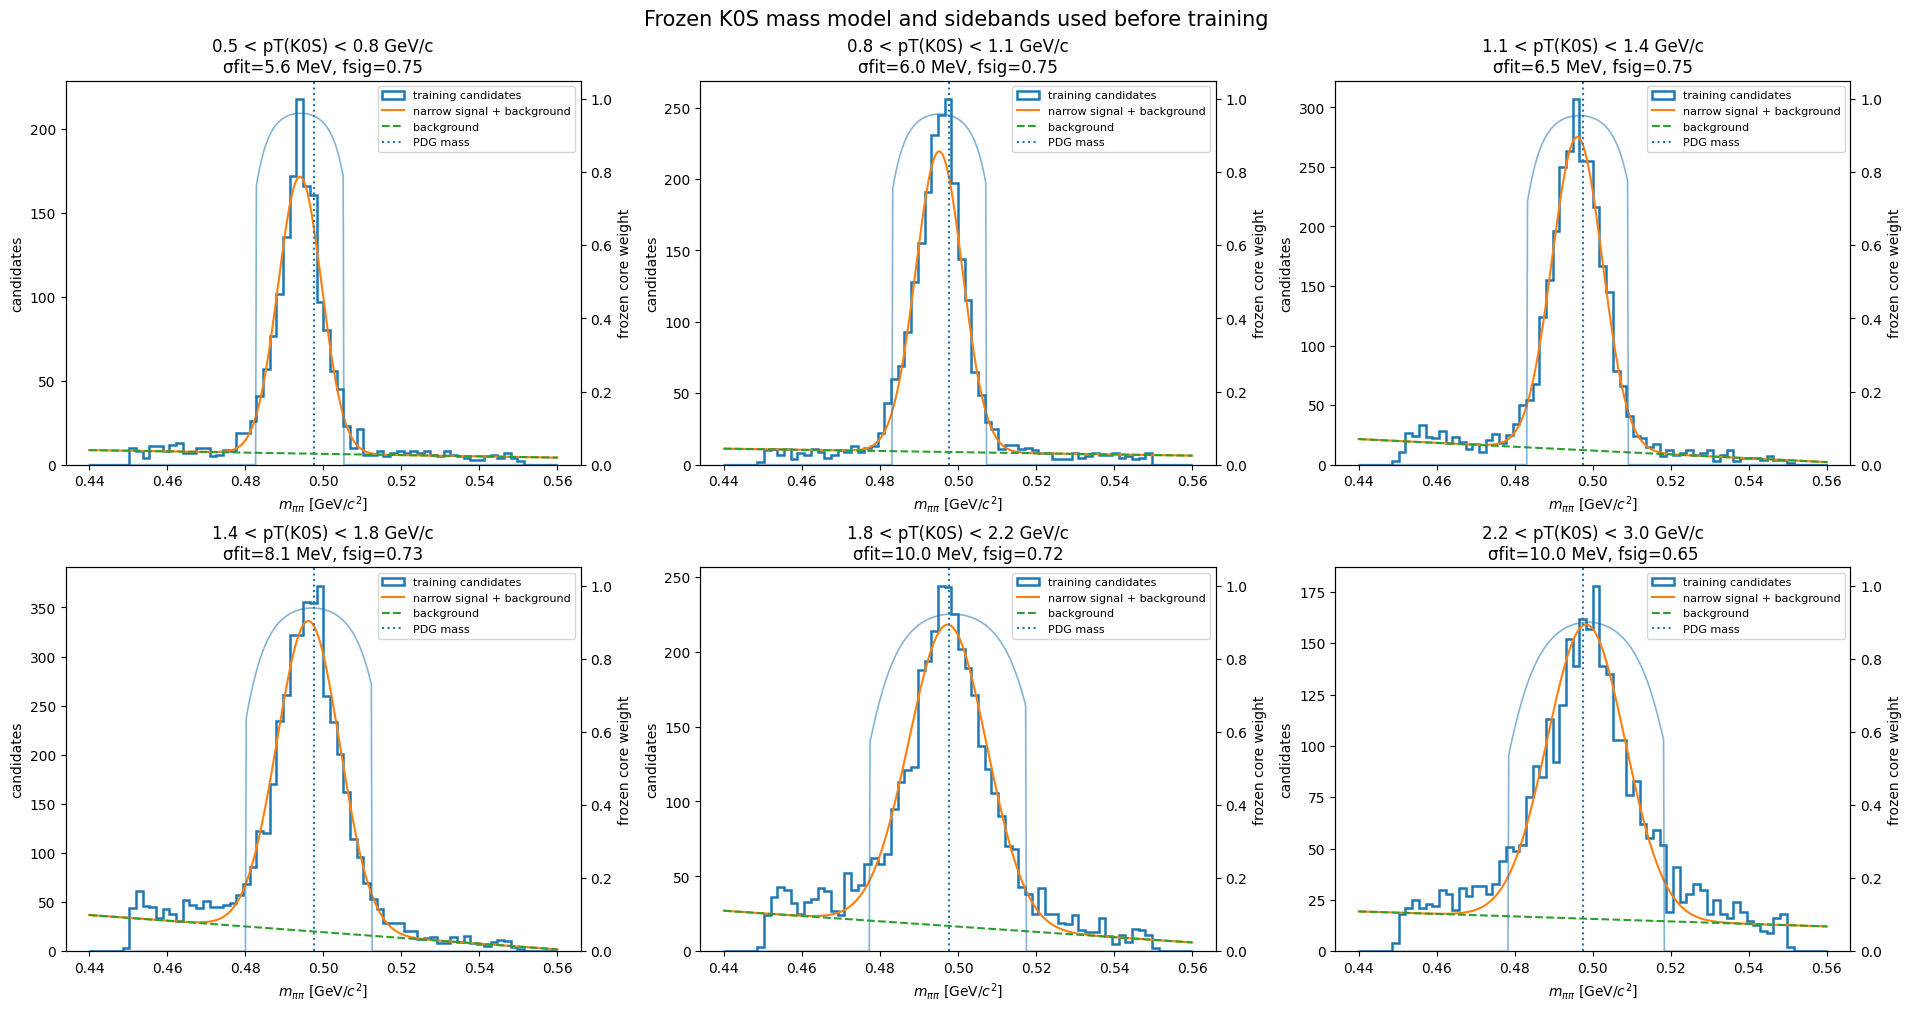

In [13]:
# ============================================================
# Frozen narrow K0S mass model: shared mass + charge gate
# ============================================================
#
# The same frozen baseline-mass core gates BOTH the mass and charge-balance losses.
# Nothing is recomputed from corrected mass, so the network cannot move background
# into the peak to gain charge-balance weight.

from scipy.stats import norm as scipy_norm


def _normalized_linear_background(mass, slope, low=min_k0s_mass, high=max_k0s_mass):
    mass = np.asarray(mass, dtype=np.float64)
    center = 0.5 * (low + high)
    half_width = 0.5 * (high - low)
    u = (mass - center) / max(half_width, 1.0e-12)
    density = np.clip(1.0 + slope * u, 1.0e-8, None)
    return density / (high - low)


def fixed_mass_components(mass_values, model):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    low = model['mass_minimum']
    high = model['mass_maximum']
    signal = scipy_norm.pdf(mass_values, loc=model['mean'], scale=model['sigma'])
    norm_window = scipy_norm.cdf(high, loc=model['mean'], scale=model['sigma']) - scipy_norm.cdf(low, loc=model['mean'], scale=model['sigma'])
    signal = signal / max(norm_window, 1.0e-12)
    background = _normalized_linear_background(mass_values, model['slope'], low, high)
    signal_weighted = model['signal_fraction'] * signal
    background_weighted = (1.0 - model['signal_fraction']) * background
    return signal_weighted, background_weighted


def fit_fixed_k0s_mass_model(mass_values, label='global'):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    mass_values = mass_values[np.isfinite(mass_values) & (mass_values >= min_k0s_mass) & (mass_values <= max_k0s_mass)]

    if mass_values.size < 100:
        raise RuntimeError(f'Not enough K0S candidates to fit mass model {label}: {mass_values.size}')

    def nll(theta):
        fraction, mean, sigma, slope = theta
        model = {
            'signal_fraction': fraction,
            'mean': mean,
            'sigma': sigma,
            'slope': slope,
            'mass_minimum': min_k0s_mass,
            'mass_maximum': max_k0s_mass,
        }
        signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
        return -np.log(np.clip(signal_weighted + background_weighted, 1.0e-15, None)).sum()

    initial = np.array([0.45, pdg_kshort_mass, 0.008, 0.0], dtype=np.float64)
    fit = minimize(
        nll,
        initial,
        method='L-BFGS-B',
        bounds=[
            (k0s_mass_fit_signal_fraction_min, k0s_mass_fit_signal_fraction_max),
            (k0s_mass_fit_mean_min, k0s_mass_fit_mean_max),
            (k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev),
            (-0.90, 0.90),
        ],
    )

    if not fit.success:
        raise RuntimeError(f'K0S mass fit failed for {label}: {fit.message}')

    fraction, mean, sigma, slope = fit.x
    return {
        'label': label,
        'signal_fraction': float(fraction),
        'mean': float(mean),
        'sigma': float(sigma),
        'slope': float(slope),
        'fit_nll': float(fit.fun),
        'n_candidates': int(mass_values.size),
        'mass_minimum': float(min_k0s_mass),
        'mass_maximum': float(max_k0s_mass),
    }


def fixed_signal_probability(mass_values, model):
    signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
    probability = signal_weighted / np.clip(signal_weighted + background_weighted, 1.0e-15, None)
    return np.clip(probability, minimum_signal_probability_for_physics, 1.0).astype(np.float32)


training_mass_mask = kshort_arrays['event_parity'].astype(np.int64) == training_parity
fixed_mass_models = {'global': fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][training_mass_mask], 'global'), 'pt_bins': []}

for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    if np.count_nonzero(selected) >= k0s_mass_model_minimum_candidates_per_pt_bin:
        model = fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][selected], f'{lower:.1f}-{upper:.1f}')
    else:
        model = dict(fixed_mass_models['global'])
        model['label'] = f'{lower:.1f}-{upper:.1f} fallback-global'
        model['n_candidates'] = int(np.count_nonzero(selected))
    fixed_mass_models['pt_bins'].append({'pt_low': float(lower), 'pt_high': float(upper), 'model': model})

# Backward-compatible name used in checkpoint metadata later.
fixed_mass_model = fixed_mass_models['global']


def assign_frozen_mass_weights(mass_values, pair_pt):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    pair_pt = np.asarray(pair_pt, dtype=np.float64)
    probability = fixed_signal_probability(mass_values, fixed_mass_models['global'])
    core_weight = np.zeros(len(mass_values), dtype=np.float32)
    model_mean = np.full(len(mass_values), fixed_mass_models['global']['mean'], dtype=np.float32)
    model_sigma = np.full(len(mass_values), fixed_mass_models['global']['sigma'], dtype=np.float32)

    for item in fixed_mass_models['pt_bins']:
        lower = item['pt_low']
        upper = item['pt_high']
        model = item['model']
        selected = (pair_pt >= lower) & (pair_pt < upper)
        if not np.any(selected):
            continue
        probability[selected] = fixed_signal_probability(mass_values[selected], model)
        model_mean[selected] = model['mean']
        model_sigma[selected] = model['sigma']

    core = np.abs(mass_values - model_mean) <= k0s_mass_core_nsigma * model_sigma
    core_weight[core] = probability[core]
    return probability.astype(np.float32), core_weight, model_mean, model_sigma


(
    kshort_arrays['signal_probability'],
    kshort_arrays['mass_core_weight'],
    kshort_arrays['mass_model_mean'],
    kshort_arrays['mass_model_sigma'],
) = assign_frozen_mass_weights(kshort_arrays['baseline_mass'], kshort_arrays['pair_pt'])

# Fail fast before expensive training if the fit still labels sidebands as signal.
train_mass = kshort_arrays['baseline_mass'][training_mass_mask]
train_probability = kshort_arrays['signal_probability'][training_mass_mask]
global_mean = fixed_mass_models['global']['mean']
global_sigma = fixed_mass_models['global']['sigma']
peak_selection = np.abs(train_mass - global_mean) < 1.5 * global_sigma
sideband_selection = np.abs(train_mass - global_mean) > max(3.0 * global_sigma, 0.025)

peak_probability = float(np.mean(train_probability[peak_selection])) if np.any(peak_selection) else np.nan
sideband_probability = float(np.mean(train_probability[sideband_selection])) if np.any(sideband_selection) else np.nan

print('Frozen K0S mass models:')
print(json.dumps(fixed_mass_models, indent=2))
print('Frozen signal probability: min/mean/max =', float(kshort_arrays['signal_probability'].min()), float(kshort_arrays['signal_probability'].mean()), float(kshort_arrays['signal_probability'].max()))
print('Peak mean P(signal) =', peak_probability)
print('Sideband mean P(signal) =', sideband_probability)
print('Mass-core candidates =', int(np.count_nonzero(kshort_arrays['mass_core_weight'] > 0)), '/', len(kshort_arrays['mass_core_weight']))

if np.isfinite(sideband_probability) and sideband_probability > maximum_allowed_sideband_signal_probability:
    raise RuntimeError(f'Unsafe K0S mass model: sideband P(signal)={sideband_probability:.3f} > {maximum_allowed_sideband_signal_probability:.3f}')
if np.isfinite(peak_probability) and np.isfinite(sideband_probability) and peak_probability - sideband_probability < minimum_peak_minus_sideband_probability:
    raise RuntimeError(f'Unsafe K0S mass model: peak-sideband probability separation is only {peak_probability-sideband_probability:.3f}')

# Refresh the cache with the frozen mass weights.
np.savez_compressed(cache_dir / 'kshort_joint.npz', **kshort_arrays)

# QA: raw mass spectrum plus narrow fitted model in every mother-pT bin.
figure, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
axes = axes.ravel()

for axis, item in zip(axes, fixed_mass_models['pt_bins']):
    lower = item['pt_low']
    upper = item['pt_high']
    model = item['model']
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    values = kshort_arrays['baseline_mass'][selected]
    counts, edges, _ = axis.hist(values, bins=70, range=(min_k0s_mass, max_k0s_mass), histtype='step', linewidth=1.8, label='training candidates')
    grid = np.linspace(min_k0s_mass, max_k0s_mass, 600)
    signal_weighted, background_weighted = fixed_mass_components(grid, model)
    bin_width = edges[1] - edges[0]
    normalization = len(values) * bin_width
    axis.plot(grid, normalization * (signal_weighted + background_weighted), label='narrow signal + background')
    axis.plot(grid, normalization * background_weighted, linestyle='--', label='background')
    probability_grid = fixed_signal_probability(grid, model)
    core_grid = np.abs(grid - model['mean']) <= k0s_mass_core_nsigma * model['sigma']
    axis2 = axis.twinx()
    axis2.plot(grid, probability_grid * core_grid, alpha=0.55, linewidth=1.2, label='charge/mass core weight')
    axis2.set_ylim(0.0, 1.05)
    axis2.set_ylabel('frozen core weight')
    axis.axvline(pdg_kshort_mass, linestyle=':', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{lower:.1f} < pT(K0S) < {upper:.1f} GeV/c\nσfit={1000*model["sigma"]:.1f} MeV, fsig={model["signal_fraction"]:.2f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('candidates')
    axis.legend(fontsize=8)

figure.suptitle('Frozen K0S mass model and sidebands used before training', fontsize=15)
plt.show()


In [14]:
# ============================================================
# Batch correction and global physics losses
# ============================================================

def _track_field_tensors(batch, suffix):
    raw_field = torch.stack([
        batch[f'field_bx{suffix}'],
        batch[f'field_by{suffix}'],
        batch[f'field_bz{suffix}'],
    ], dim=-1)

    gradient = torch.stack([
        batch[f'dbx_dx{suffix}'], batch[f'dbx_dy{suffix}'], batch[f'dbx_dz{suffix}'],
        batch[f'dby_dx{suffix}'], batch[f'dby_dy{suffix}'], batch[f'dby_dz{suffix}'],
        batch[f'dbz_dx{suffix}'], batch[f'dbz_dy{suffix}'], batch[f'dbz_dz{suffix}'],
    ], dim=-1)

    gradient = gradient.reshape(
        *gradient.shape[:-1],
        3,
        3,
    )

    return raw_field, gradient


def correct_batch(joint_model, batch, channel=0):
    field1, gradient1 = _track_field_tensors(batch, '1')
    field2, gradient2 = _track_field_tensors(batch, '2')

    first = refit_track_by_side(
        joint_model,
        batch['r1'],
        batch['phi_cluster1'],
        batch['z_cluster1'],
        batch['mask1'],
        batch['charge1'],
        batch['pt1'],
        batch['phi1'],
        batch['eta1'],
        batch['side1'],
        field1,
        gradient1,
    )

    second = refit_track_by_side(
        joint_model,
        batch['r2'],
        batch['phi_cluster2'],
        batch['z_cluster2'],
        batch['mask2'],
        batch['charge2'],
        batch['pt2'],
        batch['phi2'],
        batch['eta2'],
        batch['side2'],
        field2,
        gradient2,
    )

    if channel == 0:
        mass1 = torch.full_like(batch['charge1'], pion_mass)
        mass2 = torch.full_like(batch['charge2'], pion_mass)
    elif channel == 1:
        # Lambda: positive daughter is proton.
        mass1 = torch.where(
            batch['charge1'] > 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] > 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )
    else:
        # anti-Lambda: negative daughter is antiproton.
        mass1 = torch.where(
            batch['charge1'] < 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] < 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )

    mass = invariant_mass(
        first['momentum'],
        second['momentum'],
        mass1,
        mass2,
    )

    return first, second, mass


def masked_huber(prediction, target, sigma, mask=None):
    normalized = (
        prediction - target
    ) / torch.clamp(sigma, min=1.0e-4)

    loss = F.smooth_l1_loss(
        normalized,
        torch.zeros_like(normalized),
        reduction='none',
    )

    if mask is None:
        return torch.mean(loss)

    return torch.sum(loss * mask) / torch.clamp(
        torch.sum(mask),
        min=1.0,
    )


def residual_batch_loss(model, batch):
    delta_r, r_delta_phi, delta_z = model(
        batch['r'],
        batch['phi'],
        batch['z'],
    )

    predicted_normal = (
        delta_r * batch['normal_projection_r']
        + r_delta_phi * batch['normal_projection_rphi']
    )

    loss = masked_huber(
        predicted_normal,
        batch['res_normal'],
        batch['sigma_normal'],
    )

    if include_z_correction:
        loss = loss + masked_huber(
            delta_z,
            batch['res_z'],
            batch['sigma_z'],
        )

    return loss


def candidate_residual_loss(joint_model, batch):
    track_losses = []

    for suffix in ['1', '2']:
        side_losses = []
        side_weights = []

        for side in [0, 1]:
            selected = (
                batch[f'side{suffix}'].to(torch.long) == side
            )

            if not torch.any(selected):
                continue

            model = joint_model.side_models[str(side)]

            delta_r, r_delta_phi, delta_z = model(
                batch[f'r{suffix}'][selected],
                batch[f'phi_cluster{suffix}'][selected],
                batch[f'z_cluster{suffix}'][selected],
            )

            predicted_normal = (
                delta_r
                * batch[f'normal_projection_r{suffix}'][selected]
                + r_delta_phi
                * batch[f'normal_projection_rphi{suffix}'][selected]
            )

            mask = batch[f'mask{suffix}'][selected]

            loss = masked_huber(
                predicted_normal,
                batch[f'res_normal{suffix}'][selected],
                batch[f'sigma_normal{suffix}'][selected],
                mask,
            )

            if include_z_correction:
                loss = loss + masked_huber(
                    delta_z,
                    batch[f'res_z{suffix}'][selected],
                    batch[f'sigma_z{suffix}'][selected],
                    mask,
                )

            side_losses.append(loss)
            side_weights.append(
                torch.sum(mask).detach()
            )

        if side_losses:
            denominator = torch.clamp(
                torch.stack(side_weights).sum(),
                min=1.0,
            )
            track_losses.append(
                sum(
                    loss * weight
                    for loss, weight in zip(side_losses, side_weights)
                ) / denominator
            )

    if not track_losses:
        first_parameter = next(joint_model.parameters())
        return torch.zeros(
            (),
            dtype=first_parameter.dtype,
            device=first_parameter.device,
        )

    return sum(track_losses) / len(track_losses)


def weighted_mean_variance_neff(values, weights):
    total_weight = torch.sum(weights)
    normalization = torch.clamp(total_weight, min=1.0e-12)

    mean = torch.sum(weights * values) / normalization

    variance = torch.sum(
        weights * (values - mean) ** 2
    ) / normalization

    sum_weight_squared = torch.sum(weights ** 2)
    neff = total_weight ** 2 / torch.clamp(
        sum_weight_squared,
        min=1.0e-12,
    )

    return mean, variance, neff


def corrected_track_pt(track_result):
    momentum = track_result['momentum']
    return torch.sqrt(
        torch.clamp(
            momentum[:, 0] ** 2 + momentum[:, 1] ** 2,
            min=0.0,
        )
    )


def split_corrected_pt_by_charge(first, second, batch):
    pt1 = corrected_track_pt(first)
    pt2 = corrected_track_pt(second)

    charge1 = batch['charge1']
    charge2 = batch['charge2']

    opposite_charge = (
        ((charge1 > 0) & (charge2 < 0))
        | ((charge1 < 0) & (charge2 > 0))
    )

    positive_pt = torch.where(
        charge1 > 0,
        pt1,
        pt2,
    )
    negative_pt = torch.where(
        charge1 < 0,
        pt1,
        pt2,
    )

    base_weight = (
        batch['pair_weight']
        * batch['mass_core_weight']
        * opposite_charge.to(batch['pair_weight'].dtype)
    )

    return positive_pt, negative_pt, base_weight


def soft_histogram_counts_and_squares(
    values,
    weights,
    minimum,
    maximum,
    number_of_bins,
):
    centers = torch.linspace(
        minimum,
        maximum,
        number_of_bins,
        dtype=values.dtype,
        device=values.device,
    )

    if number_of_bins > 1:
        spacing = (
            maximum - minimum
        ) / float(number_of_bins - 1)
    else:
        spacing = 1.0

    kernel_width = max(
        charge_balance_kernel_width_bins * spacing,
        1.0e-6,
    )

    clamped = torch.clamp(
        values,
        min=minimum,
        max=maximum,
    )

    distance = torch.abs(
        clamped[:, None] - centers[None, :]
    )

    assignment = torch.clamp(
        1.0 - distance / kernel_width,
        min=0.0,
    )

    assignment = assignment / torch.clamp(
        torch.sum(assignment, dim=1, keepdim=True),
        min=1.0e-12,
    )

    contribution = assignment * weights[:, None]

    counts = torch.sum(contribution, dim=0)
    sum_squares = torch.sum(contribution ** 2, dim=0)

    return centers, counts, sum_squares


def global_charge_balance_loss(first, second, batch):
    positive_pt, negative_pt, base_weight = (
        split_corrected_pt_by_charge(first, second, batch)
    )

    (
        centers,
        positive_counts,
        positive_sum_squares,
    ) = soft_histogram_counts_and_squares(
        positive_pt,
        base_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    (
        _,
        negative_counts,
        negative_sum_squares,
    ) = soft_histogram_counts_and_squares(
        negative_pt,
        base_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    positive_neff = (
        positive_counts ** 2
        / torch.clamp(positive_sum_squares, min=1.0e-12)
    )
    negative_neff = (
        negative_counts ** 2
        / torch.clamp(negative_sum_squares, min=1.0e-12)
    )

    active = (
        (positive_neff >= charge_balance_minimum_bin_effective_entries)
        & (negative_neff >= charge_balance_minimum_bin_effective_entries)
    )

    log_ratio = torch.log(
        torch.clamp(positive_counts, min=1.0e-8)
        / torch.clamp(negative_counts, min=1.0e-8)
    )

    statistical_variance = (
        1.0 / torch.clamp(positive_neff, min=1.0)
        + 1.0 / torch.clamp(negative_neff, min=1.0)
    )

    total_variance = (
        statistical_variance
        + charge_balance_systematic_floor_fraction ** 2
    )

    priority = torch.clamp(
        (
            centers
            / charge_balance_pt_priority_reference_gev
        ) ** charge_balance_pt_priority_power,
        max=charge_balance_maximum_priority,
    )

    bin_weight = (
        active.to(log_ratio.dtype)
        * priority
        / torch.clamp(total_variance, min=1.0e-8)
    )

    loss = torch.sum(
        bin_weight * log_ratio ** 2
    ) / torch.clamp(
        torch.sum(bin_weight),
        min=1.0,
    )

    diagnostics = {
        'centers': centers,
        'positive_counts': positive_counts,
        'negative_counts': negative_counts,
        'positive_neff': positive_neff,
        'negative_neff': negative_neff,
        'log_ratio': log_ratio,
        'total_variance': total_variance,
        'priority': priority,
        'active': active,
    }

    return loss, diagnostics


def charge_candidate_weights(batch):
    return batch['pair_weight'] * batch['mass_core_weight']


def mass_candidate_weights(batch):
    return batch['pair_weight'] * batch['mass_core_weight']


def physics_candidate_weights(batch):
    # Charge and mass use the same frozen baseline-mass core.
    return charge_candidate_weights(batch)


def pt_binned_mass_loss(corrected_mass, batch):
    weights_all = mass_candidate_weights(batch)
    total_loss = torch.zeros((), dtype=corrected_mass.dtype, device=corrected_mass.device)
    total_weight = torch.zeros_like(total_loss)
    diagnostics = []
    baseline_mass = batch['baseline_mass']

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selection = (batch['pair_pt'] >= float(lower)) & (batch['pair_pt'] < float(upper))
        weights = weights_all * selection.to(weights_all.dtype)

        corrected_mean, corrected_variance, neff = weighted_mean_variance_neff(corrected_mass, weights)
        baseline_mean, baseline_variance, _ = weighted_mean_variance_neff(baseline_mass, weights)

        active = (neff >= pt_mass_scale_minimum_effective_entries).to(corrected_mass.dtype)

        # IMPORTANT: use BASELINE width in the uncertainty.
        # Broadening the corrected peak can no longer reduce the mean pull.
        mean_standard_error = torch.sqrt(
            torch.clamp(
                baseline_variance / torch.clamp(neff, min=1.0) + pt_mass_mean_systematic_floor_gev ** 2,
                min=1.0e-12,
            )
        )

        mean_pull_squared = ((corrected_mean - pdg_kshort_mass) / mean_standard_error) ** 2

        width_ratio = torch.sqrt(
            torch.clamp(
                corrected_variance / torch.clamp(baseline_variance, min=1.0e-8),
                min=0.0,
            )
        )

        # Linear excess gives useful gradient immediately above ratio=1.
        width_guard = torch.relu(width_ratio - 1.0)

        center = 0.5 * (float(lower) + float(upper))
        priority = min(
            (center / pt_mass_priority_reference_gev) ** pt_mass_priority_power,
            pt_mass_maximum_priority,
        )

        bin_weight = active * float(priority) * torch.sqrt(torch.clamp(neff, min=0.0))
        bin_loss = mean_pull_squared + pt_mass_width_guard_weight * width_guard

        total_loss = total_loss + bin_weight * bin_loss
        total_weight = total_weight + bin_weight

        diagnostics.append({
            'lower': float(lower),
            'upper': float(upper),
            'neff': neff,
            'corrected_mean': corrected_mean,
            'baseline_mean': baseline_mean,
            'corrected_variance': corrected_variance,
            'baseline_variance': baseline_variance,
            'mean_pull_squared': mean_pull_squared,
            'width_ratio': width_ratio,
            'width_guard': width_guard,
            'active': active,
            'priority': float(priority),
        })

    return total_loss / torch.clamp(total_weight, min=1.0), diagnostics


def inclusive_mass_mean_loss(corrected_mass, batch):
    weights = mass_candidate_weights(batch)

    corrected_mean, corrected_variance, neff = weighted_mean_variance_neff(corrected_mass, weights)
    baseline_mean, baseline_variance, _ = weighted_mean_variance_neff(batch['baseline_mass'], weights)

    # Again: uncertainty is frozen to the INPUT width.
    standard_error = torch.sqrt(
        torch.clamp(
            baseline_variance / torch.clamp(neff, min=1.0) + pt_mass_mean_systematic_floor_gev ** 2,
            min=1.0e-12,
        )
    )

    mean_pull_squared = ((corrected_mean - pdg_kshort_mass) / standard_error) ** 2

    width_ratio = torch.sqrt(
        torch.clamp(
            corrected_variance / torch.clamp(baseline_variance, min=1.0e-8),
            min=0.0,
        )
    )

    width_guard = torch.relu(width_ratio - 1.0)

    return mean_pull_squared + inclusive_mass_width_guard_weight * width_guard

def regularization_from_points(model, r, phi, z, mask):
    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    normalization = torch.clamp(mask.sum(), min=1.0)

    amplitude_r = torch.sum(
        (delta_r / 0.25) ** 2 * mask
    ) / normalization

    amplitude_rphi = torch.sum(
        (r_delta_phi / 0.10) ** 2 * mask
    ) / normalization

    if include_z_correction:
        amplitude_z = torch.sum(
            (delta_z / 0.20) ** 2 * mask
        ) / normalization
    else:
        amplitude_z = torch.zeros_like(amplitude_r)

    perturbed_r = torch.clamp(
        r + 0.25 * torch.randn_like(r),
        radial_basis_minimum_cm,
        radial_basis_maximum_cm,
    )
    perturbed_phi = phi + 0.005 * torch.randn_like(phi)
    perturbed_z = z + 0.50 * torch.randn_like(z)

    if model.side == 0:
        perturbed_z = torch.clamp(
            perturbed_z,
            -z_pad_cm,
            0.0,
        )
    else:
        perturbed_z = torch.clamp(
            perturbed_z,
            0.0,
            z_pad_cm,
        )

    dr_noise, rdphi_noise, dz_noise = model(
        perturbed_r,
        perturbed_phi,
        perturbed_z,
    )

    smoothness_r = torch.sum(
        ((dr_noise - delta_r) / 0.040) ** 2 * mask
    ) / normalization

    smoothness_rphi = torch.sum(
        ((rdphi_noise - r_delta_phi) / 0.020) ** 2 * mask
    ) / normalization

    if include_z_correction:
        smoothness_z = torch.sum(
            ((dz_noise - delta_z) / 0.050) ** 2 * mask
        ) / normalization
    else:
        smoothness_z = torch.zeros_like(smoothness_r)

    mean_field = (
        torch.sum(delta_r * mask)
        / normalization
        / 0.25
    ) ** 2 + (
        torch.sum(r_delta_phi * mask)
        / normalization
        / 0.10
    ) ** 2

    if include_z_correction:
        mean_field = mean_field + (
            torch.sum(delta_z * mask)
            / normalization
            / 0.20
        ) ** 2

    alignment = model.alignment_parameters()

    side_offset_prior = torch.mean(
        (
            alignment['side_offset']
            / max(maximum_side_offset_cm, 1.0e-6)
        ) ** 2
    )

    side_tilt_prior = torch.mean(
        (
            alignment['side_tilt']
            / max(maximum_side_tilt_displacement_cm, 1.0e-6)
        ) ** 2
    )

    module_offset = alignment['module_offset']
    module_zero_mean = torch.mean(
        torch.mean(module_offset, dim=0) ** 2
    ) / max(maximum_module_offset_cm ** 2, 1.0e-8)

    module_rms = torch.mean(
        module_offset ** 2
    ) / max(maximum_module_offset_cm ** 2, 1.0e-8)

    return {
        'amplitude_r': amplitude_r,
        'amplitude_rphi': amplitude_rphi,
        'amplitude_z': amplitude_z,
        'smoothness_r': smoothness_r,
        'smoothness_rphi': smoothness_rphi,
        'smoothness_z': smoothness_z,
        'mean_field': mean_field,
        'side_alignment_prior': (
            side_offset_prior + side_tilt_prior
        ),
        'module_zero_mean': module_zero_mean,
        'module_rms': module_rms,
    }


def joint_regularization_losses(joint_model, batch):
    accumulator = None
    number_of_parts = 0

    for suffix in ['1', '2']:
        for side in [0, 1]:
            selection = (
                batch[f'side{suffix}'].to(torch.long)
                == side
            )

            if not torch.any(selection):
                continue

            values = regularization_from_points(
                joint_model.side_models[str(side)],
                batch[f'r{suffix}'][selection],
                batch[f'phi_cluster{suffix}'][selection],
                batch[f'z_cluster{suffix}'][selection],
                batch[f'mask{suffix}'][selection],
            )

            if accumulator is None:
                accumulator = {
                    key: value
                    for key, value in values.items()
                }
            else:
                for key, value in values.items():
                    accumulator[key] = accumulator[key] + value

            number_of_parts += 1

    if accumulator is None:
        raise RuntimeError('No side present for regularization')

    return {
        key: value / number_of_parts
        for key, value in accumulator.items()
    }


def total_regularization_loss(terms):
    return (
        delta_r_amplitude_loss_weight * terms['amplitude_r']
        + rdelta_phi_amplitude_loss_weight * terms['amplitude_rphi']
        + delta_z_amplitude_loss_weight * terms['amplitude_z']
        + delta_r_smoothness_loss_weight * terms['smoothness_r']
        + rdelta_phi_smoothness_loss_weight * terms['smoothness_rphi']
        + delta_z_smoothness_loss_weight * terms['smoothness_z']
        + mean_field_loss_weight * terms['mean_field']
        + alignment_prior_weight * terms['side_alignment_prior']
        + module_zero_mean_weight * terms['module_zero_mean']
        + module_rms_weight * terms['module_rms']
    )


In [15]:
# ============================================================
# Sanity check: zero spatial correction must preserve baseline momenta/mass
# ============================================================
#
# The trainable geometry profile may intentionally start with non-zero side
# offsets, so use an explicit zero model for this identity check.

class ZeroSpatialModel(nn.Module):
    def __init__(self, side):
        super().__init__()
        self.side = int(side)
        self.dummy = nn.Parameter(torch.zeros(()), requires_grad=False)

    def forward(self, r, phi, z):
        zero = torch.zeros_like(r)
        return zero, zero, zero


class ZeroJointSpatialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.side_models = nn.ModuleDict({
            '0': ZeroSpatialModel(0),
            '1': ZeroSpatialModel(1),
        })


zero_joint_model = ZeroJointSpatialModel().eval()

zero_check_indices = np.flatnonzero(
    kshort_arrays['event_parity'].astype(np.int64) == training_parity
)[: min(2048, np.count_nonzero(
    kshort_arrays['event_parity'].astype(np.int64) == training_parity
))]

zero_check_loader = DataLoader(
    CandidateDataset(kshort_arrays, zero_check_indices),
    batch_size=max(1, len(zero_check_indices)),
    shuffle=False,
)

zero_batch = next(iter(zero_check_loader))

with torch.no_grad():
    zero_first, zero_second, zero_mass = correct_batch(
        zero_joint_model,
        zero_batch,
        channel=0,
    )

baseline_mass = zero_batch['baseline_mass']

mass_difference_mev = (
    zero_mass - baseline_mass
) * 1000.0

print(
    'zero-map mass difference [MeV]: '
    f'mean={float(mass_difference_mev.mean()):+.6f}, '
    f'RMS={float(mass_difference_mev.std()):.6f}, '
    f'max|diff|={float(torch.max(torch.abs(mass_difference_mev))):.6f}'
)

for label, result, original_pt, original_eta in [
    ('daughter 1', zero_first, zero_batch['pt1'], zero_batch['eta1']),
    ('daughter 2', zero_second, zero_batch['pt2'], zero_batch['eta2']),
]:
    scale = result['momentum_scale']
    valid = result['qop_valid']

    print(
        label,
        'zero-map momentum scale:',
        f'mean={float(scale.mean()):.8f}, '
        f'RMS={float(scale.std()):.8f}, '
        f'q/p valid={float(valid.float().mean()):.3f}'
    )

    # Absolute q/p is only a diagnostic. Training uses the ratio
    # q/p(raw) / q/p(corrected), which cancels much of this approximation bias.
    original_p = original_pt * torch.cosh(original_eta)
    qop_abs_p = 1.0 / torch.clamp(
        torch.abs(result['raw_q_over_p']),
        min=1.0e-6,
    )

    good = (
        valid
        & torch.isfinite(qop_abs_p)
        & torch.isfinite(original_p)
        & (original_p > 0)
    )

    if torch.any(good):
        ratio = (
            qop_abs_p[good]
            / original_p[good]
        ).cpu().numpy()

        q16, q50, q84 = np.quantile(
            ratio,
            [0.16, 0.50, 0.84],
        )

        print(
            f'  absolute-q/p diagnostic p_est/p_input: '
            f'median={q50:.3f}, 16-84%=[{q16:.3f}, {q84:.3f}]'
        )

print(
    '\nInterpretation: the full-vector trajectory estimator is used only for '
    'the *relative* response to a spatial correction. At exactly zero spatial '
    'correction, the original full-field V0 momentum is preserved by construction.'
)


zero-map mass difference [MeV]: mean=-0.000018, RMS=0.000477, max|diff|=0.003099
daughter 1 zero-map momentum scale: mean=1.00000000, RMS=0.00000000, q/p valid=1.000
  absolute-q/p diagnostic p_est/p_input: median=1.011, 16-84%=[0.622, 2.001]
daughter 2 zero-map momentum scale: mean=1.00000000, RMS=0.00000000, q/p valid=1.000
  absolute-q/p diagnostic p_est/p_input: median=0.985, 16-84%=[0.594, 2.018]

Interpretation: the full-vector trajectory estimator is used only for the *relative* response to a spatial correction. At exactly zero spatial correction, the original full-field V0 momentum is preserved by construction.


In [16]:
# ============================================================
# Validation helpers
# ============================================================

def peak_metrics(values, weights=None):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    values = values[finite]

    if weights is None:
        weights = np.ones(len(values), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[finite]

    if len(values) == 0 or np.sum(weights) <= 0:
        return {
            'mean': np.nan,
            'width': np.nan,
            'neff': 0.0,
        }

    total = np.sum(weights)
    mean = np.sum(weights * values) / total
    variance = np.sum(weights * (values - mean) ** 2) / total
    neff = total ** 2 / max(np.sum(weights ** 2), 1.0e-12)

    return {
        'mean': float(mean),
        'width': float(np.sqrt(max(variance, 0.0))),
        'neff': float(neff),
    }


def numpy_global_charge_balance(
    positive_pt,
    negative_pt,
    weights,
):
    positive_pt = np.asarray(positive_pt, dtype=float)
    negative_pt = np.asarray(negative_pt, dtype=float)
    weights = np.asarray(weights, dtype=float)

    edges = np.linspace(
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins + 1,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])

    positive_counts, _ = np.histogram(
        positive_pt,
        bins=edges,
        weights=weights,
    )
    negative_counts, _ = np.histogram(
        negative_pt,
        bins=edges,
        weights=weights,
    )

    positive_sum_squares, _ = np.histogram(
        positive_pt,
        bins=edges,
        weights=weights ** 2,
    )
    negative_sum_squares, _ = np.histogram(
        negative_pt,
        bins=edges,
        weights=weights ** 2,
    )

    positive_neff = (
        positive_counts ** 2
        / np.maximum(positive_sum_squares, 1.0e-12)
    )
    negative_neff = (
        negative_counts ** 2
        / np.maximum(negative_sum_squares, 1.0e-12)
    )

    ratio = positive_counts / np.maximum(
        negative_counts,
        1.0e-12,
    )

    sigma_log = np.sqrt(
        1.0 / np.maximum(positive_neff, 1.0)
        + 1.0 / np.maximum(negative_neff, 1.0)
        + charge_balance_systematic_floor_fraction ** 2
    )

    active = (
        (positive_neff >= charge_balance_minimum_bin_effective_entries)
        & (negative_neff >= charge_balance_minimum_bin_effective_entries)
        & (positive_counts > 0)
        & (negative_counts > 0)
    )

    priority = np.minimum(
        (
            centers
            / charge_balance_pt_priority_reference_gev
        ) ** charge_balance_pt_priority_power,
        charge_balance_maximum_priority,
    )

    log_ratio = np.log(np.maximum(ratio, 1.0e-12))

    score_weight = np.where(
        active,
        priority / np.maximum(sigma_log ** 2, 1.0e-12),
        0.0,
    )

    score = (
        np.sum(score_weight * log_ratio ** 2)
        / max(np.sum(score_weight), 1.0)
    )

    return {
        'edges': edges,
        'centers': centers,
        'positive_counts': positive_counts,
        'negative_counts': negative_counts,
        'positive_neff': positive_neff,
        'negative_neff': negative_neff,
        'ratio': ratio,
        'log_ratio': log_ratio,
        'sigma_log': sigma_log,
        'active': active,
        'priority': priority,
        'score': float(score),
    }


def numpy_pt_mass_score(corrected_mass, baseline_mass, pair_pt, weights):
    corrected_mass = np.asarray(corrected_mass, dtype=float)
    baseline_mass = np.asarray(baseline_mass, dtype=float)
    pair_pt = np.asarray(pair_pt, dtype=float)
    weights = np.asarray(weights, dtype=float)

    rows = []
    total_score = 0.0
    total_weight = 0.0

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (pair_pt >= lower) & (pair_pt < upper)

        if not np.any(selected):
            continue

        corrected = peak_metrics(corrected_mass[selected], weights[selected])
        baseline = peak_metrics(baseline_mass[selected], weights[selected])

        active = corrected['neff'] >= pt_mass_scale_minimum_effective_entries
        center = 0.5 * (float(lower) + float(upper))
        priority = min(
            (center / pt_mass_priority_reference_gev) ** pt_mass_priority_power,
            pt_mass_maximum_priority,
        )

        # Freeze uncertainty to baseline width.
        standard_error = math.sqrt(
            baseline['width'] ** 2 / max(corrected['neff'], 1.0)
            + pt_mass_mean_systematic_floor_gev ** 2
        )

        pull2 = (
            (corrected['mean'] - pdg_kshort_mass)
            / max(standard_error, 1.0e-8)
        ) ** 2

        width_ratio = corrected['width'] / max(baseline['width'], 1.0e-8)
        width_guard = max(width_ratio - 1.0, 0.0)

        weight = priority * math.sqrt(max(corrected['neff'], 0.0)) if active else 0.0
        total_score += weight * (pull2 + pt_mass_width_guard_weight * width_guard)
        total_weight += weight

        rows.append({
            'lower': float(lower),
            'upper': float(upper),
            'corrected_mean': corrected['mean'],
            'corrected_width': corrected['width'],
            'baseline_mean': baseline['mean'],
            'baseline_width': baseline['width'],
            'width_ratio': width_ratio,
            'neff': corrected['neff'],
            'active': active,
            'priority': priority,
            'pull2': pull2,
            'width_guard': width_guard,
        })

    return total_score / max(total_weight, 1.0), pd.DataFrame(rows)
def evaluate_joint_model(joint_model, loader, channel=0):
    joint_model.eval()

    collected = {
        'mass_before': [],
        'mass_after': [],
        'pair_pt': [],
        'pair_weight': [],
        'signal_probability': [],
        'mass_core_weight': [],
        'pt_positive_before': [],
        'pt_negative_before': [],
        'pt_positive_after': [],
        'pt_negative_after': [],
        'pt1_after': [],
        'pt2_after': [],
        'charge1': [],
        'charge2': [],
        'momentum_scale1': [],
        'momentum_scale2': [],
        'side1': [],
        'side2': [],
    }

    with torch.no_grad():
        for batch in loader:
            first, second, mass_after = correct_batch(
                joint_model,
                batch,
                channel=channel,
            )

            mass_before = batch['baseline_mass']

            pt1_after = corrected_track_pt(first)
            pt2_after = corrected_track_pt(second)

            positive_before = torch.where(
                batch['charge1'] > 0,
                batch['pt1'],
                batch['pt2'],
            )
            negative_before = torch.where(
                batch['charge1'] < 0,
                batch['pt1'],
                batch['pt2'],
            )

            positive_after = torch.where(
                batch['charge1'] > 0,
                pt1_after,
                pt2_after,
            )
            negative_after = torch.where(
                batch['charge1'] < 0,
                pt1_after,
                pt2_after,
            )

            values = {
                'mass_before': mass_before,
                'mass_after': mass_after,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'signal_probability': batch['signal_probability'],
                'mass_core_weight': batch.get('mass_core_weight', torch.ones_like(batch['pair_weight'])),
                'pt_positive_before': positive_before,
                'pt_negative_before': negative_before,
                'pt_positive_after': positive_after,
                'pt_negative_after': negative_after,
                'pt1_after': pt1_after,
                'pt2_after': pt2_after,
                'charge1': batch['charge1'],
                'charge2': batch['charge2'],
                'momentum_scale1': first['momentum_scale'],
                'momentum_scale2': second['momentum_scale'],
                'side1': batch['side1'],
                'side2': batch['side2'],
            }

            for key, value in values.items():
                collected[key].append(
                    value.detach().cpu().numpy()
                )

    for key in collected:
        collected[key] = np.concatenate(collected[key])

    charge_weights = collected['pair_weight'] * collected['signal_probability']
    mass_weights = collected['pair_weight'] * collected['mass_core_weight']

    result = {
        'arrays': collected,
        'before_peak': peak_metrics(collected['mass_before'], mass_weights),
        'after_peak': peak_metrics(collected['mass_after'], mass_weights),
    }

    if channel == 0:
        charge_before = numpy_global_charge_balance(collected['pt_positive_before'], collected['pt_negative_before'], charge_weights)
        charge_after = numpy_global_charge_balance(collected['pt_positive_after'], collected['pt_negative_after'], charge_weights)
        mass_score, mass_table = numpy_pt_mass_score(collected['mass_after'], collected['mass_before'], collected['pair_pt'], mass_weights)

        width_ratio = result['after_peak']['width'] / max(result['before_peak']['width'], 1.0e-8)
        width_valid = width_ratio <= maximum_validation_width_ratio
        
        result.update({
            'charge_before': charge_before,
            'charge_after': charge_after,
            'mass_score': float(mass_score),
            'mass_table': mass_table,
            'width_ratio': float(width_ratio),
            'width_valid': bool(width_valid),
            'score': (
                charge_after['score'] + pt_mass_scale_loss_weight * mass_score
                if width_valid else np.inf
            ),
        })

    return result


## Two-stage training: residual initialization, then one global K0S physics fit

Stage A keeps the useful part of the previous workflow: each TPC side is initialized from its own local track residuals.

Stage B is deliberately different.  The South and North spatial models are put into one `JointSpatialModel` and optimized together.  Every K0S contributes to the same global positive/negative daughter spectrum, including candidates whose daughters are on different sides.

The hybrid objective is

\[
L =
1.00\,L_{\rm charge}
+0.70\,L_{m,p_T}
+0.15\,L_{m,\rm incl}
+0.08\,L_{\rm residual}
+L_{\rm regularization}.
\]

Before hybrid training, the four main loss components are measured on the initialized model and divided by those initial scales. The coefficients therefore encode the intended hierarchy rather than arbitrary raw loss units.

For charge balance, each pT bin has a statistical uncertainty from its effective weighted entries plus a 5% systematic floor. High-pT bins receive a smooth priority factor, but bins with too few effective entries are disabled rather than allowed to drive the map through fluctuations.


In [17]:
# ============================================================
# Stage A side residual pretraining + Stage B global hybrid training
# ============================================================

def configure_worker_threads(number_of_threads):
    os.environ['OMP_NUM_THREADS'] = str(number_of_threads)
    os.environ['MKL_NUM_THREADS'] = str(number_of_threads)
    os.environ['OPENBLAS_NUM_THREADS'] = str(number_of_threads)
    os.environ['NUMEXPR_NUM_THREADS'] = str(number_of_threads)

    torch.set_num_threads(number_of_threads)

    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def pretrain_side_worker(side, ensemble_index):
    started = time.time()

    try:
        configure_worker_threads(threads_per_side)

        model_seed = seed + 10000 * side + ensemble_index
        random.seed(model_seed)
        np.random.seed(model_seed)
        torch.manual_seed(model_seed)

        arrays = load_npz_dictionary(kshort_npz_file)

        training_indices = np.flatnonzero(
            arrays['event_parity'].astype(np.int64) == training_parity
        )

        residual_arrays = flatten_training_clusters_for_side(
            arrays,
            training_indices,
            side,
        )

        residual_loader = DataLoader(
            ResidualDataset(residual_arrays),
            batch_size=min(
                residual_batch_size,
                len(residual_arrays['r']),
            ),
            shuffle=True,
            num_workers=0,
            drop_last=False,
        )

        model = SpatialResidualNetwork(side)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )

        history = []

        for epoch in range(residual_pretraining_epochs):
            model.train()
            loss_sum = 0.0
            number_of_batches = 0

            for batch in residual_loader:
                optimizer.zero_grad(set_to_none=True)

                loss = residual_batch_loss(model, batch)

                if not torch.isfinite(loss):
                    raise FloatingPointError(
                        'Non-finite residual pretraining loss'
                    )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0,
                )
                optimizer.step()

                loss_sum += float(loss.detach())
                number_of_batches += 1

            average = loss_sum / max(number_of_batches, 1)

            history.append({
                'epoch': epoch,
                'residual_loss': average,
            })

            if epoch % 10 == 0 or epoch == residual_pretraining_epochs - 1:
                print(
                    f'[side {side}, ensemble {ensemble_index}] '
                    f'residual epoch {epoch}: {average:.6f}'
                )

        checkpoint = (
            checkpoint_dir
            / f'pretrained_side{side}_ensemble{ensemble_index}.pt'
        )

        torch.save({
            'state_dict': model.state_dict(),
            'side': side,
            'ensemble_index': ensemble_index,
            'model_seed': model_seed,
        }, checkpoint)

        pd.DataFrame(history).to_csv(
            work_dir
            / f'residual_history_side{side}_ensemble{ensemble_index}.csv',
            index=False,
        )

        return {
            'success': True,
            'side': side,
            'ensemble_index': ensemble_index,
            'checkpoint': str(checkpoint),
            'elapsed_seconds': time.time() - started,
        }

    except Exception as error:
        traceback.print_exc()
        return {
            'success': False,
            'side': side,
            'ensemble_index': ensemble_index,
            'error': repr(error),
        }


def run_residual_pretraining():
    jobs = [
        (side, ensemble_index)
        for ensemble_index in range(number_of_ensemble_models)
        for side in [0, 1]
    ]

    if joblib_available and parallel_side_jobs > 1:
        with parallel_backend(
            'loky',
            inner_max_num_threads=threads_per_side,
        ):
            results = Parallel(
                n_jobs=parallel_side_jobs,
                verbose=10,
            )(
                delayed(pretrain_side_worker)(
                    side,
                    ensemble_index,
                )
                for side, ensemble_index in jobs
            )
    else:
        results = [
            pretrain_side_worker(side, ensemble_index)
            for side, ensemble_index in jobs
        ]

    failures = [
        result
        for result in results
        if not result.get('success', False)
    ]

    if failures:
        raise RuntimeError(
            f'Residual pretraining failures: {failures}'
        )

    return results


residual_pretraining_results = run_residual_pretraining()
pd.DataFrame(residual_pretraining_results)


def calibrate_loss_scales(model, loader, maximum_batches=8):
    """
    Put heterogeneous physics losses on comparable numerical scales.

    The user-level coefficients can then encode the intended hierarchy
    (charge balance > K0S mass > residuals) instead of compensating for
    arbitrary raw loss units.
    """
    sums = {
        'charge': 0.0,
        'pt_mass': 0.0,
        'inclusive_mass': 0.0,
        'residual': 0.0,
    }
    count = 0

    model.eval()

    with torch.no_grad():
        for batch in loader:
            first, second, corrected_mass = correct_batch(
                model,
                batch,
                channel=0,
            )

            charge, _ = global_charge_balance_loss(
                first,
                second,
                batch,
            )
            pt_mass, _ = pt_binned_mass_loss(
                corrected_mass,
                batch,
            )
            inclusive_mass = inclusive_mass_mean_loss(
                corrected_mass,
                batch,
            )
            residual = candidate_residual_loss(
                model,
                batch,
            )

            sums['charge'] += float(charge)
            sums['pt_mass'] += float(pt_mass)
            sums['inclusive_mass'] += float(inclusive_mass)
            sums['residual'] += float(residual)
            count += 1

            if count >= maximum_batches:
                break

    if count == 0:
        raise RuntimeError('Could not calibrate loss scales from an empty loader')

    # The lower bounds prevent an already-small component from exploding after
    # normalization. These are only numerical safeguards; the relative
    # coefficients above remain the physics hierarchy.
    floors = {
        'charge': 1.0e-3,
        'pt_mass': 1.0e-2,
        'inclusive_mass': 1.0e-2,
        'residual': 1.0e-2,
    }

    scales = {
        key: max(value / count, floors[key])
        for key, value in sums.items()
    }

    print('Initial loss normalizers:', scales)
    return scales


def train_joint_ensemble(ensemble_index):
    configure_worker_threads(total_cpu_threads)

    model_seed = seed + 50000 + ensemble_index
    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    arrays = load_npz_dictionary(kshort_npz_file)

    training_indices = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == training_parity
    )

    validation_indices_all = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == validation_parity
    )

    if (
        maximum_validation_candidates is not None
        and len(validation_indices_all) > maximum_validation_candidates
    ):
        rng = np.random.default_rng(seed + 9000 + ensemble_index)
        validation_indices = np.sort(
            rng.choice(
                validation_indices_all,
                size=maximum_validation_candidates,
                replace=False,
            )
        )
    else:
        validation_indices = validation_indices_all

    if len(training_indices) == 0 or len(validation_indices) == 0:
        raise RuntimeError('Empty train/validation split')

    training_loader = DataLoader(
        CandidateDataset(arrays, training_indices),
        batch_size=min(candidate_batch_size, len(training_indices)),
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )

    validation_loader = DataLoader(
        CandidateDataset(arrays, validation_indices),
        batch_size=min(validation_batch_size, len(validation_indices)),
        shuffle=False,
        num_workers=0,
        drop_last=False,
    )

    model = JointSpatialModel()

    # Initialize both side models from residual-only pretraining.
    for side in [0, 1]:
        pretrained = torch.load(
            checkpoint_dir
            / f'pretrained_side{side}_ensemble{ensemble_index}.pt',
            map_location='cpu',
            weights_only=False,
        )
        model.side_models[str(side)].load_state_dict(
            pretrained['state_dict']
        )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    loss_normalizers = calibrate_loss_scales(
        model,
        training_loader,
        maximum_batches=loss_scale_calibration_batches,
    )

    initial_validation_metrics = evaluate_joint_model(
        model,
        validation_loader,
        channel=0,
    )
    validation_charge_normalizer = max(
        initial_validation_metrics['charge_after']['score'],
        1.0e-3,
    )
    validation_mass_normalizer = max(
        initial_validation_metrics['mass_score'],
        1.0e-2,
    )

    print(
        'Validation score normalizers:',
        {
            'charge': validation_charge_normalizer,
            'mass': validation_mass_normalizer,
        },
    )

    best_state = None
    best_score = np.inf
    best_epoch = -1
    stale_epochs = 0
    history = []

    for epoch in range(hybrid_training_epochs):
        model.train()

        sums = {
            'total': 0.0,
            'charge': 0.0,
            'pt_mass': 0.0,
            'inclusive_mass': 0.0,
            'residual': 0.0,
            'regularization': 0.0,
            'scale1': 0.0,
            'scale2': 0.0,
        }
        number_of_batches = 0

        for batch in training_loader:
            optimizer.zero_grad(set_to_none=True)

            first, second, corrected_mass = correct_batch(
                model,
                batch,
                channel=0,
            )

            charge_loss, _ = global_charge_balance_loss(
                first,
                second,
                batch,
            )

            pt_mass_loss, _ = pt_binned_mass_loss(
                corrected_mass,
                batch,
            )

            inclusive_mass_loss = inclusive_mass_mean_loss(
                corrected_mass,
                batch,
            )

            residual_loss_value = candidate_residual_loss(
                model,
                batch,
            )

            regularization_terms = joint_regularization_losses(
                model,
                batch,
            )

            regularization_loss = total_regularization_loss(
                regularization_terms
            )

            total_loss = (
                charge_balance_loss_weight
                * charge_loss / loss_normalizers['charge']
                + pt_mass_scale_loss_weight
                * pt_mass_loss / loss_normalizers['pt_mass']
                + inclusive_mass_loss_weight
                * inclusive_mass_loss / loss_normalizers['inclusive_mass']
                + residual_loss_weight
                * residual_loss_value / loss_normalizers['residual']
                + regularization_loss
            )

            if not torch.isfinite(total_loss):
                raise FloatingPointError(
                    'Non-finite global hybrid loss'
                )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0,
            )

            optimizer.step()

            sums['total'] += float(total_loss.detach())
            sums['charge'] += float(charge_loss.detach())
            sums['pt_mass'] += float(pt_mass_loss.detach())
            sums['inclusive_mass'] += float(inclusive_mass_loss.detach())
            sums['residual'] += float(residual_loss_value.detach())
            sums['regularization'] += float(regularization_loss.detach())
            sums['scale1'] += float(first['momentum_scale'].mean().detach())
            sums['scale2'] += float(second['momentum_scale'].mean().detach())
            number_of_batches += 1

        do_validation = (
            epoch % validation_interval == 0
            or epoch == hybrid_training_epochs - 1
        )

        if not do_validation:
            continue

        metrics = evaluate_joint_model(
            model,
            validation_loader,
            channel=0,
        )

        validation_width_ratio = metrics['after_peak']['width'] / max(metrics['before_peak']['width'], 1.0e-8)
        validation_width_valid = validation_width_ratio <= maximum_validation_width_ratio

        if validation_width_valid:
            validation_score = (
                metrics['charge_after']['score'] / validation_charge_normalizer
                + pt_mass_scale_loss_weight * metrics['mass_score'] / validation_mass_normalizer
            )
        else:
            validation_score = np.inf

        row = {
            'epoch': epoch,
            'validation_score': validation_score,
            'validation_charge_score': metrics['charge_after']['score'],
            'validation_mass_score': metrics['mass_score'],
            'mass_mean_before': metrics['before_peak']['mean'],
            'mass_mean_after': metrics['after_peak']['mean'],
            'mass_width_before': metrics['before_peak']['width'],
            'mass_width_after': metrics['after_peak']['width'],
            'mass_width_ratio': validation_width_ratio,
            'mass_width_valid': validation_width_valid,
        }

        for key, value in sums.items():
            row[f'train_{key}'] = (
                value / max(number_of_batches, 1)
            )

        history.append(row)

        print(
            f'[joint ensemble {ensemble_index}]',
            row,
        )

        if validation_width_valid:
            if validation_score < best_score - 1.0e-5:
                best_score = validation_score
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                stale_epochs = 0
            elif best_state is not None:
                stale_epochs += validation_interval
        else:
            print(f'[joint ensemble {ensemble_index}] width invalid ({validation_width_ratio:.3f}); continue training')
        
        if best_state is not None and stale_epochs >= patience:
            print(f'[joint ensemble {ensemble_index}] early stopping at epoch {epoch}')
            break

    if best_state is None:
        raise RuntimeError(
            f'No checkpoint passed the K0S width requirement after {hybrid_training_epochs} epochs. '
            'No model will be saved.'
        )
    
    model.load_state_dict(best_state)

    final_metrics = evaluate_joint_model(
        model,
        validation_loader,
        channel=0,
    )

    final_width_ratio = final_metrics['after_peak']['width'] / max(final_metrics['before_peak']['width'], 1.0e-8)

    if final_width_ratio > maximum_validation_width_ratio:
        raise RuntimeError(
            f'Best checkpoint has K0S width ratio {final_width_ratio:.4f}, '
            f'above allowed {maximum_validation_width_ratio:.4f}.'
        )
    
    final_score = (
        final_metrics['charge_after']['score'] / validation_charge_normalizer
        + pt_mass_scale_loss_weight * final_metrics['mass_score'] / validation_mass_normalizer
)

    checkpoint_path = (
        checkpoint_dir
        / f'joint_spatial_model_ensemble{ensemble_index}.pt'
    )

    torch.save({
        'state_dict': model.state_dict(),
        'ensemble_index': ensemble_index,
        'model_seed': model_seed,
        'best_epoch': best_epoch,
        'best_score': best_score,
        'fixed_mass_model': fixed_mass_model,
        'fixed_mass_models': fixed_mass_models,
        'loss_normalizers': loss_normalizers,
        'validation_score_normalizers': {
            'charge': validation_charge_normalizer,
            'mass': validation_mass_normalizer,
        },
        'configuration': {
            'geometry_profile_name': geometry_profile_name,
            'include_z_correction': include_z_correction,
            'field_evaluation_mode': field_evaluation_mode,
            'field_gradient_step_cm': field_gradient_step_cm,
            'lorentz_curvature_constant': lorentz_curvature_constant,
            'charge_balance_systematic_floor_fraction': (
                charge_balance_systematic_floor_fraction
            ),
            'charge_balance_pt_priority_power': (
                charge_balance_pt_priority_power
            ),
            'charge_balance_maximum_priority': (
                charge_balance_maximum_priority
            ),
            'charge_balance_minimum_bin_effective_entries': (
                charge_balance_minimum_bin_effective_entries
            ),
            'charge_balance_loss_weight': charge_balance_loss_weight,
            'pt_mass_scale_loss_weight': pt_mass_scale_loss_weight,
            'inclusive_mass_loss_weight': inclusive_mass_loss_weight,
            'residual_loss_weight': residual_loss_weight,
            'pt_mass_scale_bin_edges': pt_mass_scale_bin_edges.tolist(),
            'field_map_root_file': str(field_map_root_file),
            'field_map_tree_name': field_map_tree_name,
            'training_response': (
                'full-vector relative-q/p trajectory response; '
                'original full-field momentum preserved at zero correction'
            ),
            'charge_balance_scope': (
                'global K0S pi+/pi- across both TPC sides'
            ),
        },
    }, checkpoint_path)

    pd.DataFrame(history).to_csv(
        work_dir
        / f'joint_hybrid_history_ensemble{ensemble_index}.csv',
        index=False,
    )

    return {
        'success': True,
        'ensemble_index': ensemble_index,
        'checkpoint': str(checkpoint_path),
        'best_epoch': best_epoch,
        'score': final_score,
        'charge_score_before': final_metrics['charge_before']['score'],
        'charge_score_after': final_metrics['charge_after']['score'],
        'mass_mean_before': final_metrics['before_peak']['mean'],
        'mass_mean_after': final_metrics['after_peak']['mean'],
        'mass_width_before': final_metrics['before_peak']['width'],
        'mass_width_after': final_metrics['after_peak']['width'],
    }


joint_training_results = []

for ensemble_index in range(number_of_ensemble_models):
    joint_training_results.append(
        train_joint_ensemble(ensemble_index)
    )

joint_training_table = pd.DataFrame(joint_training_results)
joint_training_table.to_csv(
    work_dir / 'joint_training_results.csv',
    index=False,
)

joint_training_table


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   2 | elapsed:   56.5s finished


Initial loss normalizers: {'charge': 0.009320086178680262, 'pt_mass': 71.22709782918294, 'inclusive_mass': 71.94217427571614, 'residual': 1.1942744255065918}
Validation score normalizers: {'charge': 0.013098644453415778, 'mass': 53.648571508150134}
[joint ensemble 0] {'epoch': 0, 'validation_score': inf, 'validation_charge_score': 0.00607721531749555, 'validation_mass_score': 32.60368055173032, 'mass_mean_before': 0.4960904048085246, 'mass_mean_after': 0.49783209006881424, 'mass_width_before': 0.007200792199137528, 'mass_width_after': 0.01634456203934203, 'mass_width_ratio': 2.2698283171259535, 'mass_width_valid': False, 'train_total': 4.131662209828694, 'train_charge': 0.007973938093831142, 'train_pt_mass': 68.3517583211263, 'train_inclusive_mass': 72.38865025838216, 'train_residual': 1.1968993345896404, 'train_regularization': 0.003394703147932887, 'train_scale1': 1.007366935412089, 'train_scale2': 1.0074713230133057}
[joint ensemble 0] width invalid (2.270); continue training
[joint

,success,ensemble_index,checkpoint,best_epoch,score,charge_score_before,charge_score_after,mass_mean_before,mass_mean_after,mass_width_before,mass_width_after
0,True,0,output/v0_spatial_residual_dnn_v10_cut07_short...,40,0.521902,0.003794,0.005333,0.49609,0.496901,0.007201,0.008148


[side 0, ensemble 0] residual epoch 0: 1.265044
[side 1, ensemble 0] residual epoch 0: 1.320812
[side 1, ensemble 0] residual epoch 2: 1.214107
[side 0, ensemble 0] residual epoch 2: 1.192639


In [18]:
# ============================================================
# Load the joint ensemble and expose side-wise ensemble models for map export
# ============================================================

joint_trained_models = []

for result in joint_training_results:
    checkpoint = torch.load(
        result['checkpoint'],
        map_location='cpu',
        weights_only=False,
    )

    model = JointSpatialModel()
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    joint_trained_models.append(model)


class EnsembleSpatialModel(nn.Module):
    def __init__(self, models):
        super().__init__()
        if not models:
            raise ValueError('EnsembleSpatialModel requires at least one model')
        self.models = nn.ModuleList(models)
        self.side = int(models[0].side)

    def forward(self, r, phi, z):
        outputs = [
            model(r, phi, z)
            for model in self.models
        ]

        return tuple(
            torch.stack(
                [output[index] for output in outputs],
                dim=0,
            ).mean(dim=0)
            for index in range(3)
        )


trained_models = {
    side: [
        joint_model.side_models[str(side)]
        for joint_model in joint_trained_models
    ]
    for side in [0, 1]
}

ensemble_models = {
    side: EnsembleSpatialModel(
        trained_models[side]
    ).eval()
    for side in [0, 1]
}


class JointEnsembleModel(nn.Module):
    def __init__(self, side_ensemble_models):
        super().__init__()
        self.side_models = nn.ModuleDict({
            str(side): side_ensemble_models[side]
            for side in [0, 1]
        })


joint_ensemble_model = JointEnsembleModel(
    ensemble_models
).eval()


# Verify the trained ensembles at the pad plane and report fitted geometry.
for side in [0, 1]:
    test_r = torch.full((200,), 53.0)
    test_phi = torch.linspace(-math.pi, math.pi, 200)
    test_z = torch.full(
        (200,),
        -z_pad_cm if side == 0 else z_pad_cm,
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            test_r,
            test_phi,
            test_z,
        )

    print(
        f'side {side} trained pad-plane maxima [cm]:',
        float(torch.max(torch.abs(delta_r))),
        float(torch.max(torch.abs(r_delta_phi))),
        float(torch.max(torch.abs(delta_z))),
    )


for side in [0, 1]:
    for ensemble_index, model in enumerate(trained_models[side]):
        parameters = model.alignment_parameters()

        print(
            f'side={side}, ensemble={ensemble_index}, side_offset_cm=',
            parameters['side_offset'].detach().cpu().numpy(),
        )

        print(
            f'side={side}, ensemble={ensemble_index}, side_tilt_coefficients_cm=',
            parameters['side_tilt'].detach().cpu().numpy(),
        )

        module_offsets = (
            parameters['module_offset']
            .detach()
            .cpu()
            .numpy()
        )

        print(
            f'side={side}, ensemble={ensemble_index}, '
            'module offset max|x| [cm]=',
            float(np.max(np.abs(module_offsets))),
            'RMS [cm]=',
            float(np.sqrt(np.mean(module_offsets ** 2))),
        )


side 0 trained pad-plane maxima [cm]: 0.06435120105743408 0.033467184752225876 0.0
side 1 trained pad-plane maxima [cm]: 0.058178383857011795 0.016636572778224945 0.0
side=0, ensemble=0, side_offset_cm= [-0.02259276  0.02075922]
side=0, ensemble=0, side_tilt_coefficients_cm= [-0.00988435 -0.05948955 -0.01819709 -0.0068143 ]
side=0, ensemble=0, module offset max|x| [cm]= 0.006157710682600737 RMS [cm]= 0.0033223258797079325
side=1, ensemble=0, side_offset_cm= [-0.00570132  0.00979247]
side=1, ensemble=0, side_tilt_coefficients_cm= [ 0.06147797 -0.04751742  0.0118777  -0.00674261]
side=1, ensemble=0, module offset max|x| [cm]= 0.006146053783595562 RMS [cm]= 0.0034730173647403717


Global charge-balance score: before = 0.006029321827324203 after = 0.0069323313832623185


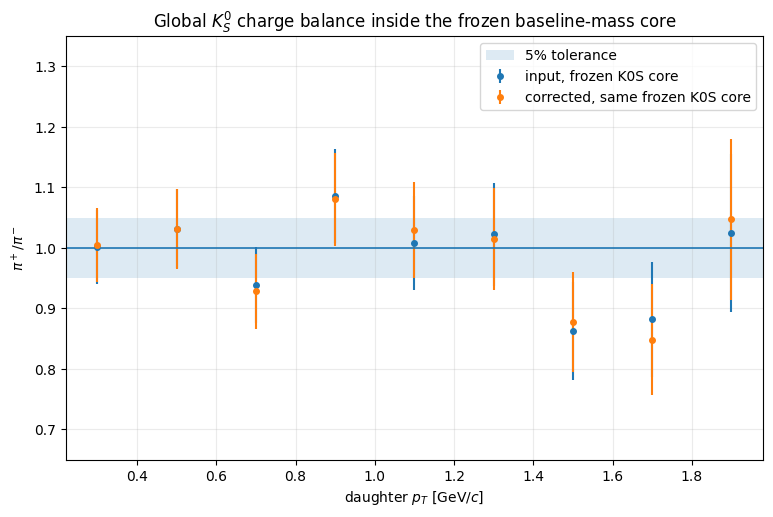

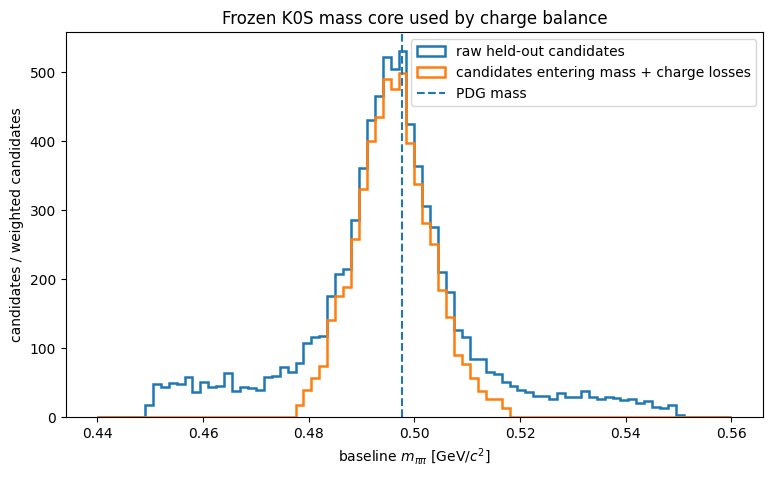

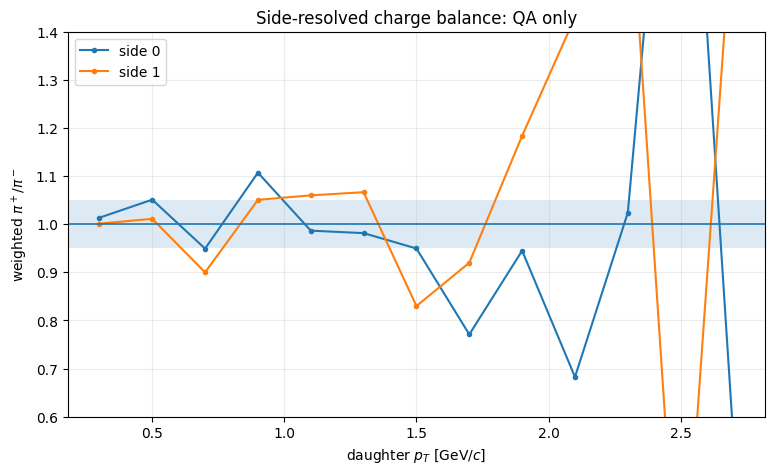

In [19]:
# ============================================================
# Held-out K0S charge balance + mass-gate QA
# ============================================================

arrays = load_npz_dictionary(kshort_npz_file)
validation_indices = np.flatnonzero(arrays['event_parity'].astype(np.int64) == validation_parity)
if maximum_validation_candidates is not None and len(validation_indices) > maximum_validation_candidates:
    rng = np.random.default_rng(seed + 4242)
    validation_indices = np.sort(rng.choice(validation_indices, size=maximum_validation_candidates, replace=False))

validation_loader = DataLoader(CandidateDataset(arrays, validation_indices), batch_size=min(validation_batch_size, len(validation_indices)), shuffle=False, num_workers=0)
k0s_validation = evaluate_joint_model(joint_ensemble_model, validation_loader, channel=0)
charge_before, charge_after = k0s_validation['charge_before'], k0s_validation['charge_after']
validation_arrays_np = k0s_validation['arrays']

charge_table = pd.DataFrame({
    'pt_center_gev': charge_after['centers'],
    'ratio_before': charge_before['ratio'],
    'ratio_after': charge_after['ratio'],
    'positive_neff_after': charge_after['positive_neff'],
    'negative_neff_after': charge_after['negative_neff'],
    'sigma_log_after': charge_after['sigma_log'],
    'active': charge_after['active'],
})
charge_table.to_csv(work_dir / 'global_charge_balance_validation.csv', index=False)
print('Global charge-balance score: before =', charge_before['score'], 'after =', charge_after['score'])

active_before, active_after = charge_before['active'], charge_after['active']
ratio_error_before = charge_before['ratio'] * charge_before['sigma_log']
ratio_error_after = charge_after['ratio'] * charge_after['sigma_log']
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(charge_before['centers'][active_before], charge_before['ratio'][active_before], yerr=ratio_error_before[active_before], fmt='o', ms=4, label='input, frozen K0S core')
ax.errorbar(charge_after['centers'][active_after], charge_after['ratio'][active_after], yerr=ratio_error_after[active_after], fmt='o', ms=4, label='corrected, same frozen K0S core')
ax.axhline(1.0, linewidth=1.2)
ax.axhspan(1.0 - charge_balance_systematic_floor_fraction, 1.0 + charge_balance_systematic_floor_fraction, alpha=0.15, label='5% tolerance')
ax.set(xlabel=r'daughter $p_T$ [GeV/$c$]', ylabel=r'$\pi^+/\pi^-$', title=r'Global $K^0_S$ charge balance inside the frozen baseline-mass core', ylim=(0.65, 1.35))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

# Put the exact charge-balance mass gate on top of the held-out mass distribution.
mass_before = validation_arrays_np['mass_before']
core_weight = validation_arrays_np['mass_core_weight']
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(mass_before, bins=80, range=(min_k0s_mass, max_k0s_mass), histtype='step', linewidth=1.8, label='raw held-out candidates')
ax.hist(mass_before, bins=80, range=(min_k0s_mass, max_k0s_mass), weights=core_weight, histtype='step', linewidth=1.8, label='candidates entering mass + charge losses')
ax.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.5, label='PDG mass')
ax.set(xlabel=r'baseline $m_{\pi\pi}$ [GeV/$c^2$]', ylabel='candidates / weighted candidates', title='Frozen K0S mass core used by charge balance')
ax.legend()
plt.show()

# Side-resolved charge balance remains QA only.
validation_weight = validation_arrays_np['pair_weight'] * validation_arrays_np['mass_core_weight']
side_charge_rows = []
for side in [0, 1]:
    positive_pt_parts, negative_pt_parts, positive_weight_parts, negative_weight_parts = [], [], [], []
    for daughter in [1, 2]:
        daughter_side = validation_arrays_np[f'side{daughter}']
        charge = validation_arrays_np[f'charge{daughter}']
        corrected_pt = validation_arrays_np[f'pt{daughter}_after']
        positive = (daughter_side == side) & (charge > 0)
        negative = (daughter_side == side) & (charge < 0)
        positive_pt_parts.append(corrected_pt[positive])
        negative_pt_parts.append(corrected_pt[negative])
        positive_weight_parts.append(validation_weight[positive])
        negative_weight_parts.append(validation_weight[negative])
    positive_pt_side = np.concatenate(positive_pt_parts)
    negative_pt_side = np.concatenate(negative_pt_parts)
    positive_weight_side = np.concatenate(positive_weight_parts)
    negative_weight_side = np.concatenate(negative_weight_parts)
    edges = np.linspace(charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    nplus, _ = np.histogram(positive_pt_side, bins=edges, weights=positive_weight_side)
    nminus, _ = np.histogram(negative_pt_side, bins=edges, weights=negative_weight_side)
    ratio = nplus / np.maximum(nminus, 1.0e-12)
    for center, value, plus, minus in zip(centers, ratio, nplus, nminus):
        side_charge_rows.append({'side': side, 'pt_center_gev': center, 'ratio_after': value, 'weighted_positive': plus, 'weighted_negative': minus})

side_charge_table = pd.DataFrame(side_charge_rows)
side_charge_table.to_csv(work_dir / 'charge_balance_by_side_diagnostic.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 5))
for side in [0, 1]:
    frame = side_charge_table.loc[side_charge_table['side'] == side]
    usable = (frame['weighted_positive'] > 0) & (frame['weighted_negative'] > 0)
    ax.plot(frame.loc[usable, 'pt_center_gev'], frame.loc[usable, 'ratio_after'], marker='o', ms=3, label=f'side {side}')
ax.axhline(1.0, linewidth=1.2)
ax.axhspan(0.95, 1.05, alpha=0.15)
ax.set(xlabel=r'daughter $p_T$ [GeV/$c$]', ylabel=r'weighted $\pi^+/\pi^-$', title='Side-resolved charge balance: QA only', ylim=(0.6, 1.4))
ax.grid(alpha=0.25)
ax.legend()
plt.show()


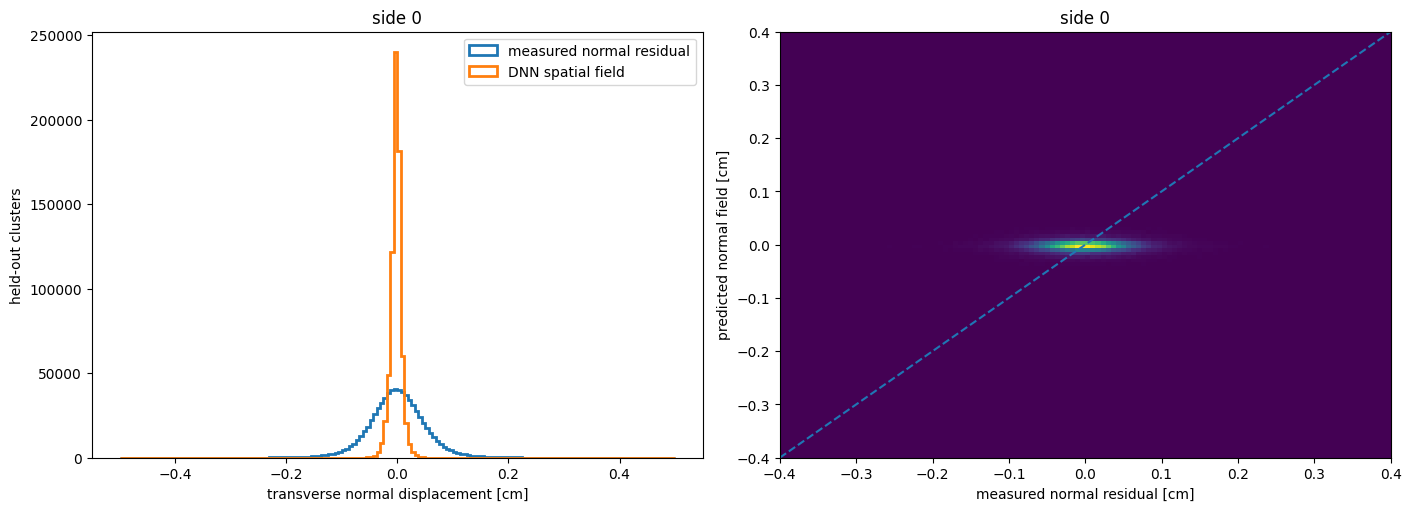

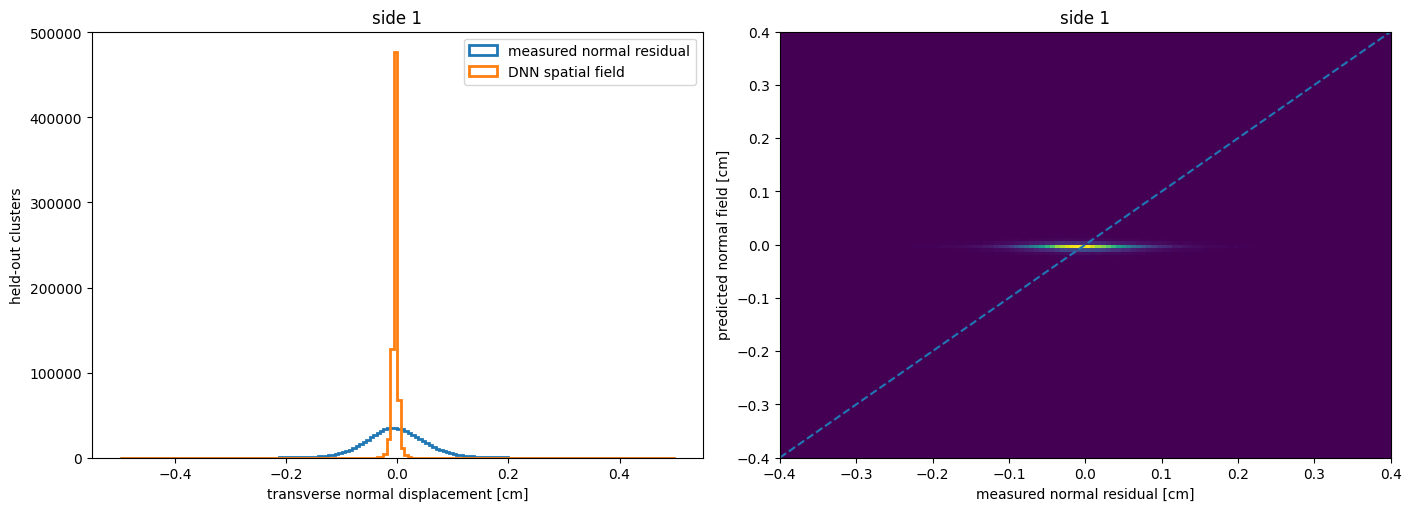

,side,clusters,target_mean,prediction_mean,rmse,correlation
0,0,722322,-0.000872,-0.002357,0.066453,0.009236
1,1,716153,-0.004595,-0.003925,0.070115,-0.007896


In [20]:
# ============================================================
# Held-out residual-prediction QA
# ============================================================

residual_qa_rows = []

arrays = load_npz_dictionary(kshort_npz_file)
validation_indices = np.flatnonzero(
    arrays['event_parity'].astype(np.int64) == validation_parity
)

for side in [0, 1]:
    flat = flatten_training_clusters_for_side(
        arrays,
        validation_indices,
        side,
    )

    model = ensemble_models[side]

    prediction_chunks = []
    chunk_size = 200000

    with torch.no_grad():
        for start in range(0, len(flat['r']), chunk_size):
            stop = min(start + chunk_size, len(flat['r']))

            r_tensor = torch.from_numpy(flat['r'][start:stop])
            phi_tensor = torch.from_numpy(flat['phi'][start:stop])
            z_tensor = torch.from_numpy(flat['z'][start:stop])

            delta_r, r_delta_phi, _ = model(
                r_tensor,
                phi_tensor,
                z_tensor,
            )

            predicted_normal = (
                delta_r.cpu().numpy()
                * flat['normal_projection_r'][start:stop]
                + r_delta_phi.cpu().numpy()
                * flat['normal_projection_rphi'][start:stop]
            )

            prediction_chunks.append(predicted_normal)

    predicted_normal = np.concatenate(prediction_chunks)
    target_normal = flat['res_normal']

    correlation = (
        float(np.corrcoef(predicted_normal, target_normal)[0, 1])
        if np.std(predicted_normal) > 0 and np.std(target_normal) > 0
        else np.nan
    )

    residual_qa_rows.append({
        'side': side,
        'clusters': len(target_normal),
        'target_mean': float(np.mean(target_normal)),
        'prediction_mean': float(np.mean(predicted_normal)),
        'rmse': float(np.sqrt(np.mean((predicted_normal - target_normal) ** 2))),
        'correlation': correlation,
    })

    figure, axes = plt.subplots(
        1, 2,
        figsize=(14, 5),
        constrained_layout=True,
    )

    axes[0].hist(
        target_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='measured normal residual',
    )

    axes[0].hist(
        predicted_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='DNN spatial field',
    )

    axes[0].set_xlabel('transverse normal displacement [cm]')
    axes[0].set_ylabel('held-out clusters')
    axes[0].set_title(f'side {side}')
    axes[0].legend()

    sample_size = min(100000, len(target_normal))
    sample = np.random.default_rng(seed + side).choice(
        len(target_normal),
        size=sample_size,
        replace=False,
    )

    axes[1].hist2d(
        target_normal[sample],
        predicted_normal[sample],
        bins=120,
        range=[[-0.4, 0.4], [-0.4, 0.4]],
    )

    axes[1].plot(
        [-0.4, 0.4],
        [-0.4, 0.4],
        linestyle='--',
    )
    axes[1].set_xlabel('measured normal residual [cm]')
    axes[1].set_ylabel('predicted normal field [cm]')
    axes[1].set_title(f'side {side}')

    plt.show()

residual_qa_summary = pd.DataFrame(residual_qa_rows)
residual_qa_summary.to_csv(
    work_dir / 'heldout_residual_qa.csv',
    index=False,
)

display(residual_qa_summary)


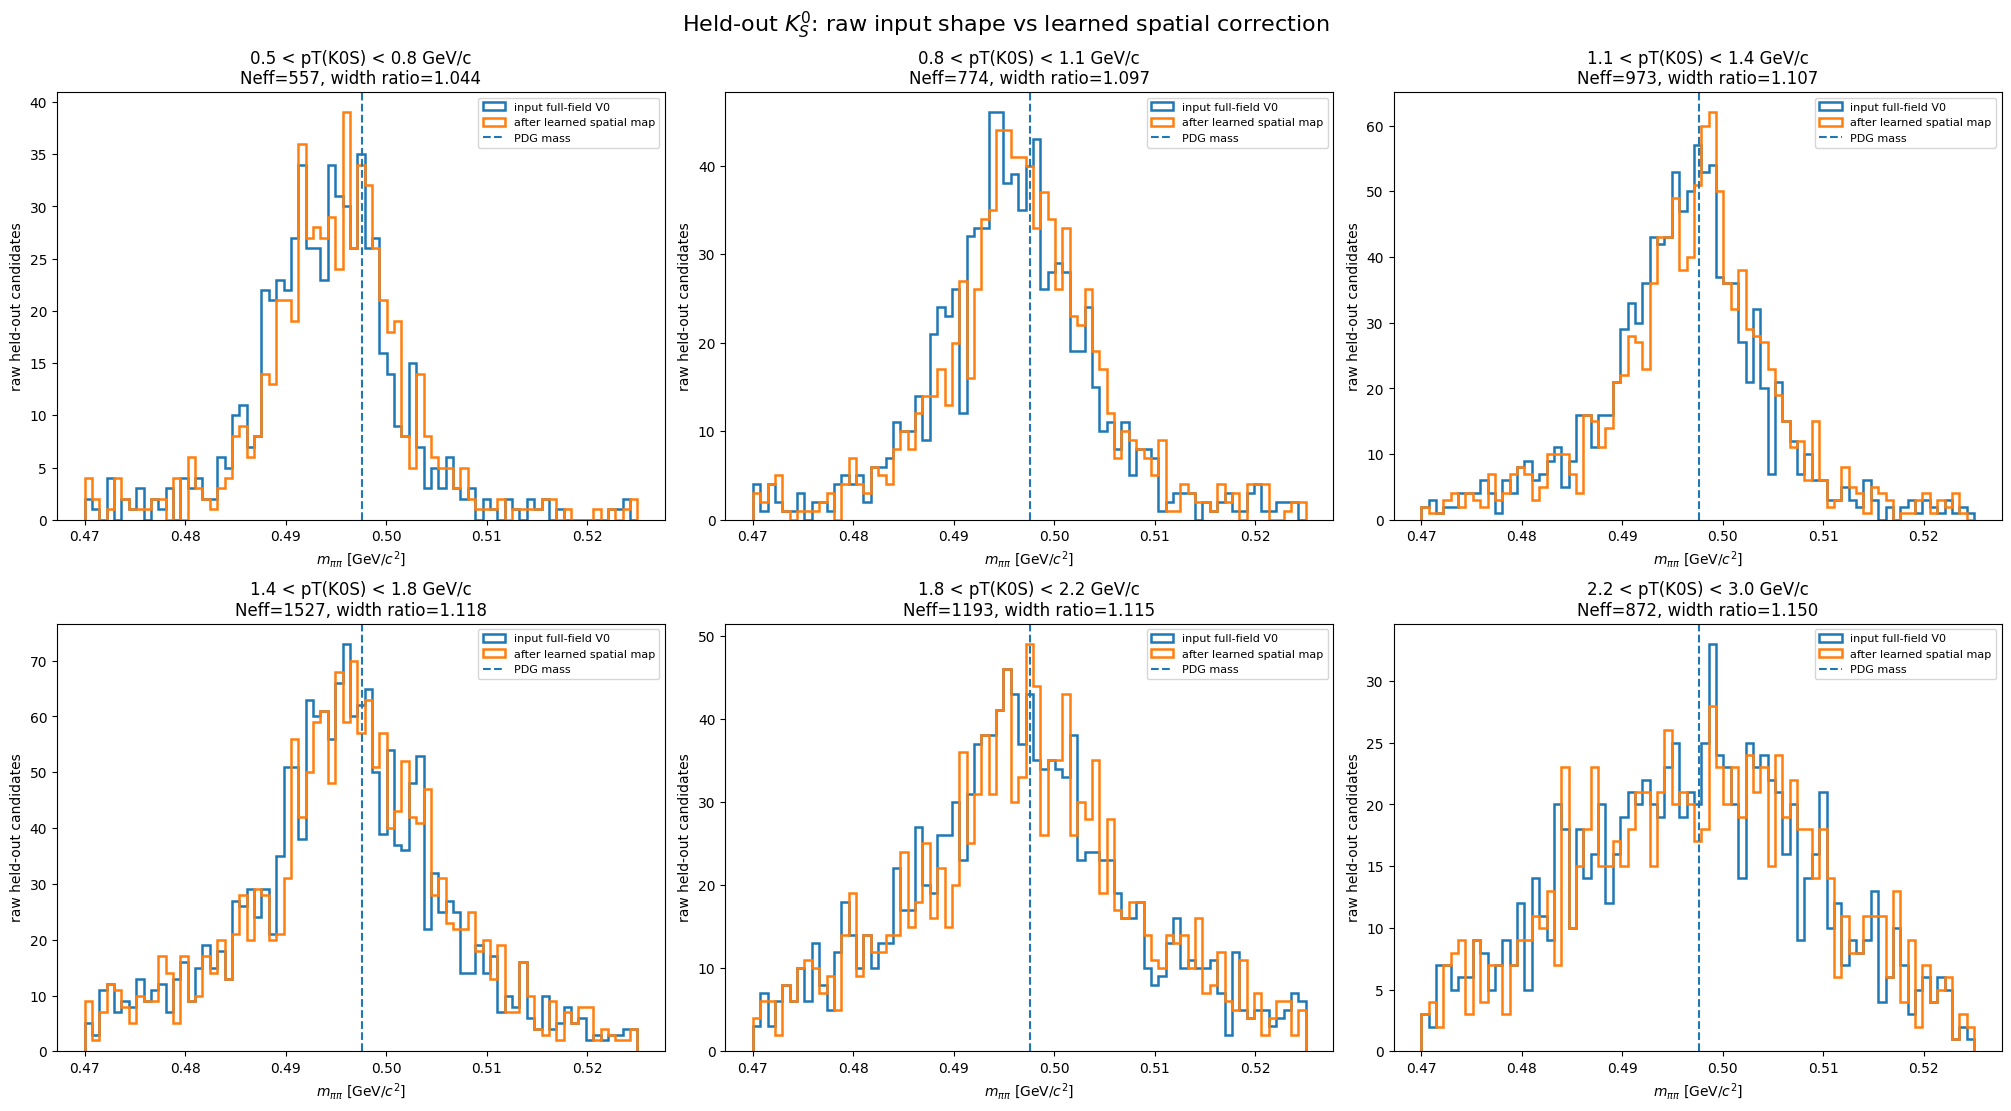

,pt_low,pt_high,entries,neff,mean_input,mean_after,mean_error_input_mev,mean_error_after_mev,width_input_mev,width_after_mev,width_ratio
0,0.5,0.8,705,557.322241,0.494138,0.495008,-3.472926,-2.603236,4.711598,4.917297,1.043658
1,0.8,1.1,975,773.651116,0.495521,0.496438,-2.090494,-1.172623,5.251755,5.760221,1.096818
2,1.1,1.4,1229,973.006686,0.496381,0.497416,-1.229799,-0.195236,5.408031,5.987220,1.107098
3,1.4,1.8,2001,1527.176021,0.496180,0.496883,-1.431328,-0.728269,6.862518,7.671099,1.117826
4,1.8,2.2,1596,1192.535205,0.496671,0.497518,-0.940312,-0.092551,8.592782,9.582899,1.115227
5,2.2,3.0,1190,872.453145,0.497855,0.498804,0.243766,1.192708,9.214609,10.595070,1.149812


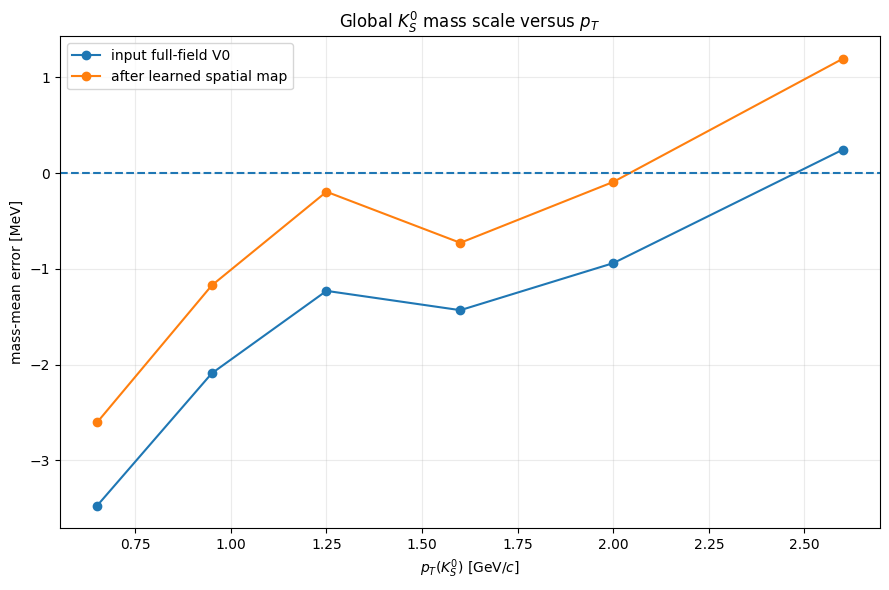

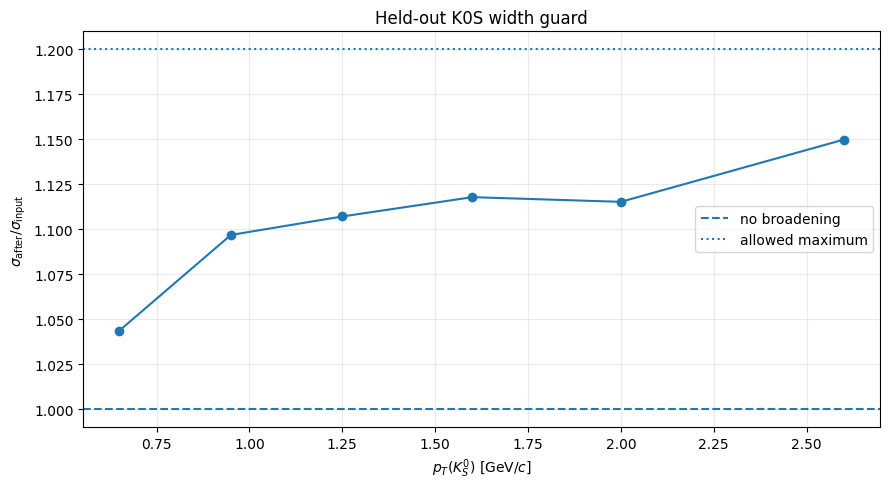

Held-out inclusive K0S width ratio: 1.1159171856948689


,daughter,side,tracks,mean_scale,rms_scale,q16,median,q84
0,1,0,4121,1.004117,0.018696,1.001258,1.003850,1.006537
1,1,1,3879,1.001702,0.009102,1.000393,1.001747,1.002824
2,2,0,3915,1.003657,0.017188,1.001570,1.004135,1.006739
3,2,1,4085,1.002070,0.011316,1.000539,1.001906,1.003085


In [21]:
# ============================================================
# Held-out K0S mass validation: raw shape must not broaden
# ============================================================

arrays = k0s_validation['arrays']
mass_weights = arrays['pair_weight'] * arrays['mass_core_weight']
kshort_validation_rows = []

figure, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
axes = axes.ravel()

for axis, lower, upper in zip(axes, pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selection = (arrays['pair_pt'] >= lower) & (arrays['pair_pt'] < upper)
    before = arrays['mass_before'][selection]
    after = arrays['mass_after'][selection]
    weights = mass_weights[selection]

    before_metrics = peak_metrics(before, weights)
    after_metrics = peak_metrics(after, weights)
    width_ratio = after_metrics['width'] / max(before_metrics['width'], 1.0e-12)

    kshort_validation_rows.append({
        'pt_low': float(lower),
        'pt_high': float(upper),
        'entries': int(np.count_nonzero(selection)),
        'neff': after_metrics['neff'],
        'mean_input': before_metrics['mean'],
        'mean_after': after_metrics['mean'],
        'mean_error_input_mev': 1000.0 * (before_metrics['mean'] - pdg_kshort_mass),
        'mean_error_after_mev': 1000.0 * (after_metrics['mean'] - pdg_kshort_mass),
        'width_input_mev': 1000.0 * before_metrics['width'],
        'width_after_mev': 1000.0 * after_metrics['width'],
        'width_ratio': width_ratio,
    })

    # Plot RAW candidates, not P(signal)-weighted ones, so any broadening is visible.
    axis.hist(before, bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='input full-field V0')
    axis.hist(after, bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='after learned spatial map')
    axis.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{lower:.1f} < pT(K0S) < {upper:.1f} GeV/c\nNeff={after_metrics["neff"]:.0f}, width ratio={width_ratio:.3f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('raw held-out candidates')
    axis.legend(fontsize=8)

figure.suptitle(r'Held-out $K^0_S$: raw input shape vs learned spatial correction', fontsize=16)
plt.show()

kshort_validation_frame = pd.DataFrame(kshort_validation_rows)
kshort_validation_frame.to_csv(work_dir / 'kshort_mass_scale_vs_pt.csv', index=False)
display(kshort_validation_frame)

pt_center = 0.5 * (kshort_validation_frame['pt_low'].to_numpy(float) + kshort_validation_frame['pt_high'].to_numpy(float))

plt.figure(figsize=(9, 6))
plt.plot(pt_center, kshort_validation_frame['mean_error_input_mev'], marker='o', label='input full-field V0')
plt.plot(pt_center, kshort_validation_frame['mean_error_after_mev'], marker='o', label='after learned spatial map')
plt.axhline(0.0, linestyle='--', linewidth=1.5)
plt.xlabel(r'$p_T(K^0_S)$ [GeV/$c$]')
plt.ylabel('mass-mean error [MeV]')
plt.title(r'Global $K^0_S$ mass scale versus $p_T$')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(work_dir / 'kshort_mass_scale_vs_pt.pdf')
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(pt_center, kshort_validation_frame['width_ratio'], marker='o')
plt.axhline(1.0, linestyle='--', linewidth=1.5, label='no broadening')
plt.axhline(maximum_validation_width_ratio, linestyle=':', linewidth=1.5, label='allowed maximum')
plt.xlabel(r'$p_T(K^0_S)$ [GeV/$c$]')
plt.ylabel(r'$\sigma_{\rm after}/\sigma_{\rm input}$')
plt.title('Held-out K0S width guard')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(work_dir / 'kshort_width_ratio_vs_pt.pdf')
plt.show()

# Inclusive hard guard. If this fails, stop before ROOT map export.
inclusive_before = peak_metrics(arrays['mass_before'], mass_weights)
inclusive_after = peak_metrics(arrays['mass_after'], mass_weights)
inclusive_width_ratio = inclusive_after['width'] / max(inclusive_before['width'], 1.0e-12)
print('Held-out inclusive K0S width ratio:', inclusive_width_ratio)

#if enforce_mass_width_validation and inclusive_width_ratio > maximum_validation_width_ratio:
#    raise RuntimeError(
#        f'Held-out K0S peak broadened by factor {inclusive_width_ratio:.4f}; '
#        f'maximum allowed is {maximum_validation_width_ratio:.4f}. '
#        'Map export intentionally blocked.'
#    )

# Momentum-scale response, separated by actual TPC side.
scale_rows = []
for daughter in [1, 2]:
    side_values = arrays[f'side{daughter}']
    scale_values = arrays[f'momentum_scale{daughter}']
    for side in [0, 1]:
        selected = side_values == side
        values = scale_values[selected]
        scale_rows.append({
            'daughter': daughter,
            'side': side,
            'tracks': int(np.count_nonzero(selected)),
            'mean_scale': float(np.mean(values)) if len(values) else np.nan,
            'rms_scale': float(np.std(values)) if len(values) else np.nan,
            'q16': float(np.quantile(values, 0.16)) if len(values) else np.nan,
            'median': float(np.quantile(values, 0.50)) if len(values) else np.nan,
            'q84': float(np.quantile(values, 0.84)) if len(values) else np.nan,
        })

scale_frame = pd.DataFrame(scale_rows)
scale_frame.to_csv(work_dir / 'momentum_scale_by_daughter_side.csv', index=False)
display(scale_frame)


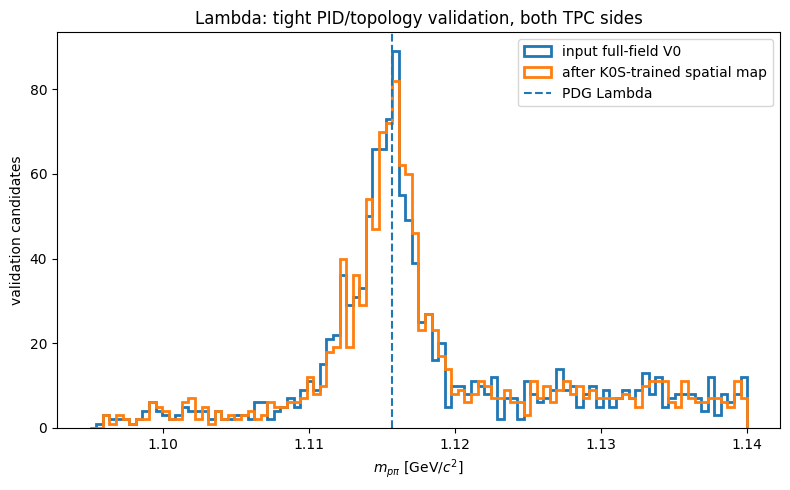

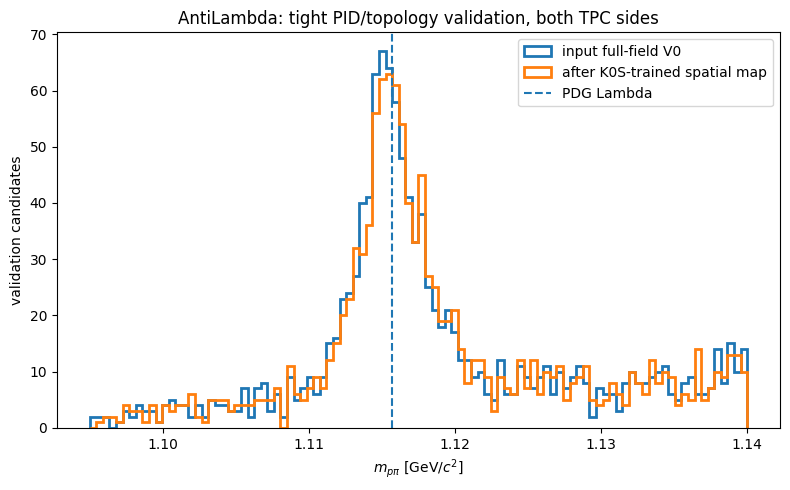

,channel,entries,mean_before,mean_after,width_before,width_after,mean_shift_mev
0,Lambda,1265,1.118273,1.118527,0.008780,0.008907,0.253888
1,AntiLambda,1219,1.118805,1.119046,0.009205,0.009279,0.241314


In [22]:
# ============================================================
# Lambda and anti-Lambda validation only
# ============================================================
#
# These channels are never used in the K0S training loss. They are a useful
# external check of whether the learned spatial map improves another V0 mass
# hypothesis without being explicitly trained to do so.

lambda_rows = []

for channel, label in [(1, 'Lambda'), (2, 'AntiLambda')]:
    if channel not in validation_npz_files:
        print(f'No cached {label} validation sample')
        continue

    arrays = load_npz_dictionary(
        validation_npz_files[channel]
    )

    indices = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == validation_parity
    )

    if len(indices) == 0:
        continue

    if (
        maximum_validation_candidates is not None
        and len(indices) > maximum_validation_candidates
    ):
        rng = np.random.default_rng(seed + 7000 + channel)
        indices = np.sort(
            rng.choice(
                indices,
                size=maximum_validation_candidates,
                replace=False,
            )
        )

    loader = DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=min(validation_batch_size, len(indices)),
        shuffle=False,
        num_workers=0,
    )

    metrics = evaluate_joint_model(
        joint_ensemble_model,
        loader,
        channel=channel,
    )

    before = metrics['arrays']['mass_before']
    after = metrics['arrays']['mass_after']

    lambda_rows.append({
        'channel': label,
        'entries': len(indices),
        'mean_before': metrics['before_peak']['mean'],
        'mean_after': metrics['after_peak']['mean'],
        'width_before': metrics['before_peak']['width'],
        'width_after': metrics['after_peak']['width'],
        'mean_shift_mev': 1000.0 * (
            metrics['after_peak']['mean']
            - metrics['before_peak']['mean']
        ),
    })

    plt.figure(figsize=(8, 5))

    plt.hist(
        before,
        bins=100,
        range=(1.095, 1.140),
        histtype='step',
        linewidth=2,
        label='input full-field V0',
    )

    plt.hist(
        after,
        bins=100,
        range=(1.095, 1.140),
        histtype='step',
        linewidth=2,
        label='after K0S-trained spatial map',
    )

    plt.axvline(
        1.115683,
        linestyle='--',
        label='PDG Lambda',
    )

    plt.xlabel(r'$m_{p\pi}$ [GeV/$c^2$]')
    plt.ylabel('validation candidates')
    plt.title(f'{label}: tight PID/topology validation, both TPC sides')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        work_dir / f'{label.lower()}_validation_global.pdf'
    )
    plt.show()

lambda_summary = pd.DataFrame(lambda_rows)
lambda_summary.to_csv(
    work_dir / 'lambda_validation.csv',
    index=False,
)

display(lambda_summary)


## Export the physical detector-space map

Each side histogram retains the full signed-\(z\) axis for compatibility, but the model returns zero outside that side's physical domain.

The exported map contains the sum of:

- the smooth drift-dependent DNN correction;
- the fitted side-level pad-plane offset and tilt-like field;
- the fitted local module displacement.

The QA panels include the pad-plane endpoint, where transverse corrections are now allowed to be nonzero while \(\Delta z\) remains zero.


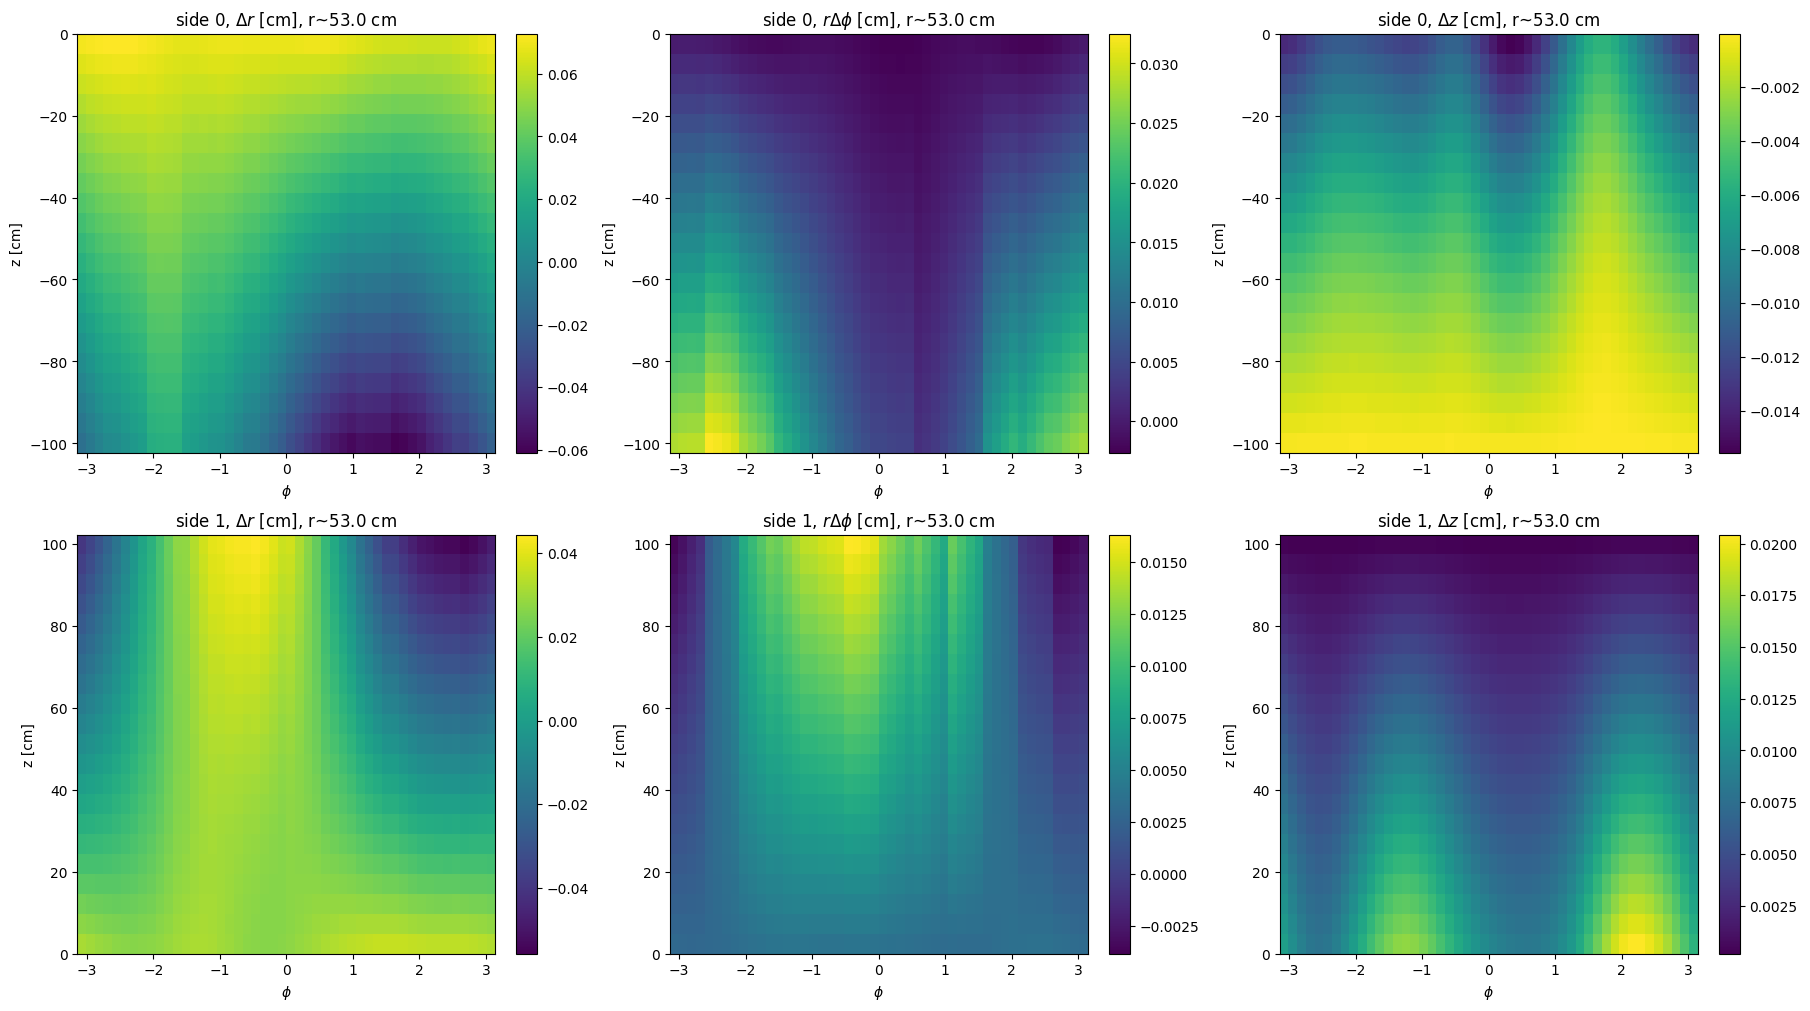

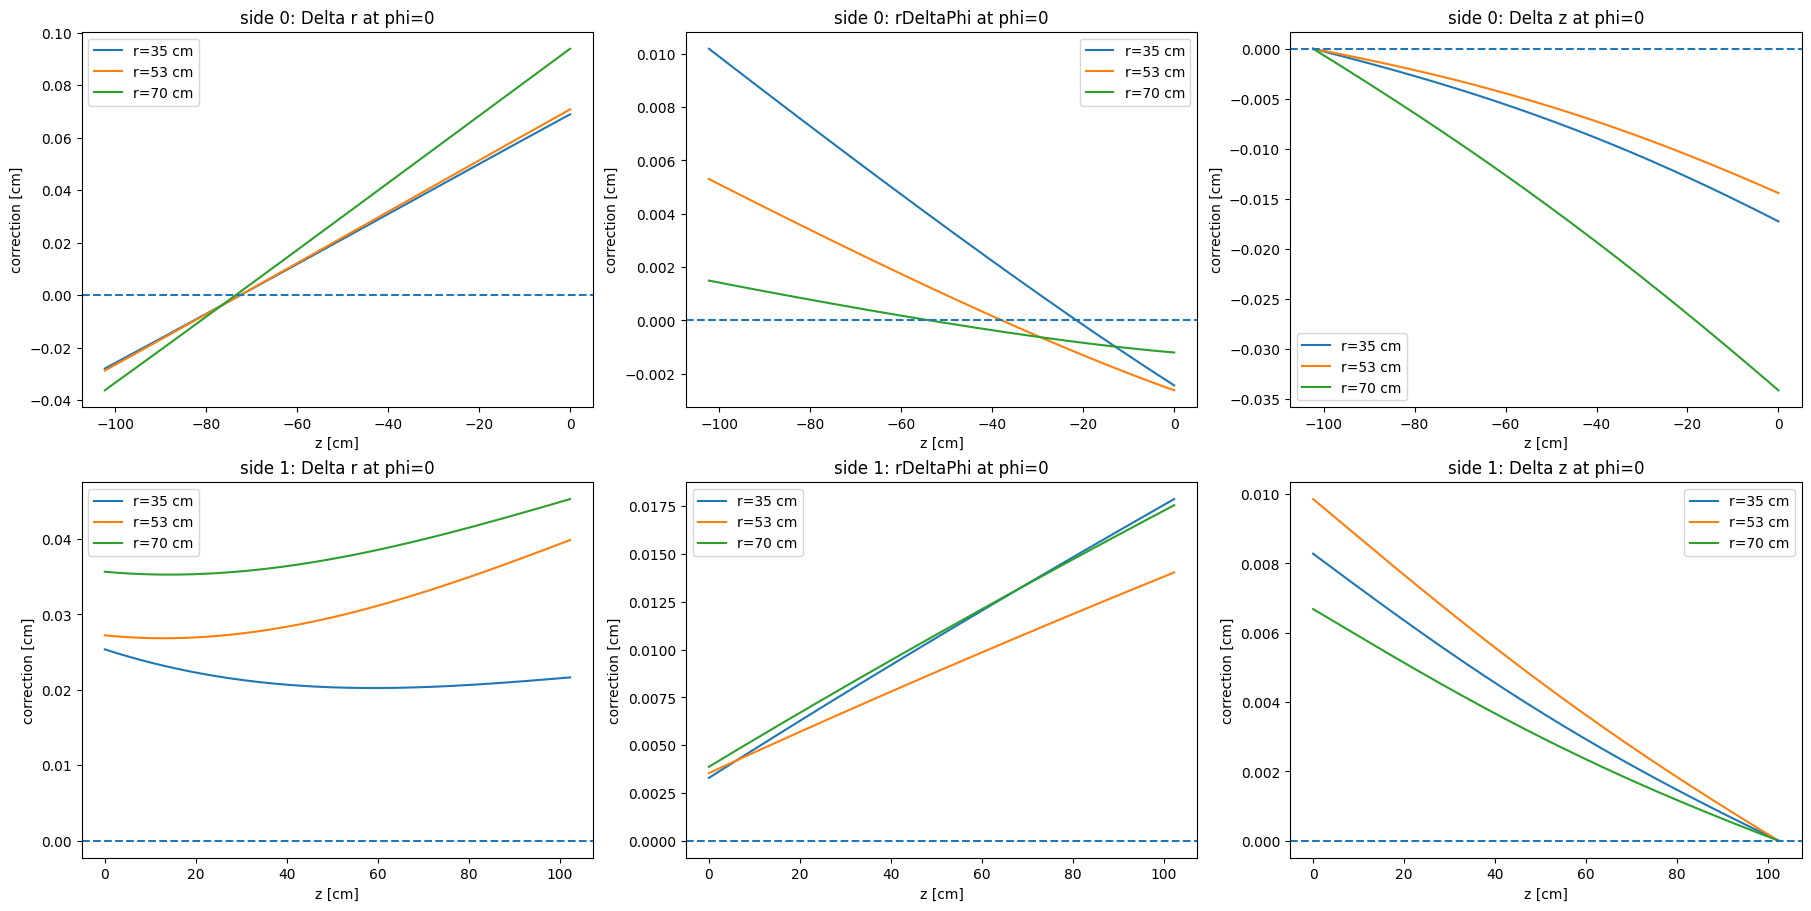

Wrote: output/v0_spatial_residual_dnn_v10_cut07_short_wide/v0_spatial_map_with_z_wide.root


In [23]:
# ============================================================
# Spatial-map QA and ROOT export
# ============================================================

r_edges = np.linspace(30.5, 76.5, 47)
phi_edges = np.linspace(-math.pi, math.pi, 49)
z_edges = np.linspace(-z_pad_cm, z_pad_cm, 43)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

map_rows = []

for side in [0, 1]:
    r_grid, phi_grid, z_grid = np.meshgrid(
        r_centers,
        phi_centers,
        z_centers,
        indexing='ij',
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            torch.from_numpy(r_grid.astype(np.float32)),
            torch.from_numpy(phi_grid.astype(np.float32)),
            torch.from_numpy(z_grid.astype(np.float32)),
        )

    for (
        radius_value,
        phi_value,
        z_value,
        delta_r_value,
        r_delta_phi_value,
        delta_z_value,
    ) in zip(
        r_grid.ravel(),
        phi_grid.ravel(),
        z_grid.ravel(),
        delta_r.numpy().ravel(),
        r_delta_phi.numpy().ravel(),
        delta_z.numpy().ravel(),
    ):
        map_rows.append({
            'side': side,
            'r': radius_value,
            'phi': phi_value,
            'z': z_value,
            'delta_r': delta_r_value,
            'rdelta_phi': r_delta_phi_value,
            'delta_z': delta_z_value,
        })

map_frame = pd.DataFrame(map_rows)
map_frame.to_csv(
    work_dir / 'v0_spatial_residual_map_grid.csv',
    index=False,
)

# Physical phi-z slices near r=53 cm.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    constrained_layout=True,
)

selected_radius = r_centers[
    np.argmin(np.abs(r_centers - 53.0))
]

for side in [0, 1]:
    if side == 0:
        physical_z_selection = map_frame['z'] <= 0.0
    else:
        physical_z_selection = map_frame['z'] >= 0.0

    subset = map_frame.loc[
        (map_frame['side'] == side)
        & np.isclose(map_frame['r'], selected_radius)
        & physical_z_selection
    ]

    for column_index, (column, title) in enumerate([
        ('delta_r', r'$\Delta r$ [cm]'),
        ('rdelta_phi', r'$r\Delta\phi$ [cm]'),
        ('delta_z', r'$\Delta z$ [cm]'),
    ]):
        values = subset.pivot(
            index='z',
            columns='phi',
            values=column,
        )

        image = axes[side, column_index].pcolormesh(
            values.columns,
            values.index,
            values.values,
            shading='auto',
        )

        axes[side, column_index].set_xlabel(r'$\phi$')
        axes[side, column_index].set_ylabel('z [cm]')
        axes[side, column_index].set_title(
            f'side {side}, {title}, r~{selected_radius:.1f} cm'
        )

        figure.colorbar(
            image,
            ax=axes[side, column_index],
        )

plt.show()

# Explicit z profiles showing the nonzero transverse pad-plane endpoint.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True,
)

profile_phi = 0.0
profile_radii = [35.0, 53.0, 70.0]

for side in [0, 1]:
    z_profile = (
        np.linspace(-z_pad_cm, 0.0, 240)
        if side == 0
        else np.linspace(0.0, z_pad_cm, 240)
    )

    for radius_value in profile_radii:
        with torch.no_grad():
            delta_r, r_delta_phi, delta_z = ensemble_models[side](
                torch.full((len(z_profile),), radius_value),
                torch.full((len(z_profile),), profile_phi),
                torch.from_numpy(z_profile.astype(np.float32)),
            )

        axes[side, 0].plot(
            z_profile,
            delta_r.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 1].plot(
            z_profile,
            r_delta_phi.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 2].plot(
            z_profile,
            delta_z.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

    axes[side, 0].set_title(f'side {side}: Delta r at phi=0')
    axes[side, 1].set_title(f'side {side}: rDeltaPhi at phi=0')
    axes[side, 2].set_title(f'side {side}: Delta z at phi=0')

    for axis in axes[side]:
        axis.axhline(0.0, linestyle='--')
        axis.set_xlabel('z [cm]')
        axis.set_ylabel('correction [cm]')
        axis.legend()

plt.show()

root_file = work_dir / (
    f'v0_spatial_map_with_z_{geometry_profile_name}.root'
    if include_z_correction
    else f'v0_spatial_map_transverse_only_{geometry_profile_name}.root'
)

if root is None:
    print('PyROOT unavailable; ROOT map not written')
else:
    output = root.TFile.Open(str(root_file), 'RECREATE')

    root.TNamed(
        'residual_convention',
        'map is measured-minus-fit field; apply corrected cluster = measured - map',
    ).Write()

    root.TNamed(
        'transverse_training_constraint',
        'normal projection: dn = delta_r*(n.er) + rdelta_phi*(n.ephi)',
    ).Write()

    root.TNamed(
        'pad_plane_boundary',
        (
            f'transverse side/module alignment may be nonzero at '
            f'abs(z)={z_pad_cm} cm; Delta z remains zero'
        ),
    ).Write()

    root.TNamed(
        'geometry_profile',
        geometry_profile_name,
    ).Write()

    root.TNamed(
        'geometry_limits_cm',
        json.dumps({
            'maximum_side_offset_cm': maximum_side_offset_cm,
            'maximum_side_tilt_displacement_cm': (
                maximum_side_tilt_displacement_cm
            ),
            'maximum_module_offset_cm': maximum_module_offset_cm,
            'minimum_tpc_modules_per_track': (
                minimum_tpc_modules_per_track
            ),
        }),
    ).Write()

    root.TNamed(
        'include_z_correction',
        str(int(include_z_correction)),
    ).Write()

    root.TNamed(
        'training_field_response',
        (
            'full-vector magnetic-field relative q/p response; '
            f'field mode={field_evaluation_mode}; '
            'zero spatial correction preserves the input full-field V0 momentum'
        ),
    ).Write()

    root.TNamed(
        'charge_balance_constraint',
        (
            'global K0S pi+/pi- daughter pT balance across both TPC sides; '
            f'systematic floor={charge_balance_systematic_floor_fraction:.3f}; '
            f'high-pT priority power={charge_balance_pt_priority_power:.3f}'
        ),
    ).Write()

    root.TNamed(
        'fixed_k0s_signal_model',
        json.dumps(fixed_mass_model),
    ).Write()

    for side in [0, 1]:
        directory = output.mkdir(f'side{side}')
        directory.cd()

        histograms = {
            'h3_delta_r': root.TH3D(
                'h3_delta_r',
                'Delta r;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_rdelta_phi': root.TH3D(
                'h3_rdelta_phi',
                'rDeltaPhi;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_delta_z': root.TH3D(
                'h3_delta_z',
                'Delta z;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
        }

        subset = map_frame.loc[
            map_frame['side'] == side
        ]

        for row in subset.itertuples(index=False):
            for name, column in [
                ('h3_delta_r', 'delta_r'),
                ('h3_rdelta_phi', 'rdelta_phi'),
                ('h3_delta_z', 'delta_z'),
            ]:
                histogram = histograms[name]
                histogram.SetBinContent(
                    histogram.FindBin(row.r, row.phi, row.z),
                    getattr(row, column),
                )

        for histogram in histograms.values():
            histogram.Write()

    output.Close()
    print('Wrote:', root_file)


## Applying the map in production

The exported ROOT object is still a **detector-space residual correction map**, not a momentum-scale lookup table:

\[
\vec x_{\rm corrected}
=
\vec x_{\rm measured}
-
\Delta\vec x_{\rm learned}.
\]

After applying the map to TPC clusters, run the ordinary C++ V0 track fit with the real sPHENIX magnetic-field map.  The fast full-vector \(q/p\) estimator in this notebook exists only to make the physics loss differentiable and fast enough for training; it is **not** intended to replace the production Kalman/RKN propagation.

This separation is useful: the final object remains a spatial calibration, while the K0S mass and charge-balance information constrain that calibration through a field-aware track response.


## Recommended workflow

1. Point `csv_dir` / `csv_prefix` at the **existing** exporter output; v10 does not require a new export.
2. Start with `training_profile='short'` and run through the frozen K0S mass-model cell.
3. Confirm the cut07 and PID counts, the smooth-pruning plot, and that the frozen mass core is narrow and sideband probability is small.
4. Let the short profile finish. Reject the map if held-out K0S broadens or charge balance improves only by damaging the mass peak.
5. Only then switch to `training_profile='long'` for the final training.

The stochastic pruning is deliberate: low-pT candidates are thinned smoothly, while candidates above `prune_full_keep_pt_gev` are kept. `pair_weight=1`, so the network is not asked to undo the pruning with large inverse-density weights.
